# Bloch Neural ODE / Numerical Methods Pipeline

This notebook combines the project code, into a single executable pipeline: Bloch simulator, dataset creation, Neural ODE Model Definitions, training loops, numerical methods, inference utilities, and a final evaluation section. Code is included largely verbatim from the original files with comments preserved.

Usage notes:
- Run cells in order. Not all cells need to be ran (for example, some of them are training loops and will take days to finish). In general, if that cell has a function, it's probably a good idea to run it.
- You may need to install dependencies: `torch`, `numpy`, `matplotlib`, `tqdm`, and optionally `torchdiffeq` for the adaptive ODE model. Some visualization functions depend on ffmpeg.

In [27]:
# Setup Code
import sys, os
# no code here will do anything bad to your computer like remove sys32. It jsut needs to make file paths consistent (like for saved models) so it can find them properly.
from pathlib import Path
ROOT = Path('.').resolve()  # notebook placed at repo root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

Project root: D:\MAT292_ODE_Project\Bloch-Equations-Modelling-Project


## Bloch Simulator Code
Since no public datasets exist to model the net magnetization of nuclei according to Bloch's equations. As such,  we used an online Bloch simulator at https://www.drcmr.dk/BlochSimulator/ to generate datasets to our needs. While these datasets do not reflect the perfect dynamics of the Bloch equations, we believe they are a suitable compromise for the lack of data and performance on these generated datasets is reflective of a model's performance on real world data. The code below is an adaptation of the open source code used on this website to Python.

In [28]:
# Bloch equation simulator for MRI applications, adapted
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Optional, Callable
import json


@dataclass # class that just holds data
class Isochromat: # spin packet: group of spins that are @ same loc and experience same B field.
    """Represents a single isochromat (spin packet) with position and magnetization"""
    M: np.ndarray  # Magnetization vector [Mx, My, Mz] (current magnetization vector of packet)
    pos: np.ndarray  # Position [x, y, z] (spatial position of packet, used in gradient sim.)
    dB0: float = 0.0  # Field offset (field inhomogeneity. irl, B0 isn't uniform & dB0 is small constant 
                      # offset. primary cause of signal decay.)
    T1: float = np.inf  # Longitudinal relaxation time (how quickly component along main field M_z recovers to o.g. M_0
                        # small T_1 => fast recovery)
    T2: float = np.inf  # Transverse relaxation time (how quickly M_x and M_y decay to 0 b/c of random microscopic spin
                        # interactions.)
    M0: float = 1.0  # Equilibrium magnetization (fully relaxed magnetization vector in +z axis. )

# The actual simulator class. Contains functions for initializing the simulation and selecting the paramters of the simulation.
class BlochSimulator:
    
    def __init__(self, gamma: float = 1.0, B0: float = 2.0):
        """
            gamma: Gyromagnetic ratio (default normalized to 1) (omega = gamma * B)
            B0: Main magnetic field strength
        """
        self.gamma = gamma 
        self.B0 = B0 # strength of main static B field
        self.isochromats: List[Isochromat] = [] # list of all spin packets
        self.time = 0.0 # current time ig
        self.history = [] # snapshot of system state at every time step
        
        # Field parameters
        self.B1 = 0.0  # RF field amplitude
        self.B1_freq = 0.0  # RF frequency
        self.phi1 = 0.0  # RF phase
        self.Gx = 0.0  # X gradient
        self.Gy = 0.0  # Y gradient
        
        # Pulse parameters
        self.RF_active = False
        self.RF_time_left = 0.0
        self.RF_area_left = 0.0
        self.RF_func: Optional[Callable] = None
        
    def add_isochromat(self, M: np.ndarray, pos: np.ndarray = np.array([0, 0, 0]),
                       dB0: float = 0.0, T1: float = np.inf, T2: float = np.inf):
        # Add an isochromat to the simulation
        iso = Isochromat(M=M.copy(), pos=pos.copy(), dB0=dB0, T1=T1, T2=T2)
        self.isochromats.append(iso)
        
    def setup_single_spin(self):
        # Setup a single perfect spin at origin w/o relaxation equilibrium 
        self.isochromats.clear()
        self.add_isochromat(np.array([0, 0, 1]))
        
    def setup_inhomogeneous(self, n_spins: int = 9, spread: float = 0.3):
        # Setup multiple spins with field inhomogeneity. Multiple spins @ same location but diff. dBO values. Simulate T2 decay
        # where diff spins precess @ diff speeds and fan out in xy plane (causing signal decay).
        self.isochromats.clear()
        for i in range(n_spins):
            dB0 = (i - (n_spins-1)/2) / (n_spins/6) * spread
            self.add_isochromat(np.array([0, 0, 1]), dB0=dB0)
            
    def setup_spatial_line(self, n_spins: int = 21, spacing: float = 0.4):
        # Setup spins along a line (x-axis) for gradient testing. Show if G_x (x gradient) works.
        self.isochromats.clear()
        for i in range(n_spins):
            x_pos = (i - (n_spins-1)/2) * spacing
            self.add_isochromat(
                np.array([0, 0, 1]), 
                pos=np.array([x_pos, 0, 0])
            )
            
    def setup_relaxation(self, T1: float = 5.0, T2: float = 3.0):
        # Setup a single spin with relaxation (finite T1, T2 values). 
        self.isochromats.clear()
        self.add_isochromat(np.array([0, 0, 1]), T1=T1, T2=T2)
        
    def RF_pulse_rect(self, angle: float, phase: float, B1_amplitude: float = 4.0):
        """
        Apply rectangular RF pulse

            angle: Flip angle in radians
            phase: RF phase in radians
            B1_amplitude: RF field strength
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase
        duration = angle / (self.gamma * B1_amplitude)
        
        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = self._RF_const # which function step method shoudl call to get B1 field value @ some time.
        
    def RF_pulse_sinc(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                      n_lobes: int = 4):
        # a sinc-shaped RF pulse
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase
        
        # Sinc pulse is longer to maintain same area
        sinc_correction = 0.22570583339507  # Si(2π)/(2π) for 4-lobe sinc
        duration = angle / (self.gamma * B1_amplitude * sinc_correction)
        
        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_sinc(t, duration, n_lobes)

    # RF_const and RF_sinc actually calculate B1 vector at time t.  
    def _RF_const(self, t: float) -> Tuple[np.ndarray, float]:
        # Constant (rectangular) RF pulse shape
        phase = self.B1_freq * t - self.phi1
        B1_vec = np.array([
            self.B1 * np.cos(phase),
            -self.B1 * np.sin(phase),
            0.0
        ])
        return B1_vec, self.B1
    
    def _RF_sinc(self, t: float, duration: float, n_lobes: int) -> Tuple[np.ndarray, float]:
        # Sinc RF pulse shape
        phase = self.B1_freq * t - self.phi1
        sinc_arg = n_lobes * np.pi * (t/duration - 0.5)
        
        if abs(sinc_arg) > 0.01:
            envelope = self.B1 * np.sin(sinc_arg) / sinc_arg
        else:
            envelope = self.B1
            
        B1_vec = np.array([
            envelope * np.cos(phase),
            -envelope * np.sin(phase),
            0.0
        ])
        return B1_vec, envelope
    
    import numpy as np

    # ----------------------- Helpers (inside the class) -----------------------

    def _duration_from_envelope_avg(self, angle, B1_peak, env_of_tau, n=4096):
        """
        Numerically compute the duration that yields the requested flip angle.

        We assume an envelope defined on tau in [0,1] with peak 1.0:
            B1(t) = B1_peak * env_of_tau(t / duration)
        => area = ∫ B1 dt = B1_peak * duration * ∫_0^1 env(τ) dτ
        Flip angle: angle = gamma * area

        So: duration = angle / (gamma * B1_peak * avg_env),
            where avg_env = ∫_0^1 env(τ) dτ
        """
        tau = np.linspace(0.0, 1.0, n, endpoint=False) + 0.5 / n
        env_vals = env_of_tau(tau)
        avg_env = np.trapz(env_vals, tau)  # integral over [0,1]
        avg_env = float(max(avg_env, 1e-12))  # guard
        return angle / (self.gamma * B1_peak * avg_env)

    # -------------------- 1) Gaussian pulse (RF_pulse_gaussian) --------------------

    def RF_pulse_gaussian(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                        sigma_frac: float = 0.20):
        """
        Apply a Gaussian-envelope RF pulse with flip-angle normalization.

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: peak B1 (envelope peak = 1.0 -> peak field = B1_amplitude)
        sigma_frac: controls width of the Gaussian relative to duration
                    (σ in units of half-duration; 0.2 is a common smooth choice)
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        # envelope on τ ∈ [0,1], centered at 0.5
        def env_of_tau(tau):
            # convert sigma_frac (fraction of half-duration) to σ on τ-domain
            # half-duration in τ is 0.5, so σ_τ = sigma_frac / 0.5
            sigma_tau = sigma_frac / 0.5
            return np.exp(-0.5 * ((tau - 0.5) / sigma_tau) ** 2)

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_gaussian(t, duration, sigma_frac)

    def _RF_gaussian(self, t: float, duration: float, sigma_frac: float):
        """Return (B1_vec, envelope) for Gaussian envelope at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        sigma_tau = sigma_frac / 0.5
        env = float(np.exp(-0.5 * ((tau - 0.5) / sigma_tau) ** 2))

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env

    # --------------- 2) Hamming-windowed sinc (RF_pulse_windowed_sinc) ---------------

    def RF_pulse_windowed_sinc(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                            n_lobes: int = 4):
        """
        Apply a Hamming-windowed sinc RF pulse (cleaner spectrum than plain sinc).

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: peak B1 (after windowing; peak env is normalized to 1)
        n_lobes: number of lobes on each side of the center
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        # Continuous-time Hamming window on τ ∈ [0,1]
        def window_hamming(tau):
            return 0.54 - 0.46 * np.cos(2 * np.pi * tau)

        def env_of_tau(tau):
            # Map τ∈[0,1] to x∈[-n_lobes, n_lobes]
            x = (tau - 0.5) * 2.0 * n_lobes
            sinc = np.sinc(x)  # np.sinc uses sin(πx)/(πx); OK up to scale
            env = sinc * window_hamming(tau)
            # normalize to peak 1.0 so B1_amplitude is actual peak
            peak = np.max(np.abs(env))
            return env / (peak + 1e-12)

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_windowed_sinc(t, duration, n_lobes)

    def _RF_windowed_sinc(self, t: float, duration: float, n_lobes: int):
        """Return (B1_vec, envelope) for Hamming-windowed sinc at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        x = (tau - 0.5) * 2.0 * n_lobes
        sinc = np.sinc(x)
        window = 0.54 - 0.46 * np.cos(2 * np.pi * tau)
        env = sinc * window
        env /= (np.max([abs(env), 1e-12]))  # tiny guard if called at boundaries

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env

    # ------------------ 3) Trapezoidal (ramps) (RF_pulse_trapezoid) ------------------

    def RF_pulse_trapezoid(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                        ramp_frac: float = 0.10):
        """
        Apply a trapezoidal RF pulse with linear rise/fall ramps.

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: plateau peak
        ramp_frac: fraction of the duration used for each ramp (0–0.5)
        """
        ramp_frac = float(np.clip(ramp_frac, 0.0, 0.49))
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        def env_of_tau(tau):
            # piecewise linear: rise -> flat -> fall on τ∈[0,1]
            r = ramp_frac
            env = np.empty_like(tau)
            # rise
            rise = tau < r
            env[rise] = tau[rise] / max(r, 1e-12)
            # flat
            flat = (tau >= r) & (tau <= 1.0 - r)
            env[flat] = 1.0
            # fall
            fall = tau > 1.0 - r
            env[fall] = (1.0 - tau[fall]) / max(r, 1e-12)
            return env

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_trapezoid(t, duration, ramp_frac)

    def _RF_trapezoid(self, t: float, duration: float, ramp_frac: float):
        """Return (B1_vec, envelope) for a trapezoid at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        r = ramp_frac
        if tau < r:
            env = tau / max(r, 1e-12)
        elif tau <= 1.0 - r:
            env = 1.0
        else:
            env = (1.0 - tau) / max(r, 1e-12)

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env



    def random_fourier_pulse(T: int, dt: float, A: float, n_terms: int = 5):
        """
        Generate a random composite pulse as a sum of sinusoids.

        Parameters
        ----------
        T : int
            Number of samples.
        dt : float
            Time step (seconds).
        A : float
            Overall amplitude scaling.
        n_terms : int
            Number of random harmonic components to sum.

        Returns
        -------
        np.ndarray
            Random, smooth RF envelope normalized to amplitude A.
        """
        t = np.arange(T) * dt
        y = np.zeros_like(t)
        for _ in range(n_terms):
            f = np.random.uniform(100, 5000)  # random frequency in Hz
            phi = np.random.uniform(0, 2 * np.pi)
            y += np.sin(2 * np.pi * f * t + phi)
        y /= np.max(np.abs(y)) + 1e-8
        return (A * y).astype(np.float32)



    def apply_gradient(self, phase_diff: float, direction_angle: float = 0.0):
        """Apply gradient pulse"""
        grad_scale = 11  # From o.g. code
        duration = 1.0  # seconds
        area = phase_diff * grad_scale / self.gamma
        
        self.Gx = np.cos(direction_angle) * area / duration
        self.Gy = np.sin(direction_angle) * area / duration
        
    def step(self, dt: float):
        """
        Evolve the system by one time step using Bloch equations

            dt: Time step in seconds
        """
        self.time += dt
        
        # Get RF field
        if self.RF_active and self.RF_time_left > 0: # check if RF is on and time remaining
            B1_vec, envelope = self.RF_func(self.time) # get B1 vector
            dArea = dt * self.gamma * envelope
            
            if self.RF_time_left < dt:
                # End of pulse (adjust to match target angle)
                B1_vec *= self.RF_area_left / dArea
                self.RF_active = False
                self.RF_time_left = 0
                self.B1 = 0
            else:
                self.RF_area_left -= dArea
                self.RF_time_left -= dt
        else: # no B1 vec if no RF
            B1_vec = np.array([0, 0, 0])
            self.RF_active = False
            
        # Update each isochromat
        for iso in self.isochromats:
            # Total field including gradients and offsets. total B field each iso feels at this instant.
            grad_scale = 11  # From o.g. code
            detuning = iso.dB0 + (self.Gx * iso.pos[0] + self.Gy * iso.pos[1]) / grad_scale
            # z field detuning is sum of spin's personal offset and gradient fields.  multiplications mean "if G_x grad on, 
            # field depends on x_position)"
            B_total = B1_vec + np.array([0, 0, self.B0 + detuning])
            
            # Precession (M x B term) (Rotation due to B field)
            B_mag = np.linalg.norm(B_total)
            if B_mag > 1e-10:
                rotation_angle = -B_mag * dt * self.gamma
                rotation_axis = B_total / B_mag
                
                # Rodrigues' rotation formula
                K = np.array([
                    [0, -rotation_axis[2], rotation_axis[1]],
                    [rotation_axis[2], 0, -rotation_axis[0]],
                    [-rotation_axis[1], rotation_axis[0], 0]
                ])
                R = np.eye(3) + np.sin(rotation_angle) * K + \
                    (1 - np.cos(rotation_angle)) * K @ K
                iso.M = R @ iso.M # isochromat's magnetizatoin vector updated by matrix-multiplying it by rotation
                # matrix R to precess vector.
            
            # Relaxation (T1, T2 terms)
            if np.isfinite(iso.T1) or np.isfinite(iso.T2):
                f1 = np.exp(-dt / iso.T1) if np.isfinite(iso.T1) else 1.0 # exponential decay factor for M_z in time dt
                f2 = np.exp(-dt / iso.T2) if np.isfinite(iso.T2) else 1.0 # exponential decay factor for M_x and M_y in time dt.
                
                iso.M[0] *= f2 # Mx decays toward 0
                iso.M[1] *= f2 # My decays toward 0
                iso.M[2] = iso.M[2] * f1 + (1 - f1) * iso.M0 # analytic solution for T1 relaxation. M_z decays toward 0 w/
                # f1 and (at teh same time) grows back towards M0 (equil)
        
        # Store history
        self._record_state() # append state of all isochromats to self.history
        
    def _record_state(self):
        """Record current state for history"""
        state = {
            'time': self.time,
            'magnetization': np.array([iso.M.copy() for iso in self.isochromats]),
            'B1': self.B1,
            'RF_active': self.RF_active
        }
        self.history.append(state)
        
    def get_total_magnetization(self) -> np.ndarray:
        # Get total magnetization vector
        return np.sum([iso.M for iso in self.isochromats], axis=0)
    
    def get_transverse_magnetization(self) -> float:
        # Get magnitude of transverse magnetization
        M_total = self.get_total_magnetization()
        return np.sqrt(M_total[0]**2 + M_total[1]**2)
    
    def simulate_sequence(self, duration: float, dt: float = 0.01):
        """
        Run simulation for specified duration

            duration: Total simulation time
            dt: Time step
        """
        steps = int(duration / dt)
        for _ in range(steps):
            self.step(dt)
            
    def reset(self):
        # Reset simulation
        self.time = 0.0
        self.history.clear()
        for iso in self.isochromats:
            iso.M = np.array([0, 0, iso.M0])


In [29]:
class BlochVisualizer:
    # Visualization for Bloch simulation
    
    @staticmethod
    def plot_magnetization_trajectory(simulator: BlochSimulator, figsize=(12, 4)):
        # Plot Mx, My, Mz over time. Calculates total magnetizaiotn by summing M vectors of all isochromats
        # at each time step.
        if not simulator.history:
            print("No simulation data to plot")
            return
            
        times = [state['time'] for state in simulator.history]
        M_total = np.array([
            np.sum(state['magnetization'], axis=0) / len(simulator.isochromats)
            for state in simulator.history
        ])
        
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        axes[0].plot(times, M_total[:, 0], 'r-', linewidth=2)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Mx')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_title('X Magnetization')
        
        axes[1].plot(times, M_total[:, 1], 'g-', linewidth=2)
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('My')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_title('Y Magnetization')
        
        axes[2].plot(times, M_total[:, 2], 'b-', linewidth=2)
        axes[2].set_xlabel('Time (s)')
        axes[2].set_ylabel('Mz')
        axes[2].grid(True, alpha=0.3)
        axes[2].set_title('Z Magnetization')
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_bloch_sphere(simulator: BlochSimulator, frame_idx: int = -1):
        # Plot magnetization vectors on Bloch sphere. Default picks last time step. Draw M vector for each isochromat.
        # use for dephasing visual. (run setup_inhomo and vectors start aligned and then fan out across xy plane)
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Draw sphere
        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x = np.outer(np.cos(u), np.sin(v))
        y = np.outer(np.sin(u), np.sin(v))
        z = np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_surface(x, y, z, alpha=0.1, color='lightblue')
        
        # Draw axes
        ax.plot([0, 1.3], [0, 0], [0, 0], 'k-', linewidth=2, alpha=0.3)
        ax.plot([0, 0], [0, 1.3], [0, 0], 'k-', linewidth=2, alpha=0.3)
        ax.plot([0, 0], [0, 0], [0, 1.3], 'k-', linewidth=2, alpha=0.3)
        ax.text(1.4, 0, 0, 'X', fontsize=14)
        ax.text(0, 1.4, 0, 'Y', fontsize=14)
        ax.text(0, 0, 1.4, 'Z', fontsize=14)
        
        # Plot magnetization vectors
        if simulator.history:
            state = simulator.history[frame_idx]
            for M in state['magnetization']:
                ax.quiver(0, 0, 0, M[0], M[1], M[2],
                         arrow_length_ratio=0.1, linewidth=2, color='red')
        
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.set_zlim([-1.2, 1.2])
        ax.set_xlabel('Mx')
        ax.set_ylabel('My')
        ax.set_zlabel('Mz')
        ax.set_title(f'Bloch Sphere at t={simulator.history[frame_idx]["time"]:.2f}s')
        
        return fig
    
    @staticmethod
    def plot_fid_spectrum(simulator: BlochSimulator):
        # Plot FID signal and its spectrum. simulates what MRI/NMR scanner actually measures.
        if not simulator.history:
            print("No simulation data to plot")
            return
            
        times = np.array([state['time'] for state in simulator.history])
        M_total = np.array([
            np.sum(state['magnetization'], axis=0)
            for state in simulator.history
        ])
        
        # Complex transverse magnetization (FID)
        signal = M_total[:, 0] + 1j * M_total[:, 1] # scanner's reciever coil picks up oscillating transverse xy magnetization
        # represnted as complex number. time domain signal called free induction decay.
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Time domain (real, im, and mag of signal that decays)
        axes[0].plot(times, signal.real, 'b-', label='Real', linewidth=2)
        axes[0].plot(times, signal.imag, 'r-', label='Imaginary', linewidth=2)
        axes[0].plot(times, np.abs(signal), 'k--', label='Magnitude', linewidth=2)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Signal')
        axes[0].set_title('FID Signal')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Frequency domain (spectrum)
        dt = times[1] - times[0] if len(times) > 1 else 0.01
        spectrum = np.fft.fftshift(np.fft.fft(signal)) # calculates FFT of FID. time to frequency domain.
        freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), dt)) # 0 freq at center
        
        axes[1].plot(freqs, np.abs(spectrum), 'b-', linewidth=2)
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('Magnitude')
        axes[1].set_title('Spectrum')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlim([freqs[0], freqs[-1]])
        
        plt.tight_layout()
        return fig

## BlochSim Tester

Quick visual / functional tests for the `BlochSimulator` — adapted from `tests/blochsim_tester.py`. Run these to sanity-check the simulator before dataset generation or training.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- shared helper ----------
def plot_trajectory3d(sim, title=""):
    M = np.array([np.sum(s["magnetization"], axis=0) for s in sim.history])  # (T,3)
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)

    # sphere surface (reference)
    u = np.linspace(0, 2*np.pi, 72)
    v = np.linspace(0, np.pi, 36)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, alpha=0.12, edgecolor="none")

    ax.plot(M[:, 0], M[:, 1], M[:, 2], linewidth=2)
    ax.scatter(M[0, 0], M[0, 1], M[0, 2], s=60, c="g", label="start")
    ax.scatter(M[-1, 0], M[-1, 1], M[-1, 2], s=60, c="r", label="end")
    ax.legend()
    ax.set_xlabel("Mx"); ax.set_ylabel("My"); ax.set_zlabel("Mz")
    lim = 1.2
    ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
    ax.view_init(elev=25, azim=35)
    return fig

# ---------- each case returns a configured-and-run simulator ----------
def case_free_precession():
    """Single spin; precession around +z with no relaxation."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_single_spin()
    sim.isochromats[0].M = np.array([1.0, 0.0, 0.0])  # start in xy-plane
    sim.simulate_sequence(duration=5.0, dt=0.001)
    return sim, "Free precession (B0 only)"

def case_90_then_free():
    """90° hard pulse tips M to xy; observe post-pulse precession."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_single_spin()
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=4.0)
    sim.simulate_sequence(duration=3.0, dt=0.0005)
    return sim, "90° pulse → free precession"

def case_relaxation_only():
    """No B0; watch pure T1 recovery and T2 decay toward equilibrium."""
    sim = BlochSimulator(gamma=1.0, B0=0.0)
    sim.isochromats.clear()
    sim.add_isochromat(M=np.array([1.0, 0.0, 0.0]), T1=7.0, T2=1.0)
    sim.simulate_sequence(duration=8.0, dt=0.005)
    return sim, "Relaxation only (T1/T2)"

def case_relaxation_plus_precession():
    """B0 ≠ 0; spiral back to +z while precessing."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.isochromats.clear()
    sim.add_isochromat(M=np.array([1.0, 0.0, 0.0]), T1=9.0, T2=2.0)
    sim.simulate_sequence(duration=10.0, dt=0.005)
    return sim, "Relaxation + precession"

def case_inhomogeneous_dephasing(n=15, spread=0.5):
    """Multiple spins with different dB0; transverse dephasing (T2*)."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_inhomogeneous(n_spins=n, spread=spread)
    # tip all into xy to see dephasing clearly
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=5.0)
    sim.simulate_sequence(duration=2.0, dt=0.0005)
    return sim, "Inhomogeneous dephasing (T2*)"

def case_gradient_dephase_rephase():
    """
    Simple 'gradient echo' style: turn on Gx briefly to dephase, then flip sign to rephase.
    NOTE: your apply_gradient sets a steady gradient; we emulate finite pulses by setting Gx,
    simulating, then zeroing / negating it.
    """
    sim = BlochSimulator(gamma=1.0, B0=0.0)
    sim.setup_spatial_line(n_spins=41, spacing=0.15)
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # small delay

    # "Dephase" with +Gx for τ
    sim.Gx = 8.0; sim.Gy = 0.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)

    # "Rephase" with -Gx for τ
    sim.Gx = -8.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)

    # gradients off
    sim.Gx = 0.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)
    return sim, "Gradient echo: dephase → rephase"

def case_spin_echo():
    """Classic Hahn spin echo: 90° — τ — 180° — τ; refocus inhomogeneous dephasing."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_inhomogeneous(n_spins=21, spread=0.5)

    # 90° to transverse
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # τ

    # 180° inversion about x̂ (phase=0)
    sim.RF_pulse_rect(angle=np.pi, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # τ

    # observe echo
    sim.simulate_sequence(duration=0.05, dt=0.0005)
    return sim, "Hahn spin echo (90-τ-180-τ)"

def case_sinc_pulse_clean():
    """
    Sinc-shaped RF pulse on a single spin: shows clean 90° flip with visible precession spiral.
    Uses MRI-like B0 with scaled gamma for visualization.
    Extended observation to see many rotations with visible but slow decay.
    """
    # MRI-like parameters
    B0 = 3.0                           # Tesla (typical clinical MRI field)
    gamma_base = 2.0 * np.pi * 42.577  # rad/s per T (proton gyromagnetic ratio)
    scale_factor = 100.0               # scale gamma for visualization (100× for very clear rotations)
    gamma_scaled = gamma_base * scale_factor
    
    # Setup single spin with tissue-like relaxation
    # Key: use LONG T2 so the spiral stays visible through the entire observation window
    sim = BlochSimulator(gamma=gamma_scaled, B0=B0)
    sim.setup_single_spin()
    sim.isochromats[0].T1 = 2.0   # 2000 ms (long relaxation)
    sim.isochromats[0].T2 = 1.5   # 1500 ms (long transverse relaxation — lets spiral be seen for full duration)
    
    # Apply sinc 90° pulse
    sim.RF_pulse_sinc(angle=np.pi/2, phase=0.0, B1_amplitude=5.0, n_lobes=4)
    
    # Simulate RF pulse and then long observation
    dt = 0.0001  # 0.1 ms timestep
    sim.simulate_sequence(duration=0.01, dt=dt)   # RF pulse (10 ms)
    sim.simulate_sequence(duration=2.0, dt=dt)    # Long free precession (2 s) — full spiral visible
    
    # Diagnostics
    f_hz = (gamma_scaled * B0) / (2.0 * np.pi)
    rotations = f_hz * 2.0  # over the 2s observation window
    print(f"Sinc pulse (clean): B0={B0}T, gamma_scale={scale_factor}× → Larmor ≈ {f_hz:.1f} Hz")
    print(f"Expected rotations in 2.0s: ≈ {rotations:.1f}")
    print(f"T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s — spiral should stay visible for full observation")
    
    return sim, f"Sinc RF (single-spin, extended spiral) — B0={B0}T, T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s"


In [31]:
def case_mri_like():
    """
    MRI-like parameters for visualization (scaled gamma):
    - B0 = 3.0 T (typical clinical field)
    - gamma scaled to 2π * 42.577 Hz/T and multiplied by a factor for clearer
      visualization of precession (no physical intent)
    - T1 and T2 set to realistic tissue-like values (seconds)

    Notes:
    - For true physical proton Larmor (42.577 MHz/T) you'd need dt in the
      nanosecond range; here we intentionally scale gamma down for practical
      visualization while keeping B0 at MRI-like value. We further multiply
      gamma by a small factor so you can see many rotations without tiny dt.
    """
    gamma_base = 2.0 * np.pi * 42.577  # rad/s per T (visualization-friendly base)
    scale_factor = 10.0                 # increase to get more rotation visible
    gamma_scaled = gamma_base * scale_factor
    B0 = 3.0  # Tesla (typical clinical MRI)

    sim = BlochSimulator(gamma=gamma_scaled, B0=B0)
    sim.setup_single_spin()

    # Tissue-like relaxation times (seconds)
    sim.isochromats[0].T1 = 1.2   # ~1200 ms
    sim.isochromats[0].T2 = 0.08  # ~80 ms

    # Apply a sinc 90° pulse
    sim.RF_pulse_sinc(angle=np.pi/2, phase=0.0, B1_amplitude=5.0, n_lobes=4)

    # Simulate the RF pulse (short) and then free precession
    rf_dt = 0.0001
    rf_dur = 0.01
    obs_dt = 0.0001
    obs_dur = 2.0

    sim.simulate_sequence(duration=rf_dur, dt=rf_dt)   # RF pulse / tipping
    sim.simulate_sequence(duration=obs_dur, dt=obs_dt) # observe dynamics

    # Diagnostics: estimated Larmor frequency and rotations
    f_hz = (gamma_scaled * B0) / (2.0 * np.pi)
    rotations = f_hz * obs_dur
    print(f"Larmor freq ≈ {f_hz:.1f} Hz; expected rotations in {obs_dur}s ≈ {rotations:.1f}")

    return sim, f"MRI-like (B0={B0}T, gamma_scale={scale_factor}) — T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s"

In [32]:
# the various possible simulations for the simulator to run
CASES = {
    "free_precession": case_free_precession,
    "rf_90_then_free": case_90_then_free,
    "relaxation_only": case_relaxation_only,
    "relaxation_plus_precession": case_relaxation_plus_precession,
    "inhomogeneous_dephasing": case_inhomogeneous_dephasing,
    "gradient_echo": case_gradient_dephase_rephase,
    "spin_echo": case_spin_echo,
    "sinc_pulse_clean": case_sinc_pulse_clean,  # Single-spin sinc: clean 3D trajectory with many rotations
    "mri_like": case_mri_like,
}

# chooses which simulation to run
def run_case(name: str):
    if name not in CASES:
        raise ValueError(f"Unknown case '{name}'. Options: {list(CASES)}")
    sim, title = CASES[name]()
    # 2D traces
    fig2d = BlochVisualizer.plot_magnetization_trajectory(sim)
    fig2d.suptitle(title)
    plt.show()

    # Snapshot on Bloch sphere
    BlochVisualizer.plot_bloch_sphere(sim, frame_idx=-1)
    plt.title(f"{title} — final snapshot")
    plt.show()

    # 3D path of total M
    plot_trajectory3d(sim, f"{title} — 3D trajectory")
    plt.show()
    return sim


Sinc pulse (clean): B0=3.0T, gamma_scale=100.0× → Larmor ≈ 12773.1 Hz
Expected rotations in 2.0s: ≈ 25546.2
T1=2.0s, T2=1.5s — spiral should stay visible for full observation


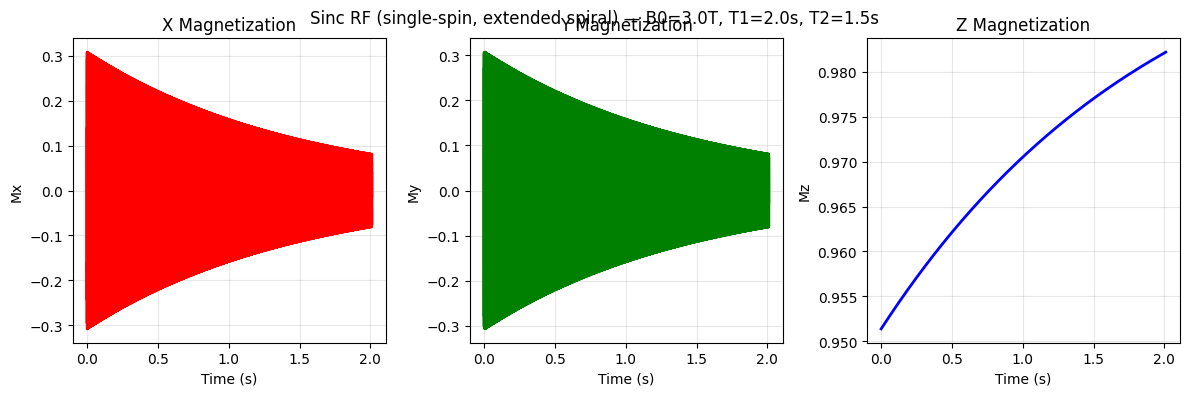

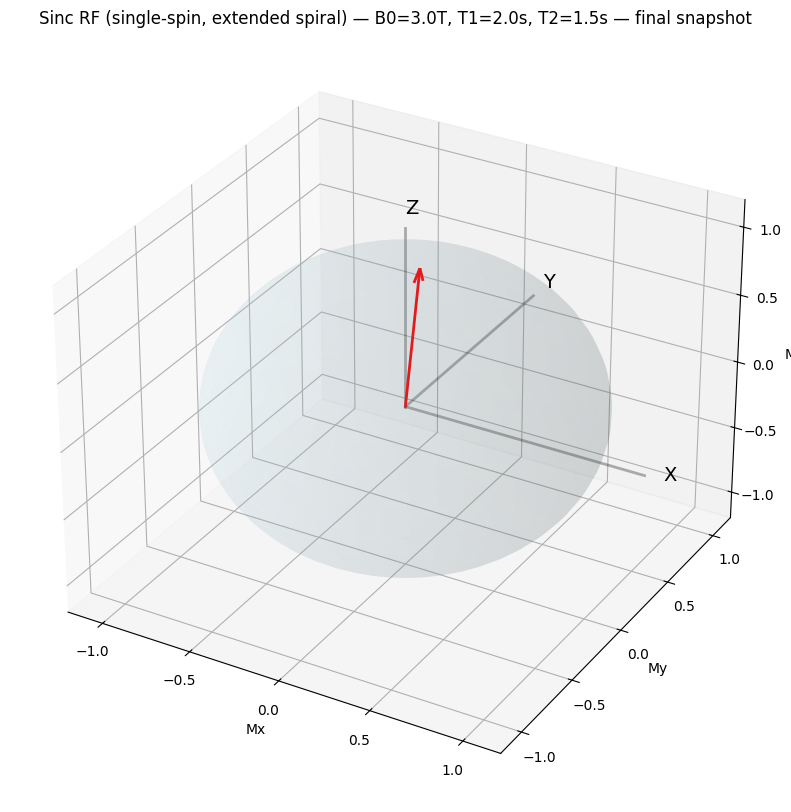

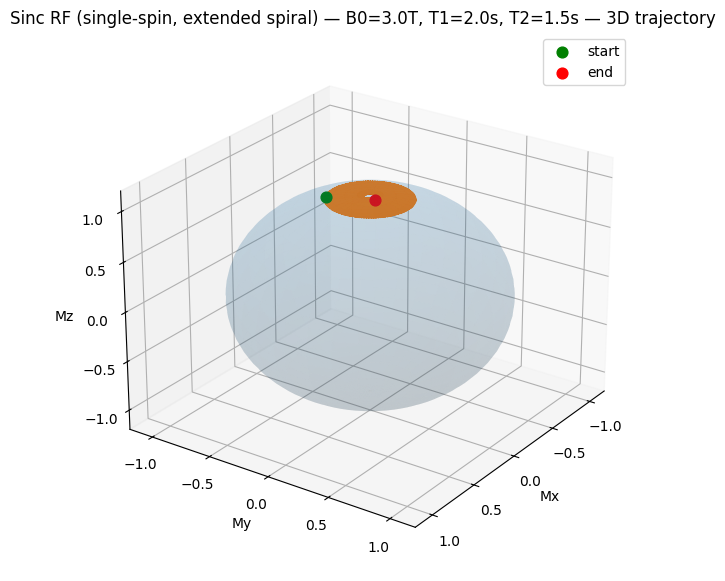

In [33]:
# Run the improved sinc_pulse_clean case to see many rotations with visible spiral decay
run_case("sinc_pulse_clean")

# You can also try other cases:
# run_case("mri_like")
# run_case("spin_echo")


## Dataset Generator

Uses blochsim generator to create datasets with train/val/test splits for training. Generates 3 datasets. A small test dataset to see if the model overfits, an easy dataset with single spins, and a more complicated dataset with multi-spin voxels that more accurately simulate an MRI.

In [34]:
from __future__ import annotations
import json, math
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
from tqdm import tqdm 

from blochsim import BlochSimulator  # make sure this is importable (it's a custom module; the .toml file is in the repository)


# ------------------------------ Utilities ------------------------------ #

def set_seed(seed: int) -> np.random.Generator:
    """Create a NumPy RNG with a fixed seed."""
    return np.random.default_rng(int(seed))


def ensure_outdir(path: str | Path) -> Path:
    """
    Ensure an output directory exists; create it if missing.
    Prints the absolute resolved path for debugging.
    """
    p = Path(path).expanduser()
    if not p.is_absolute():
        p = Path.cwd() / p
    try:
        p.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        raise RuntimeError(f"Failed to create output directory: {p}\n{e}") from e
    print(f"[make_datasets] Using output directory: {p.resolve()}")
    return p


# -------------------------- Parameter Sampling ------------------------- #

def draw_params(rng: np.random.Generator) -> Dict[str, float]:
    # T1 ~ 0.3–3.0 s → covers CSF-ish up to WM/GM/muscle range
    T1 = float(rng.uniform(0.3, 1.0))

    # T2 ~ 20–200 ms, but constrained to T2 < 0.5*T1 for realism
    T2_min = max(0.02 * T1, 0.02)      # ≥ 20 ms if T1 is large
    T2_max = min(0.5  * T1, 0.20)      # ≤ 200 ms typical at clinical B0
    T2 = float(rng.uniform(T2_min, T2_max))

    B0 = float(rng.uniform(1.5, 3.0))  # 1.5–3T scanners

    # broader inhomogeneity / off-resonance → richer dephasing
    dB0_std = 0.03 * B0     # ~3% std
    dB0 = float(rng.normal(0.0, dB0_std))
    dB0 = float(np.clip(dB0, -0.1 * B0, 0.1 * B0))  # clamp to ±10%

    gamma = 1.0  # scaled units; your BlochSimulator already interprets this

    return dict(T1=T1, T2=T2, dB0=dB0, B0=B0, gamma=gamma)



# --------------------------- Control Programming ------------------------ #

def program_controls_and_run(
    sim: BlochSimulator,
    T: int,
    dt: float,
    rng: np.random.Generator,
    rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    p_easy: float = 0.5,  # 50% easy, 50% harder cases
) -> tuple[np.ndarray, str]:
    """
    Generate control sequence u[t] = [B1x, B1y, Gx, Gy] and run the simulation.
    Most cases are 'easy' (simpler RF + no gradients), some are 'hard' (more exotic RF + gradients).
    """
    u = np.zeros((T, 4), dtype=np.float32)

    # Decide difficulty of this sample
    is_easy = rng.random() < p_easy

    phase = rng.uniform(0.0, 2.0 * math.pi)

    if is_easy:
        # Easier: small–moderate flip, simple shapes, no gradients
        flip_deg = rng.uniform(5.0, 45.0)  # 5–45°
        flip  = math.radians(flip_deg)
        B1amp = rng.uniform(1.0, 3.0)
        rf_type = rng.choice(("rect", "trapezoid"))

        sim.Gx = 0.0
        sim.Gy = 0.0
    else:
        # Harder: mix of medium and large flip angles + richer RF types
        regime = rng.choice(("medium", "large"))
        if regime == "medium":
            flip_deg = rng.uniform(30.0, 90.0)   # 30–90°
        else:
            flip_deg = rng.uniform(90.0, 180.0)  # 90–180°
        flip = math.radians(flip_deg)

        # Allow a slightly wider B1 amplitude range
        B1amp = rng.uniform(2.0, 6.0)
        rf_type = rng.choice(rf_families)

        # Add some gradient dephasing / readout
        # random direction and strength, typical of diffusion / dephasing gradients
        phi   = rng.uniform(0.0, math.pi)
        theta = rng.uniform(0.0, 2.0 * math.pi)
        sim.apply_gradient(phase_diff=phi, direction_angle=theta)

        # Optionally add a constant readout gradient along x/y after RF
        if rng.random() < 0.5:
            sim.Gx = rng.uniform(-0.02, 0.02)
            sim.Gy = 0.0
        else:
            sim.Gx = 0.0
            sim.Gy = rng.uniform(-0.02, 0.02)


    dispatch = {
        "rect":          lambda: sim.RF_pulse_rect(angle=flip, phase=phase, B1_amplitude=B1amp),
        "sinc":          lambda: sim.RF_pulse_sinc(angle=flip, phase=phase, B1_amplitude=B1amp, n_lobes=4),
        "gaussian":      lambda: sim.RF_pulse_gaussian(angle=flip, phase=phase, B1_amplitude=B1amp, sigma_frac=0.20),
        "windowed_sinc": lambda: sim.RF_pulse_windowed_sinc(angle=flip, phase=phase, B1_amplitude=B1amp, n_lobes=4),
        "trapezoid":     lambda: sim.RF_pulse_trapezoid(angle=flip, phase=phase, B1_amplitude=B1amp, ramp_frac=0.10),
    }
    if rf_type not in dispatch:
        raise ValueError(f"Unknown rf_type '{rf_type}'. Supported: {list(dispatch.keys())}")
    dispatch[rf_type]()

    # Run simulation while recording controls
    for t_idx in range(T):
        B1x = sim.B1 * math.cos(sim.B1_freq * sim.time - sim.phi1)
        B1y = -sim.B1 * math.sin(sim.B1_freq * sim.time - sim.phi1)
        u[t_idx, 0] = B1x
        u[t_idx, 1] = B1y
        u[t_idx, 2] = sim.Gx
        u[t_idx, 3] = sim.Gy
        sim.step(dt)

    sim.Gx = 0.0
    sim.Gy = 0.0
    return u, rf_type


# --------------------------- Single Rollout ----------------------------- #

def simulate_one(
        T: int,
        dt: float,
        rng: np.random.Generator,
        per_sample_t: bool = False,
        rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    ) -> Dict[str, np.ndarray]:
    """
    Simulate a single Bloch trajectory and return:
      t:  (T,)
      y:  (T, 3)   magnetization over time (normalized)
      y0: (3,)
      u:  (T, 4)   controls [B1x, B1y, Gx, Gy]
      p:  (5,)     [T1, T2, dB0, B0, gamma]
    """
    p = draw_params(rng)
    sim = BlochSimulator(gamma=p["gamma"], B0=p["B0"])

    # Single spin or a small inhomogeneous ensemble
    if rng.random() < 0.5:
        sim.setup_single_spin()
        sim.isochromats[0].dB0 = p["dB0"]
        sim.isochromats[0].T1  = p["T1"]
        sim.isochromats[0].T2  = p["T2"]
    else:
        n = rng.integers(7, 17)
        spread = rng.uniform(0.1, 0.6)
        sim.setup_inhomogeneous(n_spins=int(n), spread=float(spread))
        for iso in sim.isochromats:
            iso.T1 = p["T1"]
            iso.T2 = p["T2"]

    sim.reset()

    # time axis
    t = np.arange(T, dtype=np.float32) * float(dt)

    # run the sequence + controls
    u, rf_type = program_controls_and_run(
        sim, T=T, dt=dt, rng=rng, rf_families=rf_families
    )

    # safety check: history length should equal T
    if len(sim.history) != T:
        raise RuntimeError(
            f"BlochSimulator.history has length {len(sim.history)} but T={T}. "
            "Did something stop the simulation early?"
        )

    # Average magnetization over isochromats (MRI-like net magnetization)
    try:
        y = np.array(
            [np.mean(state["magnetization"], axis=0) for state in sim.history],
            dtype=np.float32,
        )
    except Exception as e:
        raise RuntimeError(f"Failed to build y from sim.history: {e}") from e

    if y.shape != (T, 3):
        raise RuntimeError(f"Unexpected y shape {y.shape}, expected {(T,3)}")

    y0 = y[0].astype(np.float32)

    # Normalize so that ||M(0)|| = 1 (Bloch-sphere-friendly)
    m0_norm = float(np.linalg.norm(y0))
    if m0_norm > 0:
        y  = y  / m0_norm
        y0 = y0 / m0_norm

    p_vec = np.array([p["T1"], p["T2"], p["dB0"], p["B0"], p["gamma"]], dtype=np.float32)

    return dict(t=t, y=y, y0=y0, u=u, p=p_vec, rf_type=str(rf_type))



# --------------------------- Split Writers ------------------------------ #

def write_split(
    outdir: str | Path,
    n_train: int,
    n_val: int,
    n_test: int,
    T: int,
    dt: float,
    seed: int = 2025,
    per_sample_t: bool = False,
    rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
) -> None:
    """
    Generate train/val/test splits and write compressed NPZ files.
    Adds 'rf_type' (N,) string array to each split.
    """

    outdir = ensure_outdir(outdir)
    rng = set_seed(seed)
    t_shared = np.arange(T, dtype=np.float32) * float(dt)

    def make_n(n: int, split_name: str):
        if n == 0:
            print(f"[make_datasets] Skipping empty split: {split_name} (n=0)")
            return None
        Ts, Ys, Y0s, Us, Ps, RFs = [], [], [], [], [], []
        bar = tqdm(range(n), desc=f"[make_datasets] {split_name}", ncols=80)
        for i in bar:
            try:
                s = simulate_one(
                    T=T, dt=dt, rng=rng,
                    per_sample_t=per_sample_t,
                    rf_families=rf_families,
                )
            except Exception as e:
                bar.close()
                raise RuntimeError(f"Error while generating {split_name} sample {i}/{n}: {e}") from e
            Ts.append(s["t"])
            Ys.append(s["y"])
            Y0s.append(s["y0"])
            Us.append(s["u"])
            Ps.append(s["p"])
            RFs.append(s["rf_type"])
        T_arr = np.stack(Ts, axis=0)
        Y_arr = np.stack(Ys, axis=0)
        Y0_arr = np.stack(Y0s, axis=0)
        U_arr = np.stack(Us, axis=0)
        P_arr = np.stack(Ps, axis=0)
        RF_arr = np.array(RFs, dtype="<U24")  # plain unicode array
        return T_arr, Y_arr, Y0_arr, U_arr, P_arr, RF_arr

    res_tr = make_n(n_train, "training")
    res_va = make_n(n_val,   "validation")
    res_te = make_n(n_test,  "test")

    def save_split(fname: str, pack):
        if pack is None:  # allow 0-sized splits
            return
        t_arr, y_arr, y0_arr, u_arr, p_arr, rf_arr = pack
        fpath = outdir / fname
        if per_sample_t:
            np.savez_compressed(
                fpath,
                t=t_arr, y=y_arr, y0=y0_arr, u=u_arr, p=p_arr, rf_type=rf_arr,
            )
        else:
            np.savez_compressed(
                fpath,
                t=t_shared, y=y_arr, y0=y0_arr, u=u_arr, p=p_arr, rf_type=rf_arr,
            )
        print(f"[make_datasets] Wrote {fname} → {fpath.resolve()}")

    save_split("train.npz", res_tr)
    save_split("val.npz",   res_va)
    save_split("test.npz",  res_te)

    meta = dict(
        T=T,
        dt=float(dt),
        n_train=n_train,
        n_val=n_val,
        n_test=n_test,
        seed=int(seed),
        per_sample_t=bool(per_sample_t),
        rf_families=list(rf_families),
    )
    with open(outdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[make_datasets] Meta → {(outdir / 'meta.json').resolve()}")


# ---------------------- Notebook Convenience Fns ------------------------ #

def make_small_debug_dataset():
    """
    Create a tiny dataset for quickly testing the Neural ODE code.
    """
    print("[make_datasets] Generating SMALL debug dataset …")
    write_split(
        outdir="data/npz_small_inline",
        n_train=5,
        n_val=1,
        n_test=1,
        T=128,
        dt=1e-3,
        seed=123,
        per_sample_t=False,
        rf_families=("rect", "sinc"),
    )

def make_full_dataset():
    """
    Create the full dataset for training.
    Adjust n_train/n_val/n_test/T/dt as needed.
    """
    print("[make_datasets] Generating FULL dataset …")
    write_split(
        outdir="data/npz",
        n_train=4000,
        n_val=500,
        n_test=500,
        T=1500,
        dt=1e-3,
        seed=2025,
        per_sample_t=False,
        rf_families=("rect","sinc","gaussian","windowed_sinc","trapezoid"),
    )

# ----------------- Single-spin Dataset Variant (NEW) ----------------- #

def simulate_one_single_spin(
        T: int,
        dt: float,
        rng: np.random.Generator,
        per_sample_t: bool = False,
        rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    ) -> Dict[str, np.ndarray]:
    """
    Single-spin version of `simulate_one`:

      - Always uses exactly one spin (no inhomogeneous ensemble)
      - Same parameter sampling, RF programming, and normalization
      - Returns the same dictionary structure:
          t:  (T,)
          y:  (T, 3)
          y0: (3,)
          u:  (T, 4)
          p:  (5,) [T1, T2, dB0, B0, gamma]
          rf_type: str
    """
    p = draw_params(rng)
    sim = BlochSimulator(gamma=p["gamma"], B0=p["B0"])

    # Always single spin here
    sim.setup_single_spin()
    sim.isochromats[0].dB0 = p["dB0"]
    sim.isochromats[0].T1  = p["T1"]
    sim.isochromats[0].T2  = p["T2"]

    sim.reset()

    # time axis
    t = np.arange(T, dtype=np.float32) * float(dt)

    # run the sequence + controls (same RF/gradient logic as original)
    u, rf_type = program_controls_and_run(
        sim, T=T, dt=dt, rng=rng, rf_families=rf_families
    )

    # safety check: history length should equal T
    if len(sim.history) != T:
        raise RuntimeError(
            f"BlochSimulator.history has length {len(sim.history)} but T={T}. "
        )

    # For single-spin, history[i]["magnetization"] should be (1, 3) or (3,)
    try:
        y = np.array(
            [np.mean(state["magnetization"], axis=0) for state in sim.history],
            dtype=np.float32,
        )
    except Exception as e:
        raise RuntimeError(f"Failed to build y from sim.history (single-spin): {e}") from e

    if y.shape != (T, 3):
        raise RuntimeError(f"[single-spin] Unexpected y shape {y.shape}, expected {(T, 3)}")

    y0 = y[0].astype(np.float32)

    # Normalize so that ||M(0)|| = 1
    m0_norm = float(np.linalg.norm(y0))
    if m0_norm > 0:
        y  = y  / m0_norm
        y0 = y0 / m0_norm

    p_vec = np.array([p["T1"], p["T2"], p["dB0"], p["B0"], p["gamma"]], dtype=np.float32)

    return dict(t=t, y=y, y0=y0, u=u, p=p_vec, rf_type=str(rf_type))


def write_split_single_spin(
    outdir: str | Path,
    n_train: int,
    n_val: int,
    n_test: int,
    T: int,
    dt: float,
    seed: int = 2030,
    per_sample_t: bool = False,
    rf_families: tuple[str, ...] = ("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
) -> None:
    """
    Same as `write_split`, but all samples are generated with a single spin
    via `simulate_one_single_spin` (no inhomogeneous ensembles).
    """

    outdir = ensure_outdir(outdir)
    rng = set_seed(seed)
    t_shared = np.arange(T, dtype=np.float32) * float(dt)

    def make_n(n: int, split_name: str):
        if n == 0:
            print(f"[make_datasets_single] Skipping empty split: {split_name} (n=0)")
            return None
        Ts, Ys, Y0s, Us, Ps, RFs = [], [], [], [], [], []
        bar = tqdm(range(n), desc=f"[make_datasets_single] {split_name}", ncols=80)
        for i in bar:
            try:
                s = simulate_one_single_spin(
                    T=T, dt=dt, rng=rng,
                    per_sample_t=per_sample_t,
                    rf_families=rf_families,
                )
            except Exception as e:
                bar.close()
                raise RuntimeError(
                    f"Error while generating single-spin {split_name} sample {i}/{n}: {e}"
                ) from e
            Ts.append(s["t"])
            Ys.append(s["y"])
            Y0s.append(s["y0"])
            Us.append(s["u"])
            Ps.append(s["p"])
            RFs.append(s["rf_type"])
        T_arr = np.stack(Ts, axis=0)
        Y_arr = np.stack(Ys, axis=0)
        Y0_arr = np.stack(Y0s, axis=0)
        U_arr = np.stack(Us, axis=0)
        P_arr = np.stack(Ps, axis=0)
        RF_arr = np.array(RFs, dtype="<U24")
        return T_arr, Y_arr, Y0_arr, U_arr, P_arr, RF_arr

    res_tr = make_n(n_train, "training")
    res_va = make_n(n_val,   "validation")
    res_te = make_n(n_test,  "test")

    def save_split(fname: str, pack):
        if pack is None:
            return
        t_arr, y_arr, y0_arr, u_arr, p_arr, rf_arr = pack
        fpath = outdir / fname
        if per_sample_t:
            np.savez_compressed(
                fpath,
                t=t_arr, y=y_arr, y0=y0_arr, u=u_arr, p=p_arr, rf_type=rf_arr,
            )
        else:
            np.savez_compressed(
                fpath,
                t=t_shared, y=y_arr, y0=y0_arr, u=u_arr, p=p_arr, rf_type=rf_arr,
            )
        print(f"[make_datasets_single] Wrote {fname} → {fpath.resolve()}")

    save_split("train.npz", res_tr)
    save_split("val.npz",   res_va)
    save_split("test.npz",  res_te)

    meta = dict(
        T=T,
        dt=float(dt),
        n_train=n_train,
        n_val=n_val,
        n_test=n_test,
        seed=int(seed),
        per_sample_t=bool(per_sample_t),
        rf_families=list(rf_families),
        single_spin=True,
    )
    with open(outdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[make_datasets_single] Meta → {(outdir / 'meta.json').resolve()}")


def make_single_spin_dataset():
    """
    Convenience wrapper: create a single-spin-only dataset
    (no inhomogeneous ensembles), using similar sizes to make_full_dataset,
    but in its own folder.
    """
    print("[make_datasets_single] Generating SINGLE-SPIN dataset …")
    write_split_single_spin(
        outdir="data/npz_single_spin",
        n_train=4000,
        n_val=500,
        n_test=500,
        T=1500,
        dt=1e-3,
        seed=2030,
        per_sample_t=False,
        rf_families=("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    )


In [ ]:
# The github repository should already have the necessary datasets. You don't need to run this if you've downloaded the repo

#Test small dataset to see if model can overfit
make_small_debug_dataset()
# Full traning with voxels of multiple magnetization spins. This dataset best resembles MRI dynamics
make_full_dataset()
# Simple dataset with only single magnetization spin per sample. Easier to learn dynamics.
make_single_spin_dataset()

In [35]:
# Dataset check
import numpy as np

# Load your freshly generated dataset
npz = np.load("data/npz/train.npz")
y   = npz["y"]      # (N,T,3)
y0  = npz["y0"]     # (N,3)
u   = npz["u"]      # (N,T,4)
p   = npz["p"]      # (N,5)
t   = npz["t"]      # (T,)

N, T, _ = y.shape

print("=== Dataset Sanity Check ===")
print(f"Total trajectories: {N}")
print(f"Time steps per trajectory: {T}")
print(f"t range: {t.min():.4e} → {t.max():.4e}")

# ---------------------
# 1. Magnetization Norm
# ---------------------
M_norm = np.linalg.norm(y, axis=-1)  # (N,T)
norm_min, norm_max = M_norm.min(), M_norm.max()

print("\n-- Magnetization Norms --")
print(f"Min ||M||: {norm_min:.4f}")
print(f"Max ||M||: {norm_max:.4f}")

if norm_max < 1.5:
    print("✓ Looks normalized (unit-sphere scale).")
else:
    print("⚠ Norm > 1.5 detected — normalization may not have been applied!")

# --------------------------------
# 2. Magnitude of motion (ΔM over t)
# --------------------------------
delta = y - y[:, :1, :]          # difference from initial frame
max_delta = np.abs(delta).max(axis=1)   # (N,3)
mag_delta = np.linalg.norm(max_delta, axis=1)

print("\n-- Dynamics (ΔM over trajectory) --")
print("Mean ΔM:", max_delta.mean(axis=0))
print("95th percentile ΔM:", np.percentile(max_delta, 95, axis=0))

print(f"Overall ΔM (vector norm): mean={mag_delta.mean():.4f}, 95%={np.percentile(mag_delta,95):.4f}")

if np.percentile(mag_delta,95) > 0.3:
    print("✓ Strong dynamics present (flip angles 20°–180°).")
else:
    print("⚠ Dynamics still small. RF amplitude / flip angle range may need to be increased.")

# ---------------------------
# 3. Controls sanity (B1, Gx)
# ---------------------------
B1x = u[:,:,0]
B1y = u[:,:,1]
Gx  = u[:,:,2]
Gy  = u[:,:,3]

print("\n-- Control Statistics --")
print("B1 amplitude range:", B1x.min(), "→", B1x.max())
print("Gx range:", Gx.min(), "→", Gx.max())
print("Gy range:", Gy.min(), "→", Gy.max())

if abs(B1x).max() < 0.1:
    print("⚠ RF pulses extremely small — check flip angle / B1 scaling.")
else:
    print("✓ RF pulse amplitudes look reasonable.")

# ---------------------------------
# 4. Parameters sanity (T1, T2,...)
# ---------------------------------
print("\n-- Parameter Stats (p = [T1, T2, dB0, B0, gamma]) --")
print("Mean:", p.mean(axis=0))
print("Min :", p.min(axis=0))
print("Max :", p.max(axis=0))

print("\nSanity check complete.")


=== Dataset Sanity Check ===
Total trajectories: 4000
Time steps per trajectory: 1500
t range: 0.0000e+00 → 1.4990e+00

-- Magnetization Norms --
Min ||M||: 0.1838
Max ||M||: 1.0000
✓ Looks normalized (unit-sphere scale).

-- Dynamics (ΔM over trajectory) --
Mean ΔM: [0.1610324  0.16018522 0.15904385]
95th percentile ΔM: [0.38261629 0.38935537 0.54384431]
Overall ΔM (vector norm): mean=0.2972, 95%=0.7328
✓ Strong dynamics present (flip angles 20°–180°).

-- Control Statistics --
B1 amplitude range: -5.998475 → 5.995934
Gx range: -0.01996632 → 0.019991342
Gy range: -0.019972416 → 0.019968389
✓ RF pulse amplitudes look reasonable.

-- Parameter Stats (p = [T1, T2, dB0, B0, gamma]) --
Mean: [6.4963531e-01 1.0751151e-01 1.2141990e-03 2.2474122e+00 1.0000000e+00]
Min : [ 0.3001589   0.02006832 -0.25503933  1.5001175   1.        ]
Max : [0.9992435  0.19967252 0.25062948 2.9992485  1.        ]

Sanity check complete.


In [36]:
import numpy as np
import torch
from torch.utils.data import Dataset
# dataset class for loading precomputed Bloch-simulator data from NPZ files
class BlochNPZ(Dataset):
    """PyTorch Dataset wrapper for precomputed Bloch-simulator data."""
    def __init__(self, path: str):
        data = np.load(path)
        self.y = torch.from_numpy(data["y"]).float()
        self.y0 = torch.from_numpy(data["y0"]).float()
        self.u = torch.from_numpy(data["u"]).float()
        self.p = torch.from_numpy(data["p"]).float()
        t_data = data["t"]
        if t_data.ndim == 1:
            self.t = torch.from_numpy(t_data).float().unsqueeze(0).repeat(self.y.shape[0], 1)
        else:
            self.t = torch.from_numpy(t_data).float()

    def __len__(self): return self.y.shape[0]

    def __getitem__(self, idx):
        return {
            "t": self.t[idx],   # (T,)
            "y": self.y[idx],   # (T,3)
            "y0": self.y0[idx], # (3,)
            "u": self.u[idx],   # (T,4)
            "p": self.p[idx],   # (5,)
        }


## OLD Neural Network Models
These models can be ignored and do not run properly. They are past steps taken to develop the new neural ODE models with different architectures, and are only here for documentation purposes if anyone is interested. They also aren't very well organized so read at your own risk.

In [17]:

import torch
import torch.nn as nn

In [18]:
class ODEFunc(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(13, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 3))
        self._init_weights()
    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, t, y, u_t, p):
        t = torch.as_tensor(t, dtype=y.dtype, device=y.device)
        if t.ndim > 0:
            t = t[0]
        tb = torch.full((y.shape[0], 1), float(t), device=y.device)
        x = torch.cat([y, u_t, p, tb], dim=-1)
        return self.net(x)

In [19]:
# NeuralBlochGRU (from models/neural_bloch_gru.py)
class NeuralBlochGRU(nn.Module):
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.hidden = hidden
        input_dim = 3 + 4 + 5 + 1
        self.inp = nn.Linear(input_dim, hidden)
        self.gru = nn.GRUCell(hidden, hidden)
        self.out = nn.Linear(hidden, 3)
        self.act = nn.SiLU()
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, y0, t, u, p):
        device = y0.device
        B, T, _ = u.shape
        y = torch.empty(B, T, 3, device=device)
        y[:, 0] = y0
        t0 = t[0]
        tb0 = torch.full((B, 1), float(t0), device=device)
        x0 = torch.cat([y0, u[:, 0, :], p, tb0], dim=-1)
        h = self.act(self.inp(x0))
        for i in range(T - 1):
            t_n = t[i]
            tb = torch.full((B, 1), float(t_n), device=device)
            x = torch.cat([y[:, i, :], u[:, i, :], p, tb], dim=-1)
            x = self.act(self.inp(x))
            h = self.gru(x, h)
            y[:, i + 1, :] = self.out(self.act(h))
        return y


In [20]:
class NeuralBlochRK4(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.func = ODEFunc(hidden=hidden)
    def _interp_linear_batch(self, t_grid, u_batch, tq):
        idx = torch.searchsorted(t_grid, tq).clamp(1, t_grid.numel()-1)
        t0, t1 = t_grid[idx-1], t_grid[idx]
        w = (tq - t0) / (t1 - t0 + 1e-12)
        u0, u1 = u_batch[:, idx-1, :], u_batch[:, idx, :]
        return (1-w)*u0 + w*u1
    def forward(self, y0, t, u, p):
        B, T, _ = u.shape
        y = torch.empty(B, T, 3, device=y0.device)
        y[:, 0] = y0
        h = t[1] - t[0]
        for i in range(T-1):
            t_n = t[i]
            y_n = y[:, i]
            u_n = self._interp_linear_batch(t, u, t_n)
            k1 = self.func(t_n, y_n, u_n, p)
            k2 = self.func(t_n + 0.5*h, y_n + 0.5*h*k1, self._interp_linear_batch(t, u, t_n + 0.5*h), p)
            k3 = self.func(t_n + 0.5*h, y_n + 0.5*h*k2, self._interp_linear_batch(t, u, t_n + 0.5*h), p)
            k4 = self.func(t_n + h, y_n + h*k3, self._interp_linear_batch(t, u, t_n + h), p)
            y[:, i+1] = y_n + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return y


In [21]:
# BlochPINN helper: MLP (extracted into its own cell for clarity)
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, depth=4):
        super().__init__()
        layers = []
        dim = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(dim, hidden))
            layers.append(nn.Tanh())
            dim = hidden
        layers.append(nn.Linear(dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [22]:
# BlochPINN class (separate cell) including physics residual computation
import torch.autograd as autograd
class BlochPINN(nn.Module):
    def __init__(self, hidden: int = 128, depth: int = 4):
        super().__init__()
        self.in_dim = 1 + 3 + 5 + 4
        self.out_dim = 3
        self.mlp = MLP(self.in_dim, self.out_dim, hidden=hidden, depth=depth)
    def _build_inputs(self, y0, t, u, p, require_grad_t: bool = False):
        device = y0.device
        B, T, _ = u.shape
        tBT = t.to(device).view(1, T, 1).expand(B, T, 1)
        y0BT = y0.view(B, 1, 3).expand(B, T, 3)
        pBT  = p.view(B, 1, 5).expand(B, T, 5)
        x = torch.cat([tBT, y0BT, pBT, u], dim=-1)
        x_flat = x.reshape(B * T, 13)
        return x_flat, (B, T)
    def forward(self, y0, t, u, p):
        x_flat, (B, T) = self._build_inputs(y0, t, u, p, require_grad_t=False)
        M_flat = self.mlp(x_flat)
        M = M_flat.view(B, T, 3)
        return M
    def bloch_rhs_flat(self, M_flat, u, p, shape_info):
        B, T = shape_info
        device = M_flat.device
        Mx = M_flat[:, 0]
        My = M_flat[:, 1]
        Mz = M_flat[:, 2]
        u_flat = u.view(B * T, 4).to(device)
        p_flat = p.view(B, 1, 5).expand(B, T, 5).reshape(B * T, 5).to(device)
        B1x   = u_flat[:, 0]
        B1y   = u_flat[:, 1]
        dB0   = p_flat[:, 2]
        B0    = p_flat[:, 3]
        gamma = p_flat[:, 4]
        Bx = B1x
        By = B1y
        Bz = B0 + dB0
        cx = My * Bz - Mz * By
        cy = Mz * Bx - Mx * Bz
        cz = Mx * By - My * Bx
        precess_x = gamma * cx
        precess_y = gamma * cy
        precess_z = gamma * cz
        T1 = p_flat[:, 0]
        T2 = p_flat[:, 1]
        M0 = torch.ones_like(Mz, device=device)
        relax_x = -Mx / T2
        relax_y = -My / T2
        relax_z = -(Mz - M0) / T1
        dMx = precess_x + relax_x
        dMy = precess_y + relax_y
        dMz = precess_z + relax_z
        dMdt_flat = torch.stack([dMx, dMy, dMz], dim=-1)
        return dMdt_flat
    def physics_residual(self, y0, t, u, p):
        x_flat, (B, T) = self._build_inputs(y0, t, u, p, require_grad_t=False)
        x_flat = x_flat.clone().detach().requires_grad_(True)
        M_flat = self.mlp(x_flat)
        dMdt_components = []
        for i in range(3):
            grad_full = autograd.grad(outputs=M_flat[:, i].sum(), inputs=x_flat, create_graph=True, retain_graph=True)[0]
            dMdt_i = grad_full[:, 0:1]
            dMdt_components.append(dMdt_i)
        dMdt_flat = torch.cat(dMdt_components, dim=-1)
        rhs_flat = self.bloch_rhs_flat(M_flat, u, p, (B, T))
        residual_flat = dMdt_flat - rhs_flat
        residual = residual_flat.view(B, T, 3)
        return residual


## Neural ODE Models
Contains 4 models used in testing for this assignment, 2 Neural ODEs and 2 Neural UDEs. The final 2 models describe in the report are:

1)  NeuralBlochVoxelUDE (model 4)

2) NeuralBlochODE (model 1)

The models are trained using some variation of the training code ahead. The hyperparameters are detailed in a later section.

In [11]:
import torch
import torch.nn as nn

In [12]:
# 1st model: BlochVectorField, no residual connections
class BlochVectorField(nn.Module):
    """
    Learns f_theta(M, t, u, p) such that dM/dt = f_theta(M, t, u, p).

    Inputs:
        M : (B, 3)
        t : scalar or (B,)
        u : (B, 4)      # controls B1x, B1y, Gx, Gy at time t
        p : (B, 5)      # physical parameters (T1, T2, etc.)
    Output:
        dMdt : (B, 3)
    """
    def __init__(self, hidden_dim: int = 256, n_hidden_layers: int = 3):
        super().__init__()
        in_dim = 13   # M (3) + u (4) + p (5) + t (1)

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.SiLU())
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        layers.append(nn.Linear(hidden_dim, 3))

        self.net = nn.Sequential(*layers)

    def forward(self, t, M, u, p):
        # t: scalar or (B,)
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=M.dtype, device=M.device)
        if t.ndim == 0:
            t = t.expand(M.shape[0])
        t = t.view(-1, 1)  # (B, 1)

        x = torch.cat([M, u, p, t], dim=-1)  # (B, 13)
        dMdt = self.net(x)                  # (B, 3)
        return dMdt


def rk4_step(f, t, M, u, p, dt):
    """
    One RK4 step for dM/dt = f(t, M, u, p).

    All arguments except dt are batched:
        M: (B, 3)
        u: (B, 4)
        p: (B, 5)
        t: scalar or (B,)
    """
    k1 = f(t,           M,                 u, p)
    k2 = f(t + 0.5*dt,  M + 0.5*dt*k1,     u, p)
    k3 = f(t + 0.5*dt,  M + 0.5*dt*k2,     u, p)
    k4 = f(t + dt,      M + dt*k3,         u, p)

    return M + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)



def integrate_neural_ode(f, M0, t, u, p):
    """
    Integrate dM/dt = f(t, M, u(t), p) over a uniform time grid.

    Args:
        f  : BlochVectorField
        M0 : (B, 3)
        t  : (T,)
        u  : (B, T, 4)
        p  : (B, 5)

    Returns:
        M_all : (B, T, 3)   # including initial state at t[0]
    """
    device = M0.device
    B, T, C = u.shape
    assert C == 4, "u should have shape (B, T, 4)"

    # we assume uniform grid
    dt = t[1] - t[0]

    M = M0  # (B, 3)
    M_list = [M0]

    for i in range(T - 1):
        t_i = t[i]
        u_i = u[:, i, :]      # (B, 4), treat control as piecewise-constant over [t_i, t_{i+1}]
        M = rk4_step(f, t_i, M, u_i, p, dt)
        M_list.append(M)

    M_all = torch.stack(M_list, dim=1)  # (B, T, 3)
    return M_all


class NeuralBlochODE(nn.Module):
    """
    Neural ODE model:
        dM/dt = f_theta(M, t, u(t), p)
    integrated over time with RK4.
    """
    def __init__(self, hidden_dim: int = 256, n_hidden_layers: int = 3):
        super().__init__()
        self.field = BlochVectorField(hidden_dim=hidden_dim,
                                      n_hidden_layers=n_hidden_layers)

    def forward(self, M0, t, u, p):
        """
        Args:
            M0 : (B, 3)
            t  : (T,)
            u  : (B, T, 4)
            p  : (B, 5)

        Returns:
            M_all : (B, T, 3)
        """
        return integrate_neural_ode(self.field, M0, t, u, p)

    def dynamics(self, t, M, u, p):
        """
        Learned RHS dM/dt = f_theta(t, M, u, p).

        This wraps the internal BlochVectorField so you can query the vector field
        directly (e.g. for visualisation).
        Args:
            t : scalar or (N,)
            M : (N, 3)
            u : (N, 4)
            p : (N, 5)
        Returns:
            dMdt : (N, 3)
        """
        return self.field(t, M, u, p)

In [13]:
# 2nd model: BlochVectorField, with residual connections

class BlochVectorField2(nn.Module):
    """
    Learns f_theta(M, t, u, p) such that dM/dt = f_theta(M, t, u, p).

    Inputs:
        M : (B, 3)
        t : scalar or (B,)
        u : (B, 4)      # [B1x, B1y, Gx, Gy]
        p : (B, 5)      # [T1, T2, dB0, B0, gamma]
    Output:
        dMdt : (B, 3)
    """
    def __init__(self, hidden_dim: int = 256, n_hidden_layers: int = 3):
        super().__init__()
        in_dim = 13   # M (3) + u (4) + p (5) + t (1)

        # --- normalization constants (rough, from your data ranges) ---
        # u: B1x,B1y in [-6,6], Gx,Gy in [-0.02,0.02]
        self.register_buffer("u_scale", torch.tensor([6.0, 6.0, 0.02, 0.02]))
        # p: [T1, T2, dB0, B0, gamma]
        #   T1 ~ [0.3,1.0], T2 ~ [0.02,0.2], dB0 ~ [-0.25,0.25], B0 ~ [1.5,3.0], gamma ~ 1
        self.register_buffer("p_scale", torch.tensor([1.0, 0.2, 0.25, 3.0, 1.0]))
        # we’ll also center time around 0 by doing (t - 0.5)

        # --- MLP with residual connections ---
        self.in_layer = nn.Linear(in_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden_layers - 1)]
        )
        self.out_layer = nn.Linear(hidden_dim, 3)
        self.act = nn.SiLU()

    def forward(self, t, M, u, p):
        """
        t : scalar or (B,)
        M : (B, 3)
        u : (B, 4)
        p : (B, 5)
        """
        # ensure t is (B,1)
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=M.dtype, device=M.device)
        if t.ndim == 0:
            t = t.expand(M.shape[0])
        t = t.view(-1, 1)          # (B,1)

        # ---------- NORMALIZATION ----------
        # M is already ~O(1), we can leave it as is
        M_scaled = M

        # scale controls and params to O(1)
        u_scaled = u / self.u_scale      # (B,4)
        p_scaled = p / self.p_scale      # (B,5)

        # center time around 0 for nicer learning
        t_scaled = t - 0.5               # 0..1 -> -0.5..0.5

        x = torch.cat([M_scaled, u_scaled, p_scaled, t_scaled], dim=-1)  # (B,13)

        # ---------- RESIDUAL MLP ----------
        h = self.act(self.in_layer(x))   # (B, hidden_dim)

        for layer in self.hidden_layers:
            h_res = h
            h = self.act(layer(h))
            h = h + h_res                # residual connection

        dMdt = self.out_layer(h)         # (B,3)
        return dMdt


def rk4_step(f, t, M, u, p, dt):
    """
    One RK4 step for dM/dt = f(t, M, u, p).

    All arguments except dt are batched:
        M: (B, 3)
        u: (B, 4)
        p: (B, 5)
        t: scalar or (B,)
    """
    k1 = f(t,           M,                 u, p)
    k2 = f(t + 0.5*dt,  M + 0.5*dt*k1,     u, p)
    k3 = f(t + 0.5*dt,  M + 0.5*dt*k2,     u, p)
    k4 = f(t + dt,      M + dt*k3,         u, p)

    return M + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def integrate_neural_ode(f, M0, t, u, p):
    """
    Integrate dM/dt = f(t, M, u(t), p) over a uniform time grid.

    Args:
        f  : BlochVectorField
        M0 : (B, 3)
        t  : (T,)
        u  : (B, T, 4)
        p  : (B, 5)

    Returns:
        M_all : (B, T, 3)   # including initial state at t[0]
    """
    device = M0.device
    B, T, C = u.shape
    assert C == 4, "u should have shape (B, T, 4)"

    # we assume uniform grid
    dt = t[1] - t[0]

    M = M0  # (B, 3)
    M_list = [M0]

    for i in range(T - 1):
        t_i = t[i]
        u_i = u[:, i, :]      # (B, 4), treat control as piecewise-constant over [t_i, t_{i+1}]
        M = rk4_step(f, t_i, M, u_i, p, dt)
        M_list.append(M)

    M_all = torch.stack(M_list, dim=1)  # (B, T, 3)
    return M_all


class NeuralBlochODE2(nn.Module):
    """
    Neural ODE model:
        dM/dt = f_theta(M, t, u(t), p)
    integrated over time with RK4.
    """
    def __init__(self, hidden_dim: int = 256, n_hidden_layers: int = 3):
        super().__init__()
        self.field = BlochVectorField2(hidden_dim=hidden_dim,
                                      n_hidden_layers=n_hidden_layers)

    def forward(self, M0, t, u, p):
        """
        Args:
            M0 : (B, 3)
            t  : (T,)
            u  : (B, T, 4)
            p  : (B, 5)

        Returns:
            M_all : (B, T, 3)
        """
        return integrate_neural_ode(self.field, M0, t, u, p)

    def dynamics(self, t, M, u, p):
        """
        Learned RHS dM/dt = f_theta(t, M, u, p).

        This wraps the internal BlochVectorField so you can query the vector field
        directly (e.g. for visualisation).

        Args:
            t : scalar or (N,)
            M : (N, 3)
            u : (N, 4)
            p : (N, 5)

        Returns:
            dMdt : (N, 3)
        """
        return self.field(t, M, u, p)


In [14]:
# 3rd model: UDE --> corrects the analytic Bloch RHS with a learned NN term
class NeuralBlochUDE(nn.Module):
    """
    UDE for Bloch dynamics with RK4 + optional substepping.

    Forward:
        yhat = model(M0, t_grid, u, p)

    M0:    (B, 3)
    t_grid:(L,)
    u:     (B, L, 4)   [B1x, B1y, Gx, Gy]
    p:     (B, 5)      [T1, T2, dB0, B0, gamma]
    """

    def __init__(
        self,
        hidden_dim: int = 128,
        num_layers: int = 3,
        use_residual: bool = True,
        residual_scale: float = 0.5,   # α: how strong the NN correction is
        n_substeps: int = 1,           # >1 → smaller effective dt
        use_time_input: bool = True,
    ):
        super().__init__()
        self.use_residual = use_residual
        self.residual_scale = residual_scale
        self.n_substeps = n_substeps
        self.use_time_input = use_time_input

        in_dim = 3 + 4 + 5  # M, u, p
        if use_time_input:
            in_dim += 1     # add scalar t

        layers = []
        dim = in_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.SiLU())
            dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 3))  # NN correction dM/dt
        self.nn = nn.Sequential(*layers)

    def _rhs_total(self, M, u, p, t_scalar):
        """
        Compute total RHS dM/dt at one (batch) time point.

        M: (B, 3)
        u: (B, 4)
        p: (B, 5)
        t_scalar: scalar or (B,) tensor
        """
        # analytic Bloch term
        rhs_analytic = bloch_rhs_analytic(M, u, p, M_eq=1.0)  # (B,3)

        # build NN input
        if self.use_time_input:
            if not torch.is_tensor(t_scalar):
                t_scalar = torch.tensor(t_scalar, dtype=M.dtype, device=M.device)
            if t_scalar.ndim == 0:
                t_scalar = t_scalar.expand(M.shape[0])
            t_in = t_scalar.view(-1, 1)  # (B,1)
            nn_in = torch.cat([M, u, p, t_in], dim=-1)
        else:
            nn_in = torch.cat([M, u, p], dim=-1)

        rhs_nn = self.nn(nn_in)  # (B,3)

        if self.use_residual:
            return rhs_analytic + self.residual_scale * rhs_nn
        else:
            return rhs_nn

    def forward(self, M0, t_grid, u, p):
        device = M0.device
        B, L, _ = u.shape

        M = torch.zeros(B, L, 3, device=device, dtype=M0.dtype)
        M[:, 0, :] = M0

        # base dt and substep dt
        base_dt = (t_grid[1] - t_grid[0]).to(device)
        dt = base_dt / float(self.n_substeps)

        # assume p constant over time (shape (B,5))
        for k in range(L - 1):
            Mk = M[:, k, :]          # (B,3)
            uk = u[:, k, :]          # (B,4)
            pk = p                   # (B,5)
            t0 = t_grid[k].to(device)

            # optional substepping for stiff dynamics
            for _ in range(self.n_substeps):
                # RK4 on substep
                k1 = self._rhs_total(Mk,             uk, pk, t0)
                k2 = self._rhs_total(Mk + 0.5*dt*k1, uk, pk, t0 + 0.5*dt)
                k3 = self._rhs_total(Mk + 0.5*dt*k2, uk, pk, t0 + 0.5*dt)
                k4 = self._rhs_total(Mk + dt*k3,     uk, pk, t0 + dt)

                Mk = Mk + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
                t0 = t0 + dt

            M[:, k + 1, :] = Mk

        # optional: softly bound |M|
        # M = torch.tanh(M)

        return M

In [15]:
# 4th Model, uses voxel-level Bloch dynamics with extra coherence variable
import torch.nn.functional as F

class NeuralBlochVoxelUDE(nn.Module):
    """
    UDE for voxel-level Bloch dynamics with an extra coherence variable c(t).

    State:
        - M(t) : "underlying" single-spin magnetization (3D)
        - c(t) : scalar coherence factor for transverse components

    Output voxel magnetization:
        M_voxel_x = c * M_x
        M_voxel_y = c * M_y
        M_voxel_z = M_z

    Forward API matches your previous model:
        yhat = model(M0, t_grid, u, p)

    M0:    (B, 3)
    t_grid:(L,)
    u:     (B, L, 4)   [B1x, B1y, Gx, Gy]
    p:     (B, 5)      [T1, T2, dB0, B0, gamma]
    """

    def __init__(
        self,
        hidden_dim: int = 128,
        num_layers: int = 3,
        use_residual: bool = True,
        residual_scale: float = 0.5,   # α: strength of NN correction on dM/dt
        n_substeps: int = 1,           # >1 → smaller effective dt
        use_time_input: bool = True,
    ):
        super().__init__()
        self.use_residual = use_residual
        self.residual_scale = residual_scale
        self.n_substeps = n_substeps
        self.use_time_input = use_time_input

        # Inputs to NN: M(3) + c(1) + u(4) + p(5) [+ t(1)]
        in_dim = 3 + 1 + 4 + 5
        if use_time_input:
            in_dim += 1

        layers = []
        dim = in_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.SiLU())
            dim = hidden_dim

        # Outputs:
        #   - 3 dims: correction to dM/dt
        #   - 1 dim : raw R2* parameter (we Softplus to make it >= 0)
        layers.append(nn.Linear(hidden_dim, 4))
        self.nn = nn.Sequential(*layers)

    def _rhs_state(self, S, u, p, t_scalar):
        """
        RHS for the full state S = [M, c].

        S:        (B, 4) with S[...,:3] = M, S[...,3] = c
        u:        (B, 4)
        p:        (B, 5)
        t_scalar: scalar or (B,) tensor

        Returns:
            dS/dt: (B, 4) with [dM/dt, dc/dt]
        """
        M = S[:, :3]          # (B,3)
        c = S[:, 3:4]         # (B,1)

        # Analytic Bloch part for M
        rhs_analytic = bloch_rhs_analytic(M, u, p, M_eq=1.0)  # (B,3)

        # Build NN input features
        if self.use_time_input:
            if not torch.is_tensor(t_scalar):
                t_scalar = torch.tensor(t_scalar, dtype=M.dtype, device=M.device)
            if t_scalar.ndim == 0:
                t_scalar = t_scalar.expand(M.shape[0])
            t_in = t_scalar.view(-1, 1)  # (B,1)
            nn_in = torch.cat([M, c, u, p, t_in], dim=-1)
        else:
            nn_in = torch.cat([M, c, u, p], dim=-1)

        nn_out = self.nn(nn_in)          # (B,4)
        dM_corr = nn_out[:, :3]          # (B,3)
        R2s_raw = nn_out[:, 3:4]         # (B,1)

        # Enforce R2* >= 0 for monotonic coherence decay
        R2s = F.softplus(R2s_raw)

        if self.use_residual:
            dM = rhs_analytic + self.residual_scale * dM_corr
        else:
            dM = dM_corr

        # Coherence dynamics:  dc/dt = -R2s * c
        dc = -R2s * c

        dS = torch.cat([dM, dc], dim=-1)  # (B,4)
        return dS

    def forward(self, M0, t_grid, u, p):
        device = M0.device
        B, L, _ = u.shape

        # Trajectories for internal single-spin M and coherence c
        M_traj = torch.zeros(B, L, 3, device=device, dtype=M0.dtype)
        c_traj = torch.zeros(B, L, 1, device=device, dtype=M0.dtype)

        # Initial conditions: M0 given, c(0) = 1 (fully coherent)
        M_traj[:, 0, :] = M0
        c_traj[:, 0, 0] = 1.0

        base_dt = (t_grid[1] - t_grid[0]).to(device)
        dt = base_dt / float(self.n_substeps)

        for k in range(L - 1):
            Mk = M_traj[:, k, :]          # (B,3)
            ck = c_traj[:, k, :]          # (B,1)
            Sk = torch.cat([Mk, ck], dim=-1)  # (B,4)
            uk = u[:, k, :]               # (B,4)
            pk = p                        # (B,5)
            t0 = t_grid[k].to(device)

            # Optional substepping with RK4
            for _ in range(self.n_substeps):
                k1 = self._rhs_state(Sk,               uk, pk, t0)
                k2 = self._rhs_state(Sk + 0.5*dt*k1,   uk, pk, t0 + 0.5*dt)
                k3 = self._rhs_state(Sk + 0.5*dt*k2,   uk, pk, t0 + 0.5*dt)
                k4 = self._rhs_state(Sk + dt*k3,       uk, pk, t0 + dt)

                Sk = Sk + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
                t0 = t0 + dt

            Mk = Sk[:, :3]
            ck = Sk[:, 3:4]

            # (Optional) keep coherence in a sane range
            ck = ck.clamp(min=0.0)  

            M_traj[:, k + 1, :] = Mk
            c_traj[:, k + 1, :] = ck

        # Build voxel-level magnetization to return:
        # Scale only transverse components by coherence factor c(t)
        M_voxel = M_traj.clone()
        M_voxel[..., 0:2] = c_traj * M_traj[..., 0:2]  # Mx, My scaled by c
        # Mz left as-is (no dephasing)

        return M_voxel

## Training Loop Code
Contains 3 training loops with different loss functions, schedulers, etc. Run training loop 3.

In [16]:
from pathlib import Path
import csv
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from torch.utils.data import DataLoader

### Training Loop 1

In [21]:
def physics_inspired_loss(
    yhat: torch.Tensor,
    y: torch.Tensor,
    y0: torch.Tensor,
    t_shared: torch.Tensor,
    p: torch.Tensor,
    lambda_deriv: float = 0.02,
    lambda_norm: float = 1e-4,
    ) -> torch.Tensor:
    device = yhat.device

    # assume uniform time grid
    dt = (t_shared[1] - t_shared[0]).to(device)

    dy_true = (y[:, 1:, :] - y[:, :-1, :]) / dt
    dy_pred = (yhat[:, 1:, :] - yhat[:, :-1, :]) / dt

    # --- subsample along time for physics loss ---
    stride = 8  # or 5 or 8 depending on how fast you want
    dy_true = dy_true[:, ::stride, :]
    dy_pred = dy_pred[:, ::stride, :]

    loss_deriv = (dy_pred - dy_true).pow(2).mean()

    # Norm penalty
    M_norm = torch.linalg.norm(yhat, dim=-1)
    loss_norm = (M_norm - 1.0).pow(2).mean()

    return lambda_deriv * loss_deriv + lambda_norm * loss_norm


def train_one_epoch(model, loader, t_shared, optimizer, criterion, device, epoch=None, total_epochs=None):
    model.train()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]", leave=False, ncols=90)
    for batch in pbar:
        # move to GPU/CPU
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]

        optimizer.zero_grad()
        yhat = model(y0, t_shared, u, p)  # (B,T,3)

        # --- 1) Data loss: weighted MSE over components ---
        # weights: [Mx, My, Mz]
        w = torch.tensor([5.0, 5.0, 1.0], device=y.device).view(1, 1, 3)  # broadcast to (B,T,3)
        diff = yhat - y                      # (B,T,3)
        diff2 = diff.pow(2)                  # (B,T,3)
        data_loss = (diff2 * w).mean()       # scalar

        # --- 2) Physics-inspired loss (derivative consistency + norm penalty) ---
        '''
        phys_loss = physics_inspired_loss(
            yhat=yhat,
            y=y,
            y0=y0,
            t_shared=t_shared,
            p=p,
            lambda_deriv=0.1,
            lambda_norm=1e-3,
        )
        '''
        # --- 3) Total loss ---
        loss = data_loss  # +  phys_loss

        # Backprop + step
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulate scalar loss (sum over elements) for logging
        batch_elems = y.numel()  # B*T*3
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        # Per-component *unweighted* MSE accumulation (Mx, My, Mz)
        total_comp += diff2.sum(dim=(0, 1))  # sum over B,T -> (3,)

        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4e}",
            "data":       f"{data_loss.item():.4e}",
            #"phys":       f"{phys_loss.item():.4e}",
        })

    # Mean scalar loss over all elements
    mean_loss = total_loss / max(total_elems, 1)

    # Mean per-component loss over all (B,T) positions (still unweighted)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()



@torch.no_grad()
def evaluate(model, loader, t_shared, criterion, device, epoch=None, total_epochs=None):
    model.eval()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Val]", leave=False, ncols=90)
    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]
        yhat = model(y0, t_shared, u, p)
        # Weighted MSE
        w = torch.tensor([5.0, 5.0, 1.0], device=y.device)  # <-- adjust weights as needed
        diff2 = (yhat - y)**2
        loss = (diff2 * w).mean()

        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        diff2 = (yhat - y) ** 2
        total_comp += diff2.sum(dim=(0, 1))

        pbar.set_postfix({"batch_loss": f"{loss.item():.4e}"})

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()


def fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=80,
    lr=1e-3,
    wd=1e-6,
    ckpt_path="NEURAL_ODE_1/best_neural_ode.pt",
    metrics_path=None,
    device="cpu",
    resume=False,
):
    """
    Train the model and optionally resume from an existing checkpoint.

    If resume=True and ckpt_path exists, this will:
      - load model weights
      - load optimizer state (if present)
      - restore best_val
      - resume from epoch = last_epoch + 1

    Otherwise, it trains from scratch.
    """
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    # Optional CSV logging setup
    metrics_file = None
    write_header = False
    if metrics_path is not None:
        metrics_file = Path(metrics_path)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        write_header = not metrics_file.exists()

    # Optimizer and losS
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.MSELoss()

    # NEW: learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,    # multiply LR by 0.5 when plateauing
        patience=5,    # epochs with no improvement before reducing LR
        min_lr=1e-6,
        verbose=True,
    )

    best_val = float("inf")
    start_epoch = 0

    # --------- resume logic ----------
    if resume and ckpt_path.exists():
        print(f"[loop.fit] Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        if "optimizer" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optimizer"])
                print("[loop.fit] Loaded optimizer state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load optimizer state: {e}")
        if "scheduler" in ckpt:
            try:
                scheduler.load_state_dict(ckpt["scheduler"])
                print("[loop.fit] Loaded scheduler state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load scheduler state: {e}")
    else:
        if resume:
            print(f"[loop.fit] No checkpoint found at {ckpt_path}, starting from scratch.")
        else:
            print("[loop.fit] Starting training from scratch.")

    # Main training loop
    epoch_bar = tqdm(range(start_epoch, epochs), desc="Training progress", ncols=100)
    for epoch in epoch_bar:
        tr, tr_comp = train_one_epoch(
            model, train_loader, t_shared, optimizer, criterion, device,
            epoch=epoch, total_epochs=epochs
        )
        va, va_comp = evaluate(
            model, val_loader, t_shared, criterion, device,
            epoch=epoch, total_epochs=epochs
        )

        # unpack per-component losses
        tr_Mx, tr_My, tr_Mz = tr_comp.tolist()
        va_Mx, va_My, va_Mz = va_comp.tolist()

        epoch_bar.set_postfix({
            "train": f"{tr:.4e}",
            "val":   f"{va:.4e}",
            "Mx":    f"{va_Mx:.2e}",
            "My":    f"{va_My:.2e}",
            "Mz":    f"{va_Mz:.2e}",
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train {tr:.6f} (Mx {tr_Mx:.3e}, My {tr_My:.3e}, Mz {tr_Mz:.3e}) | "
            f"Val {va:.6f} (Mx {va_Mx:.3e}, My {va_My:.3e}, Mz {va_Mz:.3e})"
        )
            # Step the scheduler based on validation loss
        scheduler.step(va)

        # --- CSV logging
        if metrics_file is not None:
            with metrics_file.open("a", newline="") as f:
                writer = csv.writer(f)
                if write_header:
                    writer.writerow(["epoch", "train_loss", "val_loss"])
                    write_header = False
                writer.writerow([epoch, tr, va])

        # --- save best checkpoint (still based on scalar val loss) ---
        if va < best_val:
            best_val = va
            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),  # NEW
                    "val": va,
                    "epoch": epoch,
                },
                ckpt_path,
            )
            print(f"[loop.fit] Saved new best checkpoint at epoch {epoch} (val={va:.6e})")

### Training Loop 2

In [22]:
def bloch_rhs_analytic(M, u, p, M_eq: float = 1.0):
    """
    Analytic Bloch RHS:
        dM/dt = γ M × B_eff + relaxation

    Args:
        M : (B, L, 3) or (N, 3)
        u : same leading shape as M, last dim=4: [B1x, B1y, Gx, Gy]
        p : (B, 5) with [T1, T2, dB0, B0, gamma]
        M_eq : equilibrium magnetization along z (usually ~1)

    Returns:
        dMdt : same leading shape as M, last dim=3
    """
    # Make shapes compatible
    # If M is (B,L,3), we'll broadcast p from (B,5) -> (B,L,5)
    while p.ndim < M.ndim:
        p = p.unsqueeze(1)   # (B,1,5) -> (B,L,5) via broadcast

    T1    = p[..., 0]  # (...)
    T2    = p[..., 1]
    dB0   = p[..., 2]
    B0    = p[..., 3]
    gamma = p[..., 4]

    B1x = u[..., 0]
    B1y = u[..., 1]
    # Gx, Gy are u[...,2], u[...,3];
    Bz = B0 + dB0

    # Effective field
    B_eff = torch.stack([B1x, B1y, Bz], dim=-1)  # (...,3)

    # Precession term γ M × B
    precession = gamma.unsqueeze(-1) * torch.cross(M, B_eff, dim=-1)

    # Relaxation term
    Mx, My, Mz = M[..., 0], M[..., 1], M[..., 2]
    dMx_relax = -Mx / T2
    dMy_relax = -My / T2
    dMz_relax = (M_eq - Mz) / T1

    relaxation = torch.stack([dMx_relax, dMy_relax, dMz_relax], dim=-1)

    return precession + relaxation
'''
def physics_inspired_loss(
    yhat: torch.Tensor,
    y: torch.Tensor,
    y0: torch.Tensor,
    t_grid: torch.Tensor,
    p: torch.Tensor,
    lambda_deriv: float = 0.01,
    lambda_norm: float = 1e-3,
) -> torch.Tensor:
    """
    Simple physics-inspired loss for Bloch dynamics on a (sub)time-grid t_grid.
    """
    device = yhat.device

    # assume uniform time grid over this window
    dt = (t_grid[1] - t_grid[0]).to(device)

    # finite-difference derivatives
    dy_true = (y[:, 1:, :] - y[:, :-1, :]) / dt
    dy_pred = (yhat[:, 1:, :] - yhat[:, :-1, :]) / dt

    # subsample along time for speed
    stride = 4
    dy_true = dy_true[:, ::stride, :]
    dy_pred = dy_pred[:, ::stride, :]

    loss_deriv = (dy_pred - dy_true).pow(2).mean()

    # Norm penalty: keep ||M|| close to 1
    M_norm = torch.linalg.norm(yhat, dim=-1)
    loss_norm = (M_norm - 1.0).pow(2).mean()

    return lambda_deriv * loss_deriv + lambda_norm * loss_norm

'''
def train_one_epoch(
    model,
    loader,
    t_shared,
    optimizer,
    criterion,
    device,
    epoch=None,
    total_epochs=None,
    subwindow_length: int | None = None,
    scaler: GradScaler | None = None,
):
    model.train()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]", leave=False, ncols=90)

    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]
        B, T, _ = y.shape

        # ----- choose time window -----
        if subwindow_length is not None and subwindow_length < T:
            L = subwindow_length
            max_start = T - L
            s = torch.randint(0, max_start + 1, (1,), device=device).item()
            e = s + L

            t_win = t_shared[s:e]          # (L,)
            u_win = u[:, s:e, :]           # (B,L,4)
            y_win = y[:, s:e, :]           # (B,L,3)
            M0_win = y[:, s, :].clone()   # break the view
        else:
            t_win = t_shared               # (T,)
            u_win = u
            y_win = y
            M0_win = y0

        optimizer.zero_grad()

        if scaler is not None:
            with autocast():
                yhat = model(M0_win, t_win, u_win, p)  # (B,L,3) or (B,T,3)

                # data loss
                w = torch.tensor([5.0, 5.0, 1.0], device=y.device).view(1, 1, 3)
                diff = yhat - y_win
                diff2 = diff.pow(2)
                data_loss = (diff2 * w).mean()

                # finite-difference + norm physics
                phys_fd_loss = physics_inspired_loss(
                    yhat=yhat,
                    y=y_win,
                    y0=M0_win,
                    t_grid=t_win,
                    p=p,
                    lambda_deriv=lambda_fd,
                    lambda_norm=lambda_norm,
                )

                # -------- analytic Bloch regularization (only if lambda_bloch > 0) --------
                if lambda_bloch > 0.0:
                    stride_b = 4
                    idx = torch.arange(0, L, stride_b, device=device)
                    M_true_sub = y_win[:, idx, :]       # (B,K,3)
                    u_sub = u_win[:, idx, :]            # (B,K,4)

                    # analytic RHS at true states
                    dMdt_true = bloch_rhs_analytic(M_true_sub, u_sub, p)  # (B,K,3)

                    # learned RHS evaluated at the same (t, M, u, p)
                    t_sub = t_win[idx]                  # (K,)
                    B_, K_, _ = M_true_sub.shape
                    M_flat = M_true_sub.reshape(B_ * K_, 3)
                    u_flat = u_sub.reshape(B_ * K_, 4)
                    p_flat = p.unsqueeze(1).expand(B_, K_, 5).reshape(B_ * K_, 5)
                    t_flat = t_sub.unsqueeze(0).expand(B_, K_).reshape(-1)

                    dMdt_pred_flat = model.dynamics(t_flat, M_flat, u_flat, p_flat)  # (B*K,3)
                    dMdt_pred = dMdt_pred_flat.view(B_, K_, 3)

                    bloch_loss = (dMdt_pred - dMdt_true).pow(2).mean()
                else:
                    # no Bloch regularization in this mode
                    bloch_loss = torch.tensor(0.0, device=device, dtype=yhat.dtype)

                phys_loss = phys_fd_loss + lambda_bloch * bloch_loss
                loss = data_loss + phys_loss


        else:
            # ---------- regular FP32 ----------
            yhat = model(M0_win, t_win, u_win, p)

            w = torch.tensor([2.0, 2.0, 1.0], device=y.device).view(1, 1, 3)
            diff = yhat - y_win
            diff2 = diff.pow(2)
            data_loss = (diff2 * w).mean()

            # ### physics regularization ###
            '''
            phys_loss = physics_inspired_loss(
                yhat=yhat,
                y=y_win,
                y0=M0_win,
                t_grid=t_win,
                p=p,
                lambda_deriv=0.01,
                lambda_norm=1e-3,
            )
            '''
            loss = data_loss #+ phys_loss
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # logging (use original y size for consistency)
        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        total_comp += diff2.sum(dim=(0, 1))  # unweighted per-component MSE

        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4e}",
            "data":       f"{data_loss.item():.4e}",
            #"phys":       f"{phys_loss.item():.4e}",  
        })

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions

    return mean_loss, mean_comp.detach().cpu()





@torch.no_grad()
def evaluate(model, loader, t_shared, criterion, device, epoch=None, total_epochs=None):
    model.eval()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Val]", leave=False, ncols=90)
    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]

        # Use autocast on CUDA for speed, even in eval
        if (isinstance(device, torch.device) and device.type == "cuda") or \
            (isinstance(device, str) and device.startswith("cuda")):
            with autocast():
                yhat = model(y0, t_shared, u, p)
                w = torch.tensor([2.0, 2.0, 1.0], device=y.device).view(1, 1, 3)
                diff2 = (yhat - y) ** 2
                loss = (diff2 * w).mean()
        else:
            yhat = model(y0, t_shared, u, p)
            w = torch.tensor([2.0, 2.0, 1.0], device=y.device).view(1, 1, 3)
            diff2 = (yhat - y) ** 2
            loss = (diff2 * w).mean()

        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        total_comp += diff2.sum(dim=(0, 1))

        pbar.set_postfix({"batch_loss": f"{loss.item():.4e}"})

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()


def fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=80,
    lr=1e-3,
    wd=1e-6,
    ckpt_path="NEURAL_ODE_1/best_neural_ode.pt",
    metrics_path=None,
    device="cpu",
    resume=False,
    subwindow_length: int | None = 256,
):
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    # Optional CSV logging setup
    metrics_file = None
    write_header = False
    if metrics_path is not None:
        metrics_file = Path(metrics_path)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        write_header = not metrics_file.exists()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.MSELoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=True,
    )

    # ----- mixed precision scaler -----
    scaler = None
    if isinstance(device, str) and device.startswith("cuda"):
        scaler = GradScaler()

    best_val = float("inf")
    start_epoch = 0

    # --------- resume logic ----------
    if resume and ckpt_path.exists():
        print(f"[loop.fit] Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        if "optimizer" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optimizer"])
                print("[loop.fit] Loaded optimizer state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load optimizer state: {e}")
        if "scheduler" in ckpt:
            try:
                scheduler.load_state_dict(ckpt["scheduler"])
                print("[loop.fit] Loaded scheduler state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load scheduler state: {e}")
    else:
        if resume:
            print(f"[loop.fit] No checkpoint found at {ckpt_path}, starting from scratch.")
        else:
            print("[loop.fit] Starting training from scratch.")

    # Main training loop
    epoch_bar = tqdm(range(start_epoch, epochs), desc="Training progress", ncols=100)
    for epoch in epoch_bar:
        tr, tr_comp = train_one_epoch(
            model,
            train_loader,
            t_shared,
            optimizer,
            criterion,
            device,
            epoch=epoch,
            total_epochs=epochs,
            subwindow_length=subwindow_length,
            scaler=scaler,
        )
        va, va_comp = evaluate(
            model,
            val_loader,
            t_shared,
            criterion,
            device,
            epoch=epoch,
            total_epochs=epochs,
        )

        tr_Mx, tr_My, tr_Mz = tr_comp.tolist()
        va_Mx, va_My, va_Mz = va_comp.tolist()

        epoch_bar.set_postfix({
            "train": f"{tr:.4e}",
            "val":   f"{va:.4e}",
            "Mx":    f"{va_Mx:.2e}",
            "My":    f"{va_My:.2e}",
            "Mz":    f"{va_Mz:.2e}",
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train {tr:.6f} (Mx {tr_Mx:.3e}, My {tr_My:.3e}, Mz {tr_Mz:.3e}) | "
            f"Val {va:.6f} (Mx {va_Mx:.3e}, My {va_My:.3e}, Mz {va_Mz:.3e})"
        )

        # Step the scheduler based on validation loss
        scheduler.step(va)

        # CSV logging
        if metrics_file is not None:
            with metrics_file.open("a", newline="") as f:
                writer = csv.writer(f)
                if write_header:
                    writer.writerow(["epoch", "train_loss", "val_loss"])
                    write_header = False
                writer.writerow([epoch, tr, va])

        # Save best checkpoint
        if va < best_val:
            best_val = va
            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                    "val": va,
                    "epoch": epoch,
                },
                ckpt_path,
            )
            print(f"[loop.fit] Saved new best checkpoint at epoch {epoch} (val={va:.6e})")





### Training Loop #3

In [23]:
def bloch_rhs_analytic(M, u, p, M_eq: float = 1.0):
    """
    Analytic Bloch RHS:
        dM/dt = γ M × B_eff + relaxation

    Args:
        M : (B, L, 3) or (N, 3)
        u : same leading shape as M, last dim=4: [B1x, B1y, Gx, Gy]
        p : (B, 5) with [T1, T2, dB0, B0, gamma]
        M_eq : equilibrium magnetization along z (usually ~1)

    Returns:
        dMdt : same leading shape as M, last dim=3
    """
    # Make shapes compatible
    # If M is (B,L,3), we'll broadcast p from (B,5) -> (B,L,5)
    while p.ndim < M.ndim:
        p = p.unsqueeze(1)   # (B,1,5) -> (B,L,5) via broadcast

    T1    = p[..., 0]  # (...)
    T2    = p[..., 1]
    dB0   = p[..., 2]
    B0    = p[..., 3]
    gamma = p[..., 4]

    B1x = u[..., 0]
    B1y = u[..., 1]
    # Gx, Gy are u[...,2], u[...,3];
    Bz = B0 + dB0

    # Effective field
    B_eff = torch.stack([B1x, B1y, Bz], dim=-1)  # (...,3)

    # Precession term γ M × B
    precession = gamma.unsqueeze(-1) * torch.cross(M, B_eff, dim=-1)

    # Relaxation term
    Mx, My, Mz = M[..., 0], M[..., 1], M[..., 2]
    dMx_relax = -Mx / T2
    dMy_relax = -My / T2
    dMz_relax = (M_eq - Mz) / T1

    relaxation = torch.stack([dMx_relax, dMy_relax, dMz_relax], dim=-1)

    return precession + relaxation
def physics_inspired_loss(
    yhat: torch.Tensor,
    y: torch.Tensor,
    y0: torch.Tensor,
    t_grid: torch.Tensor,
    p: torch.Tensor,
    lambda_deriv: float = 0.01,
    lambda_norm: float = 1e-3,
    stride_fd: int = 1,
) -> torch.Tensor:
    """
    Physics-inspired loss for voxel (or single-spin) trajectories.

    - yhat: (B, L, 3) predicted magnetization
    - y:    (B, L, 3) ground-truth magnetization
    - y0:   (B, 3)    initial state (currently unused, kept for API compatibility)
    - t_grid: (L,)    time grid (shared across batch)
    - p:    (B, P)    parameters (currently unused here)
    - lambda_deriv:   weight for derivative consistency term
    - lambda_norm:    weight for ||M|| ≈ 1 term
    - stride_fd:      optional stride for finite-difference (1 = every step)
    """

    # Make sure everything is on the same device
    device = yhat.device
    t_grid = t_grid.to(device)

    B, L, C = yhat.shape
    assert C == 3, "Expected 3 magnetization components (Mx, My, Mz)"

    # ----- finite-difference derivative matching -----
    # Optionally subsample in time for this term
    if stride_fd < 1:
        stride_fd = 1

    idx0 = torch.arange(0, L - 1, stride_fd, device=device)      # indices for t_k
    idx1 = idx0 + 1                                              # indices for t_{k+1}
    # (K,)
    t0 = t_grid[idx0]
    t1 = t_grid[idx1]
    dt = (t1 - t0).view(1, -1, 1)                              

    # (B, K, 3)
    yhat0 = yhat[:, idx0, :]
    yhat1 = yhat[:, idx1, :]
    y0_true = y[:, idx0, :]
    y1_true = y[:, idx1, :]

    # finite-difference derivatives
    dyhat_dt = (yhat1 - yhat0) / dt
    dy_true_dt = (y1_true - y0_true) / dt

    deriv_loss = (dyhat_dt - dy_true_dt).pow(2).mean()

    # ----- norm penalty: encourage ||M|| ≈ 1 -----
    # (B, L)
    mag = yhat.norm(dim=-1)
    norm_loss = (mag - 1.0).pow(2).mean()

    # ----- total physics-inspired loss -----
    total_phys = lambda_deriv * deriv_loss + lambda_norm * norm_loss
    return total_phys

@torch.no_grad()
def evaluate(model, loader, t_shared, criterion, device, epoch=None, total_epochs=None):
    model.eval()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Val]", leave=False, ncols=90)
    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]

        # Use autocast on CUDA for speed, even in eval
        if (isinstance(device, torch.device) and device.type == "cuda") or \
            (isinstance(device, str) and device.startswith("cuda")):
            with autocast():
                yhat = model(y0, t_shared, u, p)
                w = torch.tensor([2.0, 2.0, 1.0], device=y.device).view(1, 1, 3)
                diff2 = (yhat - y) ** 2
                loss = (diff2 * w).mean()
        else:
            yhat = model(y0, t_shared, u, p)
            w = torch.tensor([2.0, 2.0, 1.0], device=y.device).view(1, 1, 3)
            diff2 = (yhat - y) ** 2
            loss = (diff2 * w).mean()

        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        total_comp += diff2.sum(dim=(0, 1))

        pbar.set_postfix({"batch_loss": f"{loss.item():.4e}"})

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()


def train_one_epoch(
    model,
    loader,
    t_shared,
    optimizer,
    criterion,
    device,
    epoch=None,
    total_epochs=None,
    subwindow_length: int | None = None,
    scaler: GradScaler | None = None,
    lambda_fd: float = 0.01,
    lambda_norm: float = 1e-3,
    lambda_bloch: float = 0.01,
):
    """
    One training epoch.

    If lambda_bloch == 0.0, the analytic Bloch regularization is completely skipped
    (no calls to bloch_rhs_analytic or model.dynamics).
    """
    model.train()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # per-component MSE accumulator (Mx, My, Mz)

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]", leave=False, ncols=90)

    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]
        B, T, _ = y.shape

        # ----- choose time window (full or random subwindow) -----
        if subwindow_length is not None and subwindow_length < T:
            L = subwindow_length
            max_start = T - L
            s = torch.randint(0, max_start + 1, (1,), device=device).item()
            e = s + L

            t_win = t_shared[s:e]          # (L,)
            u_win = u[:, s:e, :]           # (B,L,4)
            y_win = y[:, s:e, :]           # (B,L,3)
            M0_win = y[:, s, :]            # (B,3) state at window start
        else:
            t_win = t_shared               # (T,)
            u_win = u
            y_win = y
            M0_win = y0
            L = t_win.shape[0]

        optimizer.zero_grad()

        # --------------- forward + losses ---------------
        if scaler is not None:
            # ---------- mixed precision branch ----------
            with autocast():
                yhat = model(M0_win, t_win, u_win, p)  # (B,L,3)

                # data loss
                w = torch.tensor([5.0, 5.0, 1.0], device=y.device).view(1, 1, 3)
                diff = yhat - y_win
                diff2 = diff.pow(2)
                data_loss = (diff2 * w).mean()

                # finite-difference + norm physics
                phys_fd_loss = physics_inspired_loss(
                    yhat=yhat,
                    y=y_win,
                    y0=M0_win,
                    t_grid=t_win,
                    p=p,
                    lambda_deriv=lambda_fd,
                    lambda_norm=lambda_norm,
                )

                # -------- analytic Bloch regularization (only if lambda_bloch > 0) --------
                if lambda_bloch > 0.0:
                    stride_b = 4
                    idx = torch.arange(0, L, stride_b, device=device)
                    M_true_sub = y_win[:, idx, :]       # (B,K,3)
                    u_sub = u_win[:, idx, :]            # (B,K,4)

                    # analytic RHS at true states
                    dMdt_true = bloch_rhs_analytic(M_true_sub, u_sub, p)  # (B,K,3)

                    # learned RHS evaluated at the same (t, M, u, p)
                    t_sub = t_win[idx]                  # (K,)
                    B_, K_, _ = M_true_sub.shape
                    M_flat = M_true_sub.reshape(B_ * K_, 3)
                    u_flat = u_sub.reshape(B_ * K_, 4)
                    p_flat = p.unsqueeze(1).expand(B_, K_, 5).reshape(B_ * K_, 5)
                    t_flat = t_sub.unsqueeze(0).expand(B_, K_).reshape(-1)

                    dMdt_pred_flat = model.dynamics(t_flat, M_flat, u_flat, p_flat)  # (B*K,3)
                    dMdt_pred = dMdt_pred_flat.view(B_, K_, 3)

                    bloch_loss = (dMdt_pred - dMdt_true).pow(2).mean()
                else:
                    # no Bloch regularization in this mode
                    bloch_loss = torch.tensor(0.0, device=device, dtype=yhat.dtype)

                phys_loss = phys_fd_loss + lambda_bloch * bloch_loss
                loss = data_loss + phys_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        else:
            # ---------- standard precision branch ----------
            yhat = model(M0_win, t_win, u_win, p)

            w = torch.tensor([5.0, 5.0, 1.0], device=y.device).view(1, 1, 3)
            diff = yhat - y_win
            diff2 = diff.pow(2)
            data_loss = (diff2 * w).mean()

            # finite-difference + norm physics
            phys_fd_loss = physics_inspired_loss(
                yhat=yhat,
                y=y_win,
                y0=M0_win,
                t_grid=t_win,
                p=p,
                lambda_deriv=lambda_fd,
                lambda_norm=lambda_norm,
            )

            # -------- analytic Bloch regularization (only if lambda_bloch > 0) --------
            if lambda_bloch > 0.0:
                stride_b = 4
                idx = torch.arange(0, L, stride_b, device=device)
                M_true_sub = y_win[:, idx, :]
                u_sub = u_win[:, idx, :]

                dMdt_true = bloch_rhs_analytic(M_true_sub, u_sub, p)

                t_sub = t_win[idx]
                B_, K_, _ = M_true_sub.shape
                M_flat = M_true_sub.reshape(B_ * K_, 3)
                u_flat = u_sub.reshape(B_ * K_, 4)
                p_flat = p.unsqueeze(1).expand(B_, K_, 5).reshape(B_ * K_, 5)
                t_flat = t_sub.unsqueeze(0).expand(B_, K_).reshape(-1)

                dMdt_pred_flat = model.dynamics(t_flat, M_flat, u_flat, p_flat)
                dMdt_pred = dMdt_pred_flat.view(B_, K_, 3)

                bloch_loss = (dMdt_pred - dMdt_true).pow(2).mean()
            else:
                bloch_loss = torch.tensor(0.0, device=device, dtype=yhat.dtype)

            phys_loss = phys_fd_loss + lambda_bloch * bloch_loss
            loss = data_loss + phys_loss

            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # ---------- logging (use original y size for normalization) ----------
        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        total_comp += diff2.sum(dim=(0, 1))  # per-component sum of squared error

        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4e}",
            "data":       f"{data_loss.item():.4e}",
            "phys":       f"{phys_loss.item():.4e}",
            "bloch":      f"{bloch_loss.item():.4e}",
        })

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions

    return mean_loss, mean_comp.detach().cpu()

def fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=80,
    lr=1e-3,
    wd=1e-6,
    ckpt_path="NEURAL_ODE_1/best_neural_ode.pt",
    metrics_path=None,
    device="cpu",
    resume=False,
    subwindow_length: int | None = 256,
    lambda_fd: float = 0.01,
    lambda_norm: float = 1e-3,
    lambda_bloch: float = 0.01,
):
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    # Optional CSV logging setup
    metrics_file = None
    write_header = False
    if metrics_path is not None:
        metrics_file = Path(metrics_path)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        write_header = not metrics_file.exists()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.MSELoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=True,
    )

    scaler = None
    if (isinstance(device, str) and device.startswith("cuda")) or \
       (isinstance(device, torch.device) and device.type == "cuda"):
        scaler = GradScaler()

    best_val = float("inf")
    start_epoch = 0

    # --------- resume logic ----------
    if resume and ckpt_path.exists():
        print(f"[loop.fit] Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        if "optimizer" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optimizer"])
                print("[loop.fit] Loaded optimizer state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load optimizer state: {e}")
        if "scheduler" in ckpt:
            try:
                scheduler.load_state_dict(ckpt["scheduler"])
                print("[loop.fit] Loaded scheduler state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load scheduler state: {e}")
    else:
        if resume:
            print(f"[loop.fit] No checkpoint found at {ckpt_path}, starting from scratch.")
        else:
            print("[loop.fit] Starting training from scratch.")

    # Main training loop
    epoch_bar = tqdm(range(start_epoch, epochs), desc="Training progress", ncols=100)
    for epoch in epoch_bar:
        tr, tr_comp = train_one_epoch(
            model,
            train_loader,
            t_shared,
            optimizer,
            criterion,
            device,
            epoch=epoch,
            total_epochs=epochs,
            subwindow_length=subwindow_length,
            scaler=scaler,
            lambda_fd=lambda_fd,
            lambda_norm=lambda_norm,
            lambda_bloch=lambda_bloch,
        )
        va, va_comp = evaluate(
            model,
            val_loader,
            t_shared,
            criterion,
            device,
            epoch=epoch,
            total_epochs=epochs,
        )

        tr_Mx, tr_My, tr_Mz = tr_comp.tolist()
        va_Mx, va_My, va_Mz = va_comp.tolist()

        epoch_bar.set_postfix({
            "train": f"{tr:.4e}",
            "val":   f"{va:.4e}",
            "Mx":    f"{va_Mx:.2e}",
            "My":    f"{va_My:.2e}",
            "Mz":    f"{va_Mz:.2e}",
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train {tr:.6f} (Mx {tr_Mx:.3e}, My {tr_My:.3e}, Mz {tr_Mz:.3e}) | "
            f"Val {va:.6f} (Mx {va_Mx:.3e}, My {va_My:.3e}, Mz {va_Mz:.3e})"
        )

        scheduler.step(va)

        if metrics_file is not None:
            with metrics_file.open("a", newline="") as f:
                writer = csv.writer(f)
                if write_header:
                    writer.writerow(["epoch", "train_loss", "val_loss"])
                    write_header = False
                writer.writerow([epoch, tr, va])

        if va < best_val:
            best_val = va
            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                    "val": va,
                    "epoch": epoch,
                },
                ckpt_path,
            )
            print(f"[loop.fit] Saved new best checkpoint at epoch {epoch} (val={va:.6e})")


### Training Loop
3 models are trained with the loops below. Both a neural ODE and neural UDE were trained on the full voxel dataset, and the neural ODE was also trained on the single spin dataset. The final models that were used are:

The NeuralBlochODE (in the NERUAL_ODE_1 directory)

The NeuralBlochVoxelUDE (in the NERUAL_ODE_VOXELUDE directory)

In [37]:
from pathlib import Path
from tqdm import tqdm

# change paths to your needs 
# load dataset with full voxel spins
ROOT = Path(".")
DATA_DIR = ROOT / "data" / "npz"
TRAIN_NPZ = DATA_DIR / "train.npz"
VAL_NPZ   = DATA_DIR / "val.npz"

BATCH_SIZE = 64
EPOCHS     = 80
LR         = 1e-3
WD         = 1e-6


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- datasets & loaders ---
train_ds = BlochNPZ(TRAIN_NPZ)
val_ds   = BlochNPZ(VAL_NPZ)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

# shared time grid
t_shared = train_ds.t[0].to(DEVICE)   # shape (T,)

In [ ]:
# first model being trained. also serves as examples of the training loop working
model = NeuralBlochODE2(hidden_dim=128, n_hidden_layers=3).to(DEVICE)
CKPT_PATH    = ROOT / "NEURAL_ODE_3" / "best_neural_ode.pt"
METRICS_PATH = ROOT / "NEURAL_ODE_3" / "metrics_neural_ode.csv"
fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=EPOCHS,
    lr=LR,
    wd=WD,
    ckpt_path=str(CKPT_PATH),
    metrics_path=str(METRICS_PATH),
    device=DEVICE,
    resume=True,
    subwindow_length=216, # changed subwindow lengths, the training takes a random part of the trajectory and trains the model on it
)

[loop.fit] No checkpoint found at NEURAL_ODE_3\best_neural_ode.pt, starting from scratch.


Training progress:   0%|                                                     | 0/80 [00:00<?, ?it/s]

C:\Users\shore\AppData\Local\Temp\ipykernel_22424\685161986.py:177: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training progress:   1%| | 1/80 [03:18<4:21:55, 198.93s/it, train=1.9871e-02, val=5.0358e-02, Mx=1.3

Epoch 000 | Train 0.019871 (Mx 1.292e-04, My 1.414e-04, Mz 8.106e-05) | Val 0.050358 (Mx 1.383e-02, My 1.164e-02, Mz 2.369e-02)
[loop.fit] Saved new best checkpoint at epoch 0 (val=5.035809e-02)


Training progress:   2%| | 2/80 [06:44<4:23:53, 202.99s/it, train=7.1987e-03, val=4.3854e-02, Mx=1.1

...

Epoch 077 | Train 0.003627 (Mx 5.977e-05, My 6.937e-05, Mz 1.842e-05) | Val 0.033512 (Mx 9.270e-03, My 9.492e-03, Mz 6.731e-03)


Training progress:  99%|▉| 79/80 [4:17:35<03:15, 195.22s/it, train=4.7840e-03, val=3.3535e-02, Mx=9.

Epoch 078 | Train 0.004784 (Mx 9.897e-05, My 8.168e-05, Mz 1.926e-05) | Val 0.033535 (Mx 9.273e-03, My 9.503e-03, Mz 6.727e-03)


Training progress: 100%|█| 80/80 [4:20:51<00:00, 195.64s/it, train=4.7349e-03, val=3.3531e-02, Mx=9.

Epoch 079 | Train 0.004735 (Mx 9.381e-05, My 8.353e-05, Mz 1.925e-05) | Val 0.033531 (Mx 9.274e-03, My 9.498e-03, Mz 6.732e-03)


In [ ]:
# second model training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralBlochVoxelUDE(
    hidden_dim=128,
    num_layers=3,
    use_residual=True,
    residual_scale=0.3,  # a bit gentler than 0.5
    n_substeps=1,        # start simple; bump to 2 if needed
    use_time_input=True,
).to(device)


ckpt_path    = "NEURAL_ODE_VOXELUDE/best_neural_ode.pt"
metrics_path = "NEURAL_ODE_VOXELUDE/metrics.csv"

fit(
    model=model,                 # model definition
    train_loader=train_loader,   # datasets
    val_loader=val_loader,
    t_shared=t_shared,

    epochs=200,
    lr=1e-3,
    wd=1e-4,

    subwindow_length=256,       

    lambda_fd=0.01,
    lambda_norm=1e-3,
    lambda_bloch=0.0,            # 0.0 for voxel UDE

    ckpt_path=ckpt_path,
    metrics_path=metrics_path,   
    device=device,
    # resume=True,               # optionally turn on if you want checkpoint resume (i.e. continue training a model you started training before)
)



C:\Users\shore\AppData\Local\Temp\ipykernel_15844\2651602824.py:378: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


[loop.fit] Starting training from scratch.


Training progress:   0%|                                                    | 0/200 [00:00<?, ?it/s]C:\Users\shore\AppData\Local\Temp\ipykernel_15844\2651602824.py:210: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\shore\AppData\Local\Temp\ipykernel_15844\2651602824.py:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training progress:   0%| | 1/200 [06:38<22:03:02, 398.91s/it, train=2.0071e-02, val=1.2512e-02, Mx=7

Epoch 000 | Train 0.020071 (Mx 6.541e-04, My 5.930e-04, Mz 2.032e-04) | Val 0.012512 (Mx 7.689e-03, My 7.152e-03, Mz 7.855e-03)
[loop.fit] Saved new best checkpoint at epoch 0 (val=1.251217e-02)


Training progress:   1%| | 2/200 [13:23<22:06:43, 402.04s/it, train=2.2918e-02, val=1.0956e-02, Mx=7

...

Epoch 057 | Train 0.016332 (Mx 4.331e-04, My 4.373e-04, Mz 2.020e-04) | Val 0.010450 (Mx 6.616e-03, My 6.673e-03, Mz 4.772e-03)


Training progress:  30%|▎| 59/200 [6:35:41<15:57:23, 407.40s/it, train=1.7175e-02, val=1.0439e-02, M

Epoch 058 | Train 0.017175 (Mx 5.654e-04, My 5.430e-04, Mz 2.351e-04) | Val 0.010439 (Mx 6.616e-03, My 6.657e-03, Mz 4.771e-03)


Training progress:  30%|▎| 59/200 [6:35:53<15:46:06, 402.60s/it, train=1.7175e-02, val=1.0439e-02, M


KeyboardInterrupt: 

In [38]:
# Different dataset for the third model
# load dataset with full voxel spins
ROOT = Path(".")
DATA_DIR = ROOT / "data" / "npz_single_spin"
TRAIN_NPZ = DATA_DIR / "train.npz"
VAL_NPZ   = DATA_DIR / "val.npz"

BATCH_SIZE = 64
EPOCHS     = 80
LR         = 1e-3
WD         = 1e-6


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- datasets & loaders ---
train_ds = BlochNPZ(TRAIN_NPZ)
val_ds   = BlochNPZ(VAL_NPZ)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

# shared time grid
t_shared = train_ds.t[0].to(DEVICE)   # shape (T,)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralBlochVoxelUDE(
    hidden_dim=128,
    num_layers=3,
    use_residual=True,
    residual_scale=0.3,  # a bit gentler than 0.5
    n_substeps=1,        # start simple; bump to 2 if needed
    use_time_input=True,
).to(device)


ckpt_path    = "NEURAL_ODE_VOXEL_UDE_SINGLE_SPIN/best_neural_ode.pt"
metrics_path = "NEURAL_ODE_VOXEL_UDE_SINGLE_SPIN/metrics.csv"

fit(
    model=model,                 # your UDE
    train_loader=train_loader,   # voxel dataset loader
    val_loader=val_loader,
    t_shared=t_shared,

    epochs=200,
    lr=1e-3,
    wd=1e-4,

    subwindow_length=256,       

    lambda_fd=0.01,
    lambda_norm=1e-3,
    lambda_bloch=0.0,            # 0.0 for voxel UDE

    ckpt_path=ckpt_path,
    metrics_path=metrics_path,   
    device=device,
    # resume=True,               # optionally turn on if you want checkpoint resume
)


c:\Users\shore\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\shore\AppData\Local\Temp\ipykernel_42152\2651602824.py:378: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


[loop.fit] Starting training from scratch.


Training progress:   0%|                                                    | 0/200 [00:00<?, ?it/s]C:\Users\shore\AppData\Local\Temp\ipykernel_42152\2651602824.py:210: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\shore\AppData\Local\Temp\ipykernel_42152\2651602824.py:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training progress:   0%| | 1/200 [06:45<22:26:07, 405.87s/it, train=2.3421e-02, val=1.1440e-02, Mx=6

Epoch 000 | Train 0.023421 (Mx 7.846e-04, My 7.023e-04, Mz 2.561e-04) | Val 0.011440 (Mx 6.995e-03, My 6.774e-03, Mz 6.782e-03)
[loop.fit] Saved new best checkpoint at epoch 0 (val=1.143993e-02)


Training progress:   1%| | 2/200 [13:22<22:01:56, 400.59s/it, train=2.1400e-02, val=1.0362e-02, Mx=6

...

Epoch 009 | Train 0.021293 (Mx 5.915e-04, My 6.501e-04, Mz 2.494e-04) | Val 0.010229 (Mx 6.364e-03, My 6.314e-03, Mz 5.331e-03)


Training progress:   6%| | 11/200 [1:16:39<22:29:58, 428.56s/it, train=1.8825e-02, val=1.0201e-02, M

Epoch 010 | Train 0.018825 (Mx 4.296e-04, My 5.029e-04, Mz 2.629e-04) | Val 0.010201 (Mx 6.304e-03, My 6.315e-03, Mz 5.367e-03)


Training progress:   6%| | 11/200 [1:17:49<22:17:07, 424.49s/it, train=1.8825e-02, val=1.0201e-02, M


KeyboardInterrupt: 

### More models & their training loops (extra material)

This section can be ignored as these models were not used in the final report

In [24]:
import torch
import torch.nn as nn
import numpy as np
import math


# ============================================================================
# Utility: Analytic Bloch RHS
# ============================================================================





# ============================================================================
# Helper Modules
# ============================================================================

class FourierTimeEncoder(nn.Module):
    """Learnable Fourier features for time encoding."""
    
    def __init__(self, num_features: int = 16):
        super().__init__()
        self.num_features = num_features
        # Learnable frequencies
        self.frequencies = nn.Parameter(torch.randn(num_features) * 0.1)
    
    def forward(self, t):
        """
        t: (B,) or scalar
        Returns: (B, 2*num_features)
        """
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=self.frequencies.dtype, device=self.frequencies.device)
        if t.ndim == 0:
            t = t.unsqueeze(0)
        
        t = t.unsqueeze(-1)  # (B, 1)
        freqs = self.frequencies.unsqueeze(0)  # (1, num_features)
        
        angles = 2 * math.pi * t * freqs  # (B, num_features)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class ResidualBlock(nn.Module):
    """Residual block with layer norm."""
    
    def __init__(self, hidden_dim: int, dropout: float = 0.0):
        super().__init__()
        self.layers = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(hidden_dim, hidden_dim),
        )
    
    def forward(self, x):
        return x + self.layers(x)


# ============================================================================
# Model 1: Enhanced UDE with Better Architecture
# ============================================================================

class EnhancedBlochUDE(nn.Module):
    """
    Improved UDE with:
    - Larger capacity (deeper, wider)
    - Input normalization
    - Fourier time encoding
    - Separate control and parameter processing
    - Skip connections
    
    This is the best starting point for most use cases.
    """
    
    def __init__(
        self,
        hidden_dim: int = 256,
        num_layers: int = 5,
        residual_scale: float = 0.3,
        n_substeps: int = 2,
        fourier_features: int = 16,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.residual_scale = residual_scale
        self.n_substeps = n_substeps
        self.fourier_features = fourier_features
        
        # Learnable Fourier features for time encoding
        self.time_encoder = FourierTimeEncoder(fourier_features)
        
        # Control encoder (process RF + gradients)
        self.control_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
        )
        
        # Parameter encoder
        self.param_encoder = nn.Sequential(
            nn.Linear(5, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
        )
        
        # Main network
        in_dim = 3 + 2*fourier_features + 64 + 32  # M + time + controls + params
        
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.LayerNorm(hidden_dim))
        layers.append(nn.SiLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        
        for i in range(num_layers - 1):
            layers.append(ResidualBlock(hidden_dim, dropout))
        
        layers.append(nn.Linear(hidden_dim, 3))
        layers.append(nn.Tanh())  # Bounded corrections
        
        self.nn = nn.Sequential(*layers)
        
        # Input normalization
        self.M_norm = nn.LayerNorm(3)
    
    def _rhs_total(self, M, u, p, t_scalar):
        """Total RHS with analytic + learned correction."""
        device = M.device
        B = M.shape[0]
        
        # Analytic term
        rhs_analytic = bloch_rhs_analytic(M, u, p, M_eq=1.0)
        
        # Normalize inputs
        M_normed = self.M_norm(M)
        
        # Encode time
        if not torch.is_tensor(t_scalar):
            t_scalar = torch.tensor(t_scalar, dtype=M.dtype, device=device)
        if t_scalar.ndim == 0:
            t_scalar = t_scalar.unsqueeze(0).expand(B)
        t_enc = self.time_encoder(t_scalar)  # (B, 2*fourier_features)
        
        # Encode controls and parameters
        u_enc = self.control_encoder(u)  # (B, 64)
        p_enc = self.param_encoder(p)   # (B, 32)
        
        # Concatenate all features
        nn_in = torch.cat([M_normed, t_enc, u_enc, p_enc], dim=-1)
        
        # Learned correction
        rhs_nn = self.nn(nn_in)
        
        return rhs_analytic + self.residual_scale * rhs_nn
    
    def dynamics(self, t, M, u, p):
        """
        For Bloch RHS matching loss.
        t: (N,) or scalar
        M: (N, 3)
        u: (N, 4)
        p: (N, 5)
        Returns: (N, 3)
        """
        return self._rhs_total(M, u, p, t)
    
    def forward(self, M0, t_grid, u, p):
        """
        M0: (B, 3) initial state
        t_grid: (L,) time points
        u: (B, L, 4) controls
        p: (B, 5) parameters
        Returns: (B, L, 3) magnetization trajectory
        """
        device = M0.device
        B, L, _ = u.shape
        
        M = torch.zeros(B, L, 3, device=device, dtype=M0.dtype)
        M[:, 0, :] = M0
        
        base_dt = (t_grid[1] - t_grid[0]).to(device)
        dt = base_dt / float(self.n_substeps)
        
        for k in range(L - 1):
            Mk = M[:, k, :].clone()   # <-- critical change
            uk = u[:, k, :]
            pk = p
            t0 = t_grid[k].to(device)

            for _ in range(self.n_substeps):
                k1 = self._rhs_total(Mk, uk, pk, t0)
                k2 = self._rhs_total(Mk + 0.5*dt*k1, uk, pk, t0 + 0.5*dt)
                k3 = self._rhs_total(Mk + 0.5*dt*k2, uk, pk, t0 + 0.5*dt)
                k4 = self._rhs_total(Mk + dt*k3, uk, pk, t0 + dt)

                Mk = Mk + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
                t0 = t0 + dt

            M[:, k + 1, :] = Mk

        return M


# ============================================================================
# Model 2: Latent Neural ODE (Encoder-ODE-Decoder)
# ============================================================================

class LatentODEFunc(nn.Module):
    """ODE function in latent space."""
    
    def __init__(
        self,
        latent_dim: int,
        control_dim: int,
        param_dim: int,
        hidden_dim: int,
        num_layers: int,
    ):
        super().__init__()
        
        in_dim = latent_dim + control_dim + param_dim
        
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.SiLU())
        
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        
        layers.append(nn.Linear(hidden_dim, latent_dim))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, z, u, p, t):
        """
        z: (B, latent_dim)
        u: (B, control_dim)
        p: (B, param_dim)
        t: scalar or (B,)
        Returns: (B, latent_dim)
        """
        ode_in = torch.cat([z, u, p], dim=-1)
        return self.net(ode_in)


class LatentBlochODE(nn.Module):
    """
    Encode initial state + controls into latent space,
    evolve with Neural ODE, then decode.
    
    Best for long sequences - compresses dynamics to reduce error accumulation.
    """
    
    def __init__(
        self,
        latent_dim: int = 32,
        hidden_dim: int = 256,
        num_ode_layers: int = 4,
        n_substeps: int = 2,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_substeps = n_substeps
        
        # Encoder: (M0, controls summary, params) -> latent z0
        self.encoder = nn.Sequential(
            nn.Linear(3 + 64 + 5, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, latent_dim),
        )
        
        # Control summarizer (process full sequence)
        self.control_summarizer = nn.GRU(4, 32, batch_first=True, num_layers=2)
        
        # ODE function in latent space
        self.ode_net = LatentODEFunc(
            latent_dim=latent_dim,
            control_dim=4,
            param_dim=5,
            hidden_dim=hidden_dim,
            num_layers=num_ode_layers,
        )
        
        # Decoder: latent -> M
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 3),
        )
    
    def dynamics(self, t, z, u, p):
        """For compatibility with Bloch loss (operates in latent space)."""
        return self.ode_net(z, u, p, t)
    
    def forward(self, M0, t_grid, u, p):
        """
        M0: (B, 3)
        t_grid: (L,)
        u: (B, L, 4)
        p: (B, 5)
        Returns: (B, L, 3)
        """
        device = M0.device
        B, L, _ = u.shape
        
        # Summarize control sequence
        _, u_hidden = self.control_summarizer(u)  # (2, B, 32)
        u_summary = u_hidden[-1]  # (B, 32)
        u_summary = torch.cat([u_summary, torch.zeros(B, 32, device=device)], dim=-1)
        
        # Encode initial condition
        z0 = self.encoder(torch.cat([M0, u_summary, p], dim=-1))
        
        # Evolve latent state
        z = torch.zeros(B, L, self.latent_dim, device=device, dtype=M0.dtype)
        z[:, 0, :] = z0
        
        base_dt = (t_grid[1] - t_grid[0]).to(device)
        dt = base_dt / float(self.n_substeps)
        
        for k in range(L - 1):
            zk = z[:, k, :]
            uk = u[:, k, :]
            pk = p
            t0 = t_grid[k].to(device)
            
            for _ in range(self.n_substeps):
                # RK4 in latent space
                k1 = self.ode_net(zk, uk, pk, t0)
                k2 = self.ode_net(zk + 0.5*dt*k1, uk, pk, t0 + 0.5*dt)
                k3 = self.ode_net(zk + 0.5*dt*k2, uk, pk, t0 + 0.5*dt)
                k4 = self.ode_net(zk + dt*k3, uk, pk, t0 + dt)
                
                zk = zk + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
                t0 = t0 + dt
            
            z[:, k + 1, :] = zk
        
        # Decode all time steps
        M = self.decoder(z.reshape(-1, self.latent_dim)).reshape(B, L, 3)
        
        return M


# ============================================================================
# Model 3: Augmented Neural ODE
# ============================================================================

class AugmentedBlochODE(nn.Module):
    """
    Augmented Neural ODE: adds extra dimensions to state space
    to increase expressivity without changing physics dimensions.
    
    State: [Mx, My, Mz, a1, a2, ..., a_k]
    Only first 3 dims are returned as magnetization.
    
    Best for complex RF pulse shapes that need more expressivity.
    """
    
    def __init__(
        self,
        aug_dim: int = 5,
        hidden_dim: int = 256,
        num_layers: int = 4,
        n_substeps: int = 2,
        fourier_features: int = 12,
    ):
        super().__init__()
        self.aug_dim = aug_dim
        self.n_substeps = n_substeps
        
        state_dim = 3 + aug_dim  # Augmented state
        
        self.time_encoder = FourierTimeEncoder(fourier_features)
        
        # ODE function for augmented state
        in_dim = state_dim + 2*fourier_features + 4 + 5  # state + time + u + p
        
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.LayerNorm(hidden_dim))
        layers.append(nn.SiLU())
        
        for _ in range(num_layers):
            layers.append(ResidualBlock(hidden_dim, dropout=0.1))
        
        layers.append(nn.Linear(hidden_dim, state_dim))
        
        self.ode_net = nn.Sequential(*layers)
    
    def _rhs(self, state, u, p, t_scalar):
        """RHS for augmented state."""
        device = state.device
        B = state.shape[0]
        
        # Time encoding
        if not torch.is_tensor(t_scalar):
            t_scalar = torch.tensor(t_scalar, dtype=state.dtype, device=device)
        if t_scalar.ndim == 0:
            t_scalar = t_scalar.unsqueeze(0).expand(B)
        t_enc = self.time_encoder(t_scalar)
        
        # Concatenate everything
        ode_in = torch.cat([state, t_enc, u, p], dim=-1)
        
        return self.ode_net(ode_in)
    
    def dynamics(self, t, state, u, p):
        """For Bloch loss (operates on augmented state)."""
        return self._rhs(state, u, p, t)
    
    def forward(self, M0, t_grid, u, p):
        """
        M0: (B, 3)
        t_grid: (L,)
        u: (B, L, 4)
        p: (B, 5)
        Returns: (B, L, 3)
        """
        device = M0.device
        B, L, _ = u.shape
        
        # Initialize augmented state (zeros for augmented dims)
        state = torch.zeros(B, L, 3 + self.aug_dim, device=device, dtype=M0.dtype)
        state[:, 0, :3] = M0
        
        base_dt = (t_grid[1] - t_grid[0]).to(device)
        dt = base_dt / float(self.n_substeps)
        
        for k in range(L - 1):
            sk = state[:, k, :]
            uk = u[:, k, :]
            pk = p
            t0 = t_grid[k].to(device)
            
            for _ in range(self.n_substeps):
                # RK4
                k1 = self._rhs(sk, uk, pk, t0)
                k2 = self._rhs(sk + 0.5*dt*k1, uk, pk, t0 + 0.5*dt)
                k3 = self._rhs(sk + 0.5*dt*k2, uk, pk, t0 + 0.5*dt)
                k4 = self._rhs(sk + dt*k3, uk, pk, t0 + dt)
                
                sk = sk + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
                t0 = t0 + dt
            
            state[:, k + 1, :] = sk
        
        # Extract only magnetization (first 3 dims)
        M = state[:, :, :3]
        
        return M


# ============================================================================
# Model 4: Hybrid Physics-ML with Attention over Controls
# ============================================================================

class AttentionBlochODE(nn.Module):
    """
    Uses attention mechanism to process control sequence,
    allowing model to focus on relevant RF pulse features.
    
    Best for understanding which RF characteristics drive dynamics.
    More interpretable than other models.
    """
    
    def __init__(
        self,
        hidden_dim: int = 256,
        num_heads: int = 4,
        num_layers: int = 3,
        residual_scale: float = 0.3,
        n_substeps: int = 2,
    ):
        super().__init__()
        self.residual_scale = residual_scale
        self.n_substeps = n_substeps
        self.hidden_dim = hidden_dim
        
        # Control attention encoder
        self.control_proj = nn.Linear(4, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim*2,
            batch_first=True,
            dropout=0.1,
        )
        self.control_attention = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # Per-timestep correction network
        self.correction_net = nn.Sequential(
            nn.Linear(3 + hidden_dim + 5, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
            nn.Tanh(),
        )
    
    def dynamics(self, t, M, u, p):
        """
        For Bloch loss. Note: doesn't use attention context here.
        t: (N,) or scalar
        M: (N, 3)
        u: (N, 4)
        p: (N, 5)
        """
        # Fallback to analytic + simple correction without full attention
        rhs_analytic = bloch_rhs_analytic(M, u, p, M_eq=1.0)
        
        # Simple correction without attention context
        simple_in = torch.cat([M, u, p], dim=-1)
        # Use a subset of correction_net if needed, or just return analytic
        return rhs_analytic  # Simplified for dynamics call
    
    def forward(self, M0, t_grid, u, p):
        """
        M0: (B, 3)
        t_grid: (L,)
        u: (B, L, 4)
        p: (B, 5)
        Returns: (B, L, 3)
        """
        device = M0.device
        B, L, _ = u.shape
        
        # Process control sequence with attention
        u_proj = self.control_proj(u)  # (B, L, hidden_dim)
        u_context = self.control_attention(u_proj)  # (B, L, hidden_dim)
        
        M = torch.zeros(B, L, 3, device=device, dtype=M0.dtype)
        M[:, 0, :] = M0
        
        base_dt = (t_grid[1] - t_grid[0]).to(device)
        dt = base_dt / float(self.n_substeps)
        
        for k in range(L - 1):
            Mk = M[:, k, :]
            uk = u[:, k, :]
            uk_context = u_context[:, k, :]
            pk = p
            
            for _ in range(self.n_substeps):
                # Analytic term
                rhs_analytic = bloch_rhs_analytic(Mk, uk, pk, M_eq=1.0)
                
                # Learned correction using control context
                correction_in = torch.cat([Mk, uk_context, pk], dim=-1)
                rhs_correction = self.correction_net(correction_in)
                
                # Combined RHS
                rhs = rhs_analytic + self.residual_scale * rhs_correction
                
                # Euler step (can upgrade to RK4)
                Mk = Mk + dt * rhs
            
            M[:, k + 1, :] = Mk
        
        return M


B, L = 4, 100
M0 = torch.randn(B, 3)
t_grid = torch.linspace(0, 1, L)
u = torch.randn(B, L, 4)
p = torch.abs(torch.randn(B, 5))  # Ensure positive T1, T2, etc.
    
print("Testing all four models...\n")
    
    # Model 1: Enhanced UDE
print("="*60)
print("Model 1: EnhancedBlochUDE")
print("="*60)
model1 = EnhancedBlochUDE(hidden_dim=256, num_layers=5)
n_params1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"Parameters: {n_params1:,}")
y1 = model1(M0, t_grid, u, p)
print(f"Output shape: {y1.shape}")
print(f"Output range: [{y1.min():.3f}, {y1.max():.3f}]")
print("✓ Success!\n")

# Model 2: Latent ODE
print("="*60)
print("Model 2: LatentBlochODE")
print("="*60)
model2 = LatentBlochODE(latent_dim=32, hidden_dim=256)
n_params2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Parameters: {n_params2:,}")
y2 = model2(M0, t_grid, u, p)
print(f"Output shape: {y2.shape}")
print(f"Output range: [{y2.min():.3f}, {y2.max():.3f}]")
print("✓ Success!\n")

# Model 3: Augmented ODE
print("="*60)
print("Model 3: AugmentedBlochODE")
print("="*60)
model3 = AugmentedBlochODE(aug_dim=5, hidden_dim=256)
n_params3 = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f"Parameters: {n_params3:,}")
y3 = model3(M0, t_grid, u, p)
print(f"Output shape: {y3.shape}")
print(f"Output range: [{y3.min():.3f}, {y3.max():.3f}]")
print("✓ Success!\n")

# Model 4: Attention ODE
print("="*60)
print("Model 4: AttentionBlochODE")
print("="*60)
model4 = AttentionBlochODE(hidden_dim=256, num_heads=4)
n_params4 = sum(p.numel() for p in model4.parameters() if p.requires_grad)
print(f"Parameters: {n_params4:,}")
y4 = model4(M0, t_grid, u, p)
print(f"Output shape: {y4.shape}")
print(f"Output range: [{y4.min():.3f}, {y4.max():.3f}]")
print("✓ Success!\n")

print("="*60)
print("All models executed successfully!")
print("="*60)


import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from pathlib import Path
import csv
from tqdm import tqdm
import numpy as np
from typing import Optional, Tuple, Dict, Any


# ============================================================================
# Enhanced Loss Functions
# ============================================================================

def bloch_rhs_analytic(M, u, p, M_eq: float = 1.0):
    while p.ndim < M.ndim:
        p = p.unsqueeze(1)

    T1 = p[..., 0]
    T2 = p[..., 1]
    dB0 = p[..., 2]
    B0 = p[..., 3]
    gamma = p[..., 4]

    B1x = u[..., 0]
    B1y = u[..., 1]

    # Make Bz the same shape as B1x/B1y (so torch.stack works)
    Bz = (B0 + dB0)
    if Bz.shape != B1x.shape:
        Bz = Bz.expand_as(B1x)  # or: Bz = Bz * torch.ones_like(B1x)

    B_eff = torch.stack([B1x, B1y, Bz], dim=-1)

    precession = gamma.unsqueeze(-1) * torch.cross(M, B_eff, dim=-1)

    Mx, My, Mz = M[..., 0], M[..., 1], M[..., 2]
    dMx_relax = -Mx / T2
    dMy_relax = -My / T2
    dMz_relax = (M_eq - Mz) / T1
    relaxation = torch.stack([dMx_relax, dMy_relax, dMz_relax], dim=-1)

    return precession + relaxation



class MultiScaleLoss(nn.Module):
    """
    Multi-scale loss that emphasizes different aspects of the trajectory.
    """
    
    def __init__(
        self,
        w_full: float = 1.0,
        w_checkpoints: float = 0.5,
        w_signal: float = 0.3,
        w_endpoint: float = 0.2,
        component_weights: Optional[torch.Tensor] = None,
    ):
        super().__init__()
        self.w_full = w_full
        self.w_checkpoints = w_checkpoints
        self.w_signal = w_signal
        self.w_endpoint = w_endpoint
        
        # Default: emphasize transverse components (Mx, My) over Mz
        if component_weights is None:
            component_weights = torch.tensor([5.0, 5.0, 1.0])
        self.register_buffer('component_weights', component_weights.view(1, 1, 3))
    
    def forward(self, yhat: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Args:
            yhat: (B, L, 3) predicted
            y: (B, L, 3) ground truth
        
        Returns:
            loss: scalar
            loss_dict: breakdown of loss components
        """
        B, L, _ = yhat.shape
        
        # 1. Full trajectory MSE with component weighting
        diff2 = (yhat - y).pow(2)
        loss_full = (diff2 * self.component_weights).mean()
        
        # 2. Key checkpoint errors (beginning, 1/4, 1/2, 3/4, end)
        indices = [0, max(1, L//4), L//2, max(L//2+1, 3*L//4), L-1]
        checkpoint_diff = (yhat[:, indices] - y[:, indices]).pow(2)
        loss_checkpoints = (checkpoint_diff * self.component_weights).mean()
        
        # 3. Transverse magnetization (MRI signal)
        Mxy_pred = torch.sqrt(yhat[:, :, 0]**2 + yhat[:, :, 1]**2 + 1e-8)
        Mxy_true = torch.sqrt(y[:, :, 0]**2 + y[:, :, 1]**2 + 1e-8)
        loss_signal = (Mxy_pred - Mxy_true).pow(2).mean()
        
        # 4. Endpoint accuracy (final state matters for sequences)
        loss_endpoint = (yhat[:, -1] - y[:, -1]).pow(2).mean()
        
        # Total loss
        loss = (
            self.w_full * loss_full +
            self.w_checkpoints * loss_checkpoints +
            self.w_signal * loss_signal +
            self.w_endpoint * loss_endpoint
        )
        
        loss_dict = {
            'full': loss_full.item(),
            'checkpoints': loss_checkpoints.item(),
            'signal': loss_signal.item(),
            'endpoint': loss_endpoint.item(),
        }
        
        return loss, loss_dict


class PhysicsLoss(nn.Module):
    """
    Physics-based regularization losses.
    """
    
    def __init__(
        self,
        lambda_fd: float = 0.01,
        lambda_norm: float = 1e-3,
        lambda_monotonic: float = 1e-4,
        stride_fd: int = 1,
    ):
        super().__init__()
        self.lambda_fd = lambda_fd
        self.lambda_norm = lambda_norm
        self.lambda_monotonic = lambda_monotonic
        self.stride_fd = stride_fd
    
    def forward(
        self,
        yhat: torch.Tensor,
        y: torch.Tensor,
        t_grid: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Args:
            yhat: (B, L, 3) predicted
            y: (B, L, 3) ground truth
            t_grid: (L,) time grid
        
        Returns:
            loss: scalar
            loss_dict: breakdown
        """
        device = yhat.device
        t_grid = t_grid.to(device)
        B, L, _ = yhat.shape
        
        losses = {}
        
        # 1. Finite difference derivative matching
        if self.lambda_fd > 0:
            idx0 = torch.arange(0, L-1, self.stride_fd, device=device)
            idx1 = idx0 + 1
            
            dt = (t_grid[idx1] - t_grid[idx0]).view(1, -1, 1)
            
            dyhat_dt = (yhat[:, idx1] - yhat[:, idx0]) / dt
            dy_dt = (y[:, idx1] - y[:, idx0]) / dt
            
            losses['fd'] = (dyhat_dt - dy_dt).pow(2).mean()
        else:
            losses['fd'] = torch.tensor(0.0, device=device)
        
        # 2. Magnetization norm should stay close to 1 (physical constraint)
        if self.lambda_norm > 0:
            mag = yhat.norm(dim=-1)
            losses['norm'] = (mag - 1.0).pow(2).mean()
        else:
            losses['norm'] = torch.tensor(0.0, device=device)
        
        # 3. Relaxation should be monotonic for certain components
        # (Mz should recover toward equilibrium, |Mxy| should decay without RF)
        if self.lambda_monotonic > 0:
            # Check if transverse magnetization is decaying when it should
            Mxy_mag = torch.sqrt(yhat[:, :, 0]**2 + yhat[:, :, 1]**2 + 1e-8)
            
            # Penalize increases in |Mxy| between distant timesteps (crude check)
            step = max(1, L // 20)
            for i in range(0, L - step, step):
                diff = Mxy_mag[:, i+step] - Mxy_mag[:, i]
                # Only penalize if it's increasing when it shouldn't
                losses['monotonic'] = torch.relu(diff).pow(2).mean()
        else:
            losses['monotonic'] = torch.tensor(0.0, device=device)
        
        # Total
        total = (
            self.lambda_fd * losses['fd'] +
            self.lambda_norm * losses['norm'] +
            self.lambda_monotonic * losses['monotonic']
        )
        
        return total, {k: v.item() for k, v in losses.items()}


# ============================================================================
# Enhanced Training Loop
# ============================================================================

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    t_shared: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    data_loss_fn: MultiScaleLoss,
    physics_loss_fn: PhysicsLoss,
    device: torch.device,
    epoch: int,
    total_epochs: int,
    scaler: Optional[GradScaler] = None,
    subwindow_length: Optional[int] = None,
    lambda_physics: float = 0.1,
    lambda_bloch: float = 0.01,
    accumulation_steps: int = 1,
) -> Tuple[float, torch.Tensor, Dict[str, float]]:
    """
    Enhanced training loop with:
    - Multi-scale losses
    - Physics regularization
    - Optional Bloch RHS matching
    - Gradient accumulation
    - Better logging
    """
    model.train()
    
    total_loss = 0.0
    total_elems = 0
    total_comp = torch.zeros(3, device=device)
    
    # Accumulators for detailed logging
    accum_data = {'full': 0, 'checkpoints': 0, 'signal': 0, 'endpoint': 0}
    accum_phys = {'fd': 0, 'norm': 0, 'monotonic': 0}
    accum_bloch = 0
    n_batches = 0
    
    pbar = tqdm(
        loader,
        desc=f"Epoch {epoch+1:3d}/{total_epochs} [Train]",
        leave=True,
        ncols=140,
        position=0,
        colour='blue'
    )
    
    for batch_idx, batch in enumerate(pbar):
        y, y0, u, p = [
            batch[k].to(device, non_blocking=True)
            for k in ("y", "y0", "u", "p")
        ]
        B, T, _ = y.shape
        
        # ----- Random subwindow sampling (curriculum: start small, grow) -----
        if subwindow_length is not None and subwindow_length < T:
            L = subwindow_length
            max_start = T - L
            s = torch.randint(0, max_start + 1, (1,), device=device).item()
            e = s + L
            
            t_win = t_shared[s:e]
            u_win = u[:, s:e, :]
            y_win = y[:, s:e, :]
            M0_win = y[:, s, :].clone()

        else:
            t_win = t_shared
            u_win = u
            y_win = y
            M0_win = y0
            L = T
        
        # ----- Forward pass -----
        use_amp = scaler is not None
        
        if use_amp:
            with autocast():
                yhat = model(M0_win, t_win, u_win, p)
                
                # Data loss
                data_loss, data_dict = data_loss_fn(yhat, y_win)
                
                # Physics loss
                phys_loss, phys_dict = physics_loss_fn(yhat, y_win, t_win)
                
                # Bloch RHS matching (optional)
                if lambda_bloch > 0 and hasattr(model, 'dynamics'):
                    stride_b = max(1, L // 50)  # Sample ~50 points
                    idx = torch.arange(0, L, stride_b, device=device)
                    
                    M_sub = y_win[:, idx, :]
                    u_sub = u_win[:, idx, :]
                    t_sub = t_win[idx]
                    
                    # True Bloch RHS
                    dMdt_true = bloch_rhs_analytic(M_sub, u_sub, p)
                    
                    # Predicted RHS
                    B_, K_, _ = M_sub.shape
                    M_flat = M_sub.reshape(B_ * K_, 3)
                    u_flat = u_sub.reshape(B_ * K_, 4)
                    p_flat = p.unsqueeze(1).expand(B_, K_, -1).reshape(B_ * K_, 5)
                    t_flat = t_sub.unsqueeze(0).expand(B_, K_).reshape(-1)
                    
                    dMdt_pred = model.dynamics(t_flat, M_flat, u_flat, p_flat)
                    dMdt_pred = dMdt_pred.view(B_, K_, 3)
                    
                    bloch_loss = (dMdt_pred - dMdt_true).pow(2).mean()
                else:
                    bloch_loss = torch.tensor(0.0, device=device)
                
                # Total loss
                loss = data_loss + lambda_physics * phys_loss + lambda_bloch * bloch_loss
                loss = loss / accumulation_steps
        else:
            yhat = model(M0_win, t_win, u_win, p)
            
            data_loss, data_dict = data_loss_fn(yhat, y_win)
            phys_loss, phys_dict = physics_loss_fn(yhat, y_win, t_win)
            
            if lambda_bloch > 0 and hasattr(model, 'dynamics'):
                stride_b = max(1, L // 50)
                idx = torch.arange(0, L, stride_b, device=device)
                
                M_sub = y_win[:, idx, :]
                u_sub = u_win[:, idx, :]
                t_sub = t_win[idx]
                
                dMdt_true = bloch_rhs_analytic(M_sub, u_sub, p)
                
                B_, K_, _ = M_sub.shape
                M_flat = M_sub.reshape(B_ * K_, 3)
                u_flat = u_sub.reshape(B_ * K_, 4)
                p_flat = p.unsqueeze(1).expand(B_, K_, -1).reshape(B_ * K_, 5)
                t_flat = t_sub.unsqueeze(0).expand(B_, K_).reshape(-1)
                
                dMdt_pred = model.dynamics(t_flat, M_flat, u_flat, p_flat)
                dMdt_pred = dMdt_pred.view(B_, K_, 3)
                
                bloch_loss = (dMdt_pred - dMdt_true).pow(2).mean()
            else:
                bloch_loss = torch.tensor(0.0, device=device)
            
            loss = data_loss + lambda_physics * phys_loss + lambda_bloch * bloch_loss
            loss = loss / accumulation_steps
        
        # ----- Backward pass -----
        if use_amp:
            scaler.scale(loss).backward()
            
            # Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0:
                scaler.unscale_(optimizer)
                grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            loss.backward()
            
            if (batch_idx + 1) % accumulation_steps == 0:
                grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
        
        # ----- Logging -----
        batch_elems = y.numel()
        total_loss += loss.item() * accumulation_steps * batch_elems
        total_elems += batch_elems
        
        diff2 = (yhat - y_win).pow(2)
        total_comp += diff2.sum(dim=(0, 1))
        
        # Accumulate detailed losses
        for k, v in data_dict.items():
            accum_data[k] += v
        for k, v in phys_dict.items():
            accum_phys[k] += v
        accum_bloch += bloch_loss.item()
        n_batches += 1
        
        pbar.set_postfix({
            'loss': f'{loss.item() * accumulation_steps:.4e}',
            'data': f'{data_loss.item():.4e}',
            'phys': f'{phys_loss.item():.4e}',
            'bloch': f'{bloch_loss.item():.4e}',
        })
    
    # Final averages
    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions
    
    # Detailed loss breakdown
    loss_breakdown = {
        'data': {k: v / n_batches for k, v in accum_data.items()},
        'physics': {k: v / n_batches for k, v in accum_phys.items()},
        'bloch': accum_bloch / n_batches,
    }
    
    return mean_loss, mean_comp.cpu(), loss_breakdown


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    t_shared: torch.Tensor,
    data_loss_fn: MultiScaleLoss,
    device: torch.device,
    epoch: int,
    total_epochs: int,
) -> Tuple[float, torch.Tensor, Dict[str, float]]:
    """Enhanced evaluation with detailed metrics."""
    model.eval()
    
    total_loss = 0.0
    total_elems = 0
    total_comp = torch.zeros(3, device=device)
    
    accum_data = {'full': 0, 'checkpoints': 0, 'signal': 0, 'endpoint': 0}
    n_batches = 0
    
    pbar = tqdm(
        loader,
        desc=f"Epoch {epoch+1:3d}/{total_epochs} [Val]  ",
        leave=True,
        ncols=140,
        position=0,
        colour='green'
    )
    
    for batch in pbar:
        y, y0, u, p = [
            batch[k].to(device, non_blocking=True)
            for k in ("y", "y0", "u", "p")
        ]
        
        use_amp = torch.cuda.is_available() and device.type == "cuda"
        
        if use_amp:
            with autocast():
                yhat = model(y0, t_shared, u, p)
                loss, data_dict = data_loss_fn(yhat, y)
        else:
            yhat = model(y0, t_shared, u, p)
            loss, data_dict = data_loss_fn(yhat, y)
        
        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems
        
        diff2 = (yhat - y).pow(2)
        total_comp += diff2.sum(dim=(0, 1))
        
        for k, v in data_dict.items():
            accum_data[k] += v
        n_batches += 1
        
        pbar.set_postfix({'batch_loss': f'{loss.item():.4e}'})
    
    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions
    
    loss_breakdown = {k: v / n_batches for k, v in accum_data.items()}
    
    return mean_loss, mean_comp.cpu(), loss_breakdown


# ============================================================================
# Main Fit Function
# ============================================================================

def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    t_shared: torch.Tensor,
    epochs: int = 100,
    lr: float = 1e-3,
    wd: float = 1e-6,
    device: str = "gpu",
    ckpt_path: str = "checkpoints/best_model.pt",
    metrics_path: Optional[str] = None,
    resume: bool = False,
    subwindow_length: Optional[int] = 256,
    lambda_physics: float = 0.1,
    lambda_bloch: float = 0.01,
    accumulation_steps: int = 1,
    warmup_epochs: int = 5,
    use_cosine_schedule: bool = True,
) -> None:
    """
    Enhanced training loop with:
    - Multi-scale loss
    - Physics regularization
    - Learning rate warmup and cosine annealing
    - Better checkpointing
    - Detailed logging
    """
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Setup losses
    data_loss_fn = MultiScaleLoss(
        w_full=1.0,
        w_checkpoints=0.5,
        w_signal=0.3,
        w_endpoint=0.2,
    ).to(device)
    
    physics_loss_fn = PhysicsLoss(
        lambda_fd=0.01,
        lambda_norm=1e-3,
        lambda_monotonic=1e-4,
    ).to(device)
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=wd,
        betas=(0.9, 0.999),
    )
    
    # Scheduler with warmup
    if use_cosine_schedule:
        def lr_lambda(epoch):
            if epoch < warmup_epochs:
                return epoch / warmup_epochs
            else:
                progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
                return 0.5 * (1 + np.cos(np.pi * progress))
        
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=10,
            min_lr=1e-7,
            verbose=True,
        )
    
    # Mixed precision
    scaler = None
    if torch.cuda.is_available() and (
        (isinstance(device, torch.device) and device.type == "cuda") or
        (isinstance(device, str) and device.startswith("cuda"))
    ):
        scaler = GradScaler()
    
    # Resume from checkpoint
    best_val = float('inf')
    start_epoch = 0
    
    if resume and ckpt_path.exists():
        print(f"Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        if 'scheduler' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler'])
        best_val = ckpt.get('val', float('inf'))
        start_epoch = ckpt.get('epoch', 0) + 1
        print(f"Resumed from epoch {start_epoch}, best val: {best_val:.6e}")
    
    # CSV logging
    metrics_file = None
    if metrics_path:
        metrics_file = Path(metrics_path)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        if not metrics_file.exists():
            with metrics_file.open('w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([
                    'epoch', 'train_loss', 'val_loss',
                    'train_Mx', 'train_My', 'train_Mz',
                    'val_Mx', 'val_My', 'val_Mz', 'lr'
                ])
    
    # Training loop
    print(f"\nStarting training for {epochs} epochs...")
    print("=" * 100)
    
    for epoch in range(start_epoch, epochs):
        # Train
        tr_loss, tr_comp, tr_breakdown = train_one_epoch(
            model=model,
            loader=train_loader,
            t_shared=t_shared,
            optimizer=optimizer,
            data_loss_fn=data_loss_fn,
            physics_loss_fn=physics_loss_fn,
            device=device,
            epoch=epoch,
            total_epochs=epochs,
            scaler=scaler,
            subwindow_length=subwindow_length,
            lambda_physics=lambda_physics,
            lambda_bloch=lambda_bloch,
            accumulation_steps=accumulation_steps,
        )
        
        # Validate
        va_loss, va_comp, va_breakdown = evaluate(
            model=model,
            loader=val_loader,
            t_shared=t_shared,
            data_loss_fn=data_loss_fn,
            device=device,
            epoch=epoch,
            total_epochs=epochs,
        )
        
        # Update scheduler
        if use_cosine_schedule:
            scheduler.step()
        else:
            scheduler.step(va_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        # Logging
        tr_Mx, tr_My, tr_Mz = tr_comp.tolist()
        va_Mx, va_My, va_Mz = va_comp.tolist()
        
        # Print epoch summary
        print(f"\n{'─'*100}")
        print(
            f"Epoch {epoch+1:3d}/{epochs} Summary: "
            f"Train={tr_loss:.6e} | Val={va_loss:.6e} | "
            f"ValErr[Mx={va_Mx:.3e}, My={va_My:.3e}, Mz={va_Mz:.3e}] | "
            f"LR={current_lr:.2e}"
        )
        print(f"{'─'*100}\n")
        
        # CSV logging
        if metrics_file:
            with metrics_file.open('a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([
                    epoch, tr_loss, va_loss,
                    tr_Mx, tr_My, tr_Mz,
                    va_Mx, va_My, va_Mz,
                    current_lr
                ])
        
        # Save checkpoint
        if va_loss < best_val:
            best_val = va_loss
            torch.save({
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'val': va_loss,
                'epoch': epoch,
            }, ckpt_path)
            print(f"✓ Saved best checkpoint (val={va_loss:.6e})\n")
    
    print("\n" + "=" * 100)
    print(f"Training complete! Best validation loss: {best_val:.6e}")
    print("=" * 100)




# ============================================================================
# CELL 1: Imports and Setup
# ============================================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


# ============================================================================
# CELL 2: Dataset Class
# ============================================================================

class BlochDataset(Dataset):
    """Dataset for Bloch simulation trajectories."""
    
    def __init__(self, data_path: str, device: str = "cpu"):
        """
        Load NPZ file containing:
        - t: (N, L) or (L,) time grid
        - y: (N, L, 3) magnetization trajectories
        - y0: (N, 3) initial states
        - u: (N, L, 4) controls [B1x, B1y, Gx, Gy]
        - p: (N, 5) parameters [T1, T2, dB0, B0, gamma]
        """
        data = np.load(data_path)
        
        self.t = torch.from_numpy(data['t']).float()
        self.y = torch.from_numpy(data['y']).float()
        self.y0 = torch.from_numpy(data['y0']).float()
        self.u = torch.from_numpy(data['u']).float()
        self.p = torch.from_numpy(data['p']).float()
        
        # If time is shared across all samples
        if self.t.ndim == 1:
            self.t_shared = True
        else:
            self.t_shared = False
        
        print(f"Loaded dataset: {len(self)} samples, {self.y.shape[1]} timesteps")
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        item = {
            'y': self.y[idx],
            'y0': self.y0[idx],
            'u': self.u[idx],
            'p': self.p[idx],
        }
        if not self.t_shared:
            item['t'] = self.t[idx]
        return item


# ============================================================================
# CELL 3: Create DataLoaders
# ============================================================================

# Paths to your data
data_dir = Path("data/npz_single_spin")  # or "data/npz" for ensemble

# Load datasets
train_dataset = BlochDataset(data_dir / "train.npz", device=device)
val_dataset = BlochDataset(data_dir / "val.npz", device=device)
test_dataset = BlochDataset(data_dir / "test.npz", device=device)

# Get shared time grid (assumes all samples use same time points)
t_shared = torch.from_numpy(np.load(data_dir / "train.npz")['t']).float().to(device)
print(f"Time grid shape: {t_shared.shape}, dt={t_shared[1]-t_shared[0]:.6f}")

# Create data loaders
# Note: Set num_workers=0 on Windows to avoid multiprocessing issues
# Set num_workers=4 on Linux/Mac for faster loading
batch_size = 32
num_workers = 0 if torch.cuda.is_available() else 0  # Use 0 on Windows, 4 on Linux

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


# ============================================================================
# CELL 4: Instantiate Model
# ============================================================================

# Choose which model to use (import from your models file/cell)
# from improved_models import EnhancedBlochUDE, LatentBlochODE, AugmentedBlochODE

# Example: EnhancedBlochUDE
model = EnhancedBlochUDE(
    hidden_dim=256,
    num_layers=5,
    residual_scale=0.3,
    n_substeps=2,
    fourier_features=16,
    dropout=0.1,
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model.__class__.__name__}")
print(f"Trainable parameters: {n_params:,}")


# ============================================================================
# CELL 5: Quick Sanity Check (Forward Pass)
# ============================================================================

# Test forward pass
with torch.no_grad():
    sample_batch = next(iter(train_loader))
    y0_test = sample_batch['y0'].to(device)
    u_test = sample_batch['u'].to(device)
    p_test = sample_batch['p'].to(device)
    
    print(f"Input shapes:")
    print(f"  y0: {y0_test.shape}")
    print(f"  u: {u_test.shape}")
    print(f"  p: {p_test.shape}")
    print(f"  t: {t_shared.shape}")
    
    # Forward pass
    yhat_test = model(y0_test, t_shared, u_test, p_test)
    print(f"\nOutput shape: {yhat_test.shape}")
    print(f"Output range: [{yhat_test.min():.3f}, {yhat_test.max():.3f}]")
    print("✓ Forward pass successful!")


# ============================================================================
# CELL 6: Training Configuration
# ============================================================================

# Training hyperparameters
config = {
    'epochs': 100,
    'lr': 1e-3,
    'wd': 1e-6,  # Note: parameter is 'wd' not 'weight_decay'
    'subwindow_length': 256,  # For long sequences, train on random windows
    'lambda_physics': 0.1,    # Weight for physics losses
    'lambda_bloch': 0.01,     # Weight for Bloch RHS matching
    'accumulation_steps': 1,  # Gradient accumulation (increase if OOM)
    'warmup_epochs': 5,
    'use_cosine_schedule': True,
}

# Checkpoint paths
ckpt_dir = Path(f"checkpoints/{model.__class__.__name__}")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "best_model.pt"
metrics_path = ckpt_dir / "metrics.csv"

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")


# ============================================================================
# CELL 7: Train the Model (Using Enhanced Loop)
# ============================================================================

# Import the enhanced training loop
# from improved_training_loop import fit

fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    t_shared=t_shared,
    device=device,
    ckpt_path=str(ckpt_path),
    metrics_path=str(metrics_path),
    resume=True, 
    **config
)


# ============================================================================
# CELL 8: Load Best Model and Evaluate
# ============================================================================

# Load best checkpoint
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint['model'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['val']:.6e}")

# Evaluate on test set
model.eval()
test_losses = []
test_errors = {'Mx': [], 'My': [], 'Mz': []}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        y = batch['y'].to(device)
        y0 = batch['y0'].to(device)
        u = batch['u'].to(device)
        p = batch['p'].to(device)
        
        yhat = model(y0, t_shared, u, p)
        
        # Component-wise errors
        errors = (yhat - y).pow(2).mean(dim=(0, 1))
        test_errors['Mx'].append(errors[0].cpu())
        test_errors['My'].append(errors[1].cpu())
        test_errors['Mz'].append(errors[2].cpu())
        
        # Overall loss
        loss = (yhat - y).pow(2).mean()
        test_losses.append(loss.cpu())

test_loss = torch.stack(test_losses).mean()
test_Mx = torch.stack(test_errors['Mx']).mean()
test_My = torch.stack(test_errors['My']).mean()
test_Mz = torch.stack(test_errors['Mz']).mean()

print(f"\nTest Results:")
print(f"  Overall MSE: {test_loss:.6e}")
print(f"  Mx MSE: {test_Mx:.6e}")
print(f"  My MSE: {test_My:.6e}")
print(f"  Mz MSE: {test_Mz:.6e}")


# ============================================================================
# CELL 9: Visualize Predictions
# ============================================================================

def plot_predictions(model, dataset, t_grid, n_samples=4, device='cuda'):
    """Plot predicted vs true trajectories."""
    model.eval()
    
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 3.5*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            y_true = sample['y'].unsqueeze(0).to(device)
            y0 = sample['y0'].unsqueeze(0).to(device)
            u = sample['u'].unsqueeze(0).to(device)
            p = sample['p'].unsqueeze(0).to(device)
            
            y_pred = model(y0, t_grid, u, p)
            
            # Convert to numpy
            t_np = t_grid.cpu().numpy()
            y_true_np = y_true[0].cpu().numpy()
            y_pred_np = y_pred[0].cpu().numpy()
            
            # Compute errors
            errors = np.abs(y_true_np - y_pred_np)
            
            # Plot each component
            for j, (label, color_true, color_pred) in enumerate([
                ('Mx', 'steelblue', 'coral'),
                ('My', 'forestgreen', 'gold'),
                ('Mz', 'purple', 'pink')
            ]):
                ax = axes[i, j]
                
                # Plot true and predicted
                ax.plot(t_np, y_true_np[:, j], color=color_true, 
                       label='True', linewidth=2.5, alpha=0.8)
                ax.plot(t_np, y_pred_np[:, j], color=color_pred, 
                       label='Pred', linewidth=2, linestyle='--', alpha=0.9)
                
                # Shaded error region
                ax.fill_between(t_np, y_true_np[:, j] - errors[:, j], 
                               y_true_np[:, j] + errors[:, j],
                               alpha=0.2, color='red', label='Error')
                
                ax.set_xlabel('Time (s)', fontsize=11)
                ax.set_ylabel(label, fontsize=11)
                ax.legend(loc='best', fontsize=9)
                ax.grid(True, alpha=0.3, linestyle='--')
                
                # Add MSE text
                mse = np.mean((y_true_np[:, j] - y_pred_np[:, j])**2)
                ax.text(0.02, 0.98, f'MSE: {mse:.2e}', 
                       transform=ax.transAxes, fontsize=9,
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                if i == 0:
                    ax.set_title(f'{label} Component', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(ckpt_dir / 'predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {ckpt_dir / 'predictions.png'}")

# Generate plots
plot_predictions(model, test_dataset, t_shared, n_samples=4, device=device)


# ============================================================================
# CELL 10: Plot Training Curves
# ============================================================================

import pandas as pd

def plot_training_curves(metrics_path):
    """Plot training and validation loss curves with detailed breakdown."""
    df = pd.read_csv(metrics_path)
    
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Main loss curves
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(df['epoch'], df['train_loss'], label='Train', linewidth=2.5, color='steelblue')
    ax1.plot(df['epoch'], df['val_loss'], label='Val', linewidth=2.5, color='coral')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_yscale('log')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    
    # 2. Learning rate schedule
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(df['epoch'], df['lr'], linewidth=2, color='green')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Learning Rate', fontsize=11)
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('LR Schedule', fontsize=12, fontweight='bold')
    
    # 3-5. Component errors over time
    for idx, (comp, color) in enumerate([('Mx', 'red'), ('My', 'blue'), ('Mz', 'green')]):
        ax = fig.add_subplot(gs[1, idx])
        ax.plot(df['epoch'], df[f'train_{comp}'], 
               label='Train', linewidth=2, alpha=0.7, color=color, linestyle='--')
        ax.plot(df['epoch'], df[f'val_{comp}'], 
               label='Val', linewidth=2.5, color=color)
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(f'{comp} MSE', fontsize=11)
        ax.set_yscale('log')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_title(f'{comp} Component Error', fontsize=12, fontweight='bold')
    
    # 6. Relative component contributions
    ax6 = fig.add_subplot(gs[2, 0])
    epochs = df['epoch'].values
    val_total = df['val_Mx'] + df['val_My'] + df['val_Mz']
    ax6.fill_between(epochs, 0, df['val_Mx']/val_total, label='Mx', alpha=0.6, color='red')
    ax6.fill_between(epochs, df['val_Mx']/val_total, 
                     (df['val_Mx'] + df['val_My'])/val_total, 
                     label='My', alpha=0.6, color='blue')
    ax6.fill_between(epochs, (df['val_Mx'] + df['val_My'])/val_total, 1, 
                     label='Mz', alpha=0.6, color='green')
    ax6.set_xlabel('Epoch', fontsize=11)
    ax6.set_ylabel('Relative Error Contribution', fontsize=11)
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    ax6.set_title('Error Composition', fontsize=12, fontweight='bold')
    
    # 7. Training vs Validation gap
    ax7 = fig.add_subplot(gs[2, 1])
    gap = (df['val_loss'] - df['train_loss']) / df['train_loss'] * 100
    ax7.plot(epochs, gap, linewidth=2, color='purple')
    ax7.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax7.set_xlabel('Epoch', fontsize=11)
    ax7.set_ylabel('Val-Train Gap (%)', fontsize=11)
    ax7.grid(True, alpha=0.3)
    ax7.set_title('Generalization Gap', fontsize=12, fontweight='bold')
    
    # 8. Improvement rate
    ax8 = fig.add_subplot(gs[2, 2])
    val_improvement = -np.diff(df['val_loss'].values) / df['val_loss'].values[:-1] * 100
    ax8.plot(epochs[1:], val_improvement, linewidth=2, color='orange')
    ax8.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax8.set_xlabel('Epoch', fontsize=11)
    ax8.set_ylabel('Val Loss Improvement (%)', fontsize=11)
    ax8.grid(True, alpha=0.3)
    ax8.set_title('Training Progress', fontsize=12, fontweight='bold')
    
    plt.suptitle(f'Training Analysis - Best Val: {df["val_loss"].min():.6e}', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.savefig(ckpt_dir / 'training_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {ckpt_dir / 'training_analysis.png'}")

plot_training_curves(metrics_path)


# ============================================================================
# CELL 11: Bloch Sphere Trajectory Visualization
# ============================================================================

def plot_bloch_sphere(model, dataset, t_grid, n_samples=2, device='cuda'):
    """
    Visualize magnetization trajectories on the Bloch sphere.
    Shows how M evolves in 3D space.
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    model.eval()
    
    fig = plt.figure(figsize=(16, 8))
    
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    
    with torch.no_grad():
        for plot_idx, idx in enumerate(indices):
            sample = dataset[idx]
            y_true = sample['y'].unsqueeze(0).to(device)
            y0 = sample['y0'].unsqueeze(0).to(device)
            u = sample['u'].unsqueeze(0).to(device)
            p = sample['p'].unsqueeze(0).to(device)
            
            y_pred = model(y0, t_grid, u, p)
            
            # Convert to numpy
            y_true_np = y_true[0].cpu().numpy()
            y_pred_np = y_pred[0].cpu().numpy()
            
            # Create 3D plot
            ax = fig.add_subplot(1, n_samples, plot_idx + 1, projection='3d')
            
            # Plot unit sphere
            u_sphere = np.linspace(0, 2 * np.pi, 50)
            v_sphere = np.linspace(0, np.pi, 50)
            x_sphere = np.outer(np.cos(u_sphere), np.sin(v_sphere))
            y_sphere = np.outer(np.sin(u_sphere), np.sin(v_sphere))
            z_sphere = np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
            ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')
            
            # Plot trajectories
            ax.plot(y_true_np[:, 0], y_true_np[:, 1], y_true_np[:, 2], 
                   'b-', linewidth=2.5, label='True', alpha=0.8)
            ax.plot(y_pred_np[:, 0], y_pred_np[:, 1], y_pred_np[:, 2], 
                   'r--', linewidth=2, label='Pred', alpha=0.8)
            
            # Mark start and end points
            ax.scatter(*y_true_np[0], color='green', s=100, marker='o', label='Start')
            ax.scatter(*y_true_np[-1], color='blue', s=100, marker='s', label='End (True)')
            ax.scatter(*y_pred_np[-1], color='red', s=100, marker='^', label='End (Pred)')
            
            # Axes
            ax.plot([0, 1.2], [0, 0], [0, 0], 'k-', linewidth=1, alpha=0.3)
            ax.plot([0, 0], [0, 1.2], [0, 0], 'k-', linewidth=1, alpha=0.3)
            ax.plot([0, 0], [0, 0], [0, 1.2], 'k-', linewidth=1, alpha=0.3)
            
            ax.set_xlabel('Mx', fontsize=11)
            ax.set_ylabel('My', fontsize=11)
            ax.set_zlabel('Mz', fontsize=11)
            ax.set_title(f'Sample {plot_idx + 1}: Bloch Sphere', fontsize=12, fontweight='bold')
            ax.legend(fontsize=9)
            
            # Equal aspect ratio
            ax.set_xlim([-1.2, 1.2])
            ax.set_ylim([-1.2, 1.2])
            ax.set_zlim([-1.2, 1.2])
    
    plt.tight_layout()
    plt.savefig(ckpt_dir / 'bloch_sphere.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {ckpt_dir / 'bloch_sphere.png'}")

# Generate Bloch sphere visualization
plot_bloch_sphere(model, test_dataset, t_shared, n_samples=2, device=device)


# ============================================================================
# CELL 12: Error Analysis by RF Pulse Type
# ============================================================================

def analyze_by_rf_type(model, dataset, t_grid, data_path, device='cuda'):
    """Analyze errors broken down by RF pulse type."""
    model.eval()
    
    # Load RF types from dataset
    data = np.load(data_path)
    rf_types = data['rf_type'] if 'rf_type' in data else None
    
    if rf_types is None:
        print("RF type information not available in dataset")
        return
    
    errors_by_type = {}
    component_errors = {}  # Track Mx, My, Mz separately
    
    print("Analyzing errors by RF pulse type...")
    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Processing"):
            sample = dataset[idx]
            rf_type = str(rf_types[idx])
            
            y_true = sample['y'].unsqueeze(0).to(device)
            y0 = sample['y0'].unsqueeze(0).to(device)
            u = sample['u'].unsqueeze(0).to(device)
            p = sample['p'].unsqueeze(0).to(device)
            
            y_pred = model(y0, t_grid, u, p)
            
            error = (y_pred - y_true).pow(2).mean().item()
            
            # Component-wise errors
            comp_err = (y_pred - y_true).pow(2).mean(dim=1)[0].cpu().numpy()
            
            if rf_type not in errors_by_type:
                errors_by_type[rf_type] = []
                component_errors[rf_type] = {'Mx': [], 'My': [], 'Mz': []}
            
            errors_by_type[rf_type].append(error)
            component_errors[rf_type]['Mx'].append(comp_err[0])
            component_errors[rf_type]['My'].append(comp_err[1])
            component_errors[rf_type]['Mz'].append(comp_err[2])
    
    # Create comprehensive plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Overall error by RF type
    ax1 = axes[0, 0]
    rf_names = list(errors_by_type.keys())
    means = [np.mean(errors_by_type[rf]) for rf in rf_names]
    stds = [np.std(errors_by_type[rf]) for rf in rf_names]
    colors = plt.cm.Set3(np.linspace(0, 1, len(rf_names)))
    
    bars = ax1.bar(rf_names, means, yerr=stds, capsize=5, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Mean Squared Error', fontsize=12)
    ax1.set_xlabel('RF Pulse Type', fontsize=12)
    ax1.set_title('Overall Error by RF Pulse Type', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.2e}', ha='center', va='bottom', fontsize=9)
    
    # 2. Component-wise breakdown
    ax2 = axes[0, 1]
    x = np.arange(len(rf_names))
    width = 0.25
    
    mx_means = [np.mean(component_errors[rf]['Mx']) for rf in rf_names]
    my_means = [np.mean(component_errors[rf]['My']) for rf in rf_names]
    mz_means = [np.mean(component_errors[rf]['Mz']) for rf in rf_names]
    
    ax2.bar(x - width, mx_means, width, label='Mx', color='red', alpha=0.7)
    ax2.bar(x, my_means, width, label='My', color='blue', alpha=0.7)
    ax2.bar(x + width, mz_means, width, label='Mz', color='green', alpha=0.7)
    
    ax2.set_ylabel('Component MSE', fontsize=12)
    ax2.set_xlabel('RF Pulse Type', fontsize=12)
    ax2.set_title('Component-wise Errors by RF Type', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(rf_names, rotation=45, ha='right')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Error distribution (box plot)
    ax3 = axes[1, 0]
    data_for_box = [errors_by_type[rf] for rf in rf_names]
    bp = ax3.boxplot(data_for_box, labels=rf_names, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax3.set_ylabel('MSE', fontsize=12)
    ax3.set_xlabel('RF Pulse Type', fontsize=12)
    ax3.set_title('Error Distribution by RF Type', fontsize=14, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_yscale('log')
    
    # 4. Sample count per RF type
    ax4 = axes[1, 1]
    counts = [len(errors_by_type[rf]) for rf in rf_names]
    ax4.bar(rf_names, counts, color=colors, edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Number of Samples', fontsize=12)
    ax4.set_xlabel('RF Pulse Type', fontsize=12)
    ax4.set_title('Dataset Distribution', fontsize=14, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add count labels
    for i, (name, count) in enumerate(zip(rf_names, counts)):
        ax4.text(i, count, str(count), ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(ckpt_dir / 'rf_type_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {ckpt_dir / 'rf_type_analysis.png'}")
    
    # Print statistics
    print("\n" + "="*80)
    print("Error Statistics by RF Type:")
    print("="*80)
    for rf_type in rf_names:
        errors = errors_by_type[rf_type]
        mx_err = np.mean(component_errors[rf_type]['Mx'])
        my_err = np.mean(component_errors[rf_type]['My'])
        mz_err = np.mean(component_errors[rf_type]['Mz'])
        print(f"{rf_type:15s}: Overall={np.mean(errors):.6e}±{np.std(errors):.6e} | "
              f"Mx={mx_err:.3e} | My={my_err:.3e} | Mz={mz_err:.3e}")
    print("="*80 + "\n")

# Run analysis
test_data_path = data_dir / "test.npz"
analyze_by_rf_type(model, test_dataset, t_shared, test_data_path, device=device)


# ============================================================================
# CELL 13: Generate Full Report
# ============================================================================

def generate_report(model, test_dataset, t_shared, metrics_path, ckpt_dir, device='cuda'):
    """Generate a comprehensive performance report."""
    
    print("\n" + "="*100)
    print(" "*35 + "MODEL PERFORMANCE REPORT")
    print("="*100 + "\n")
    
    # Model info
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {model.__class__.__name__}")
    print(f"Total Parameters: {n_params:,}")
    print(f"Checkpoint: {ckpt_dir.name}")
    print("-"*100)
    
    # Load training history
    df = pd.read_csv(metrics_path)
    
    # Best metrics
    best_epoch = df['val_loss'].idxmin()
    best_val = df['val_loss'].min()
    final_val = df['val_loss'].iloc[-1]
    
    print(f"\nTraining Summary:")
    print(f"  Total Epochs: {len(df)}")
    print(f"  Best Epoch: {best_epoch + 1}")
    print(f"  Best Val Loss: {best_val:.6e}")
    print(f"  Final Val Loss: {final_val:.6e}")
    print(f"  Improvement: {(1 - final_val/df['val_loss'].iloc[0])*100:.2f}%")
    
    # Test set evaluation
    model.eval()
    test_losses = []
    test_errors = {'Mx': [], 'My': [], 'Mz': []}
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating test set", leave=False):
            y = batch['y'].to(device)
            y0 = batch['y0'].to(device)
            u = batch['u'].to(device)
            p = batch['p'].to(device)
            
            yhat = model(y0, t_shared, u, p)
            
            errors = (yhat - y).pow(2).mean(dim=(0, 1))
            test_errors['Mx'].append(errors[0].cpu())
            test_errors['My'].append(errors[1].cpu())
            test_errors['Mz'].append(errors[2].cpu())
            
            loss = (yhat - y).pow(2).mean()
            test_losses.append(loss.cpu())
    
    test_loss = torch.stack(test_losses).mean().item()
    test_Mx = torch.stack(test_errors['Mx']).mean().item()
    test_My = torch.stack(test_errors['My']).mean().item()
    test_Mz = torch.stack(test_errors['Mz']).mean().item()
    
    print(f"\nTest Set Performance:")
    print(f"  Overall MSE: {test_loss:.6e}")
    print(f"  Mx MSE: {test_Mx:.6e}")
    print(f"  My MSE: {test_My:.6e}")
    print(f"  Mz MSE: {test_Mz:.6e}")
    print(f"  RMSE: {np.sqrt(test_loss):.6e}")
    
    # Relative errors
    print(f"\nRelative Component Errors:")
    total_err = test_Mx + test_My + test_Mz
    print(f"  Mx: {test_Mx/total_err*100:.1f}%")
    print(f"  My: {test_My/total_err*100:.1f}%")
    print(f"  Mz: {test_Mz/total_err*100:.1f}%")
    
    # Comparison with validation
    val_loss_at_best = df['val_loss'].iloc[best_epoch]
    print(f"\nGeneralization:")
    print(f"  Val Loss (best): {val_loss_at_best:.6e}")
    print(f"  Test Loss: {test_loss:.6e}")
    print(f"  Gap: {(test_loss - val_loss_at_best)/val_loss_at_best*100:+.2f}%")
    
    print("\n" + "="*100)
    
    # Save report to file
    report_path = ckpt_dir / "performance_report.txt"
    with open(report_path, 'w') as f:
        f.write("MODEL PERFORMANCE REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(f"Model: {model.__class__.__name__}\n")
        f.write(f"Parameters: {n_params:,}\n")
        f.write(f"Best Val Loss: {best_val:.6e}\n")
        f.write(f"Test Loss: {test_loss:.6e}\n")
        f.write(f"Test RMSE: {np.sqrt(test_loss):.6e}\n\n")
        f.write("Component Errors:\n")
        f.write(f"  Mx: {test_Mx:.6e}\n")
        f.write(f"  My: {test_My:.6e}\n")
        f.write(f"  Mz: {test_Mz:.6e}\n")
    
    print(f"Report saved to: {report_path}\n")

# Generate report
generate_report(model, test_dataset, t_shared, metrics_path, ckpt_dir, device=device)

Testing all four models...

Model 1: EnhancedBlochUDE
Parameters: 569,209


TypeError: unsupported operand type(s) for +: 'NoneType' and 'Tensor'

In [ ]:
# Diagnostic cell: inspect bloch_rhs_analytic
import inspect
print('bloch_rhs_analytic object:', bloch_rhs_analytic)
try:
    print('Source:\n', inspect.getsource(bloch_rhs_analytic))
except Exception as e:
    print('Could not get source:', e)
# Quick functional test
M = torch.randn(4,3)
u = torch.randn(4,4)
p = torch.abs(torch.randn(4,5))
out = bloch_rhs_analytic(M, u, p)
print('Return type:', type(out), 'shape:', getattr(out, 'shape', None))

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GRUBlochBaseline(nn.Module):
    """
    Discrete-time sequence model:
      input per step: [M_k, u_k, p, t_k]  -> GRU -> deltaM_k
      update: M_{k+1} = M_k + deltaM_k

    Forward signature matches your evaluation code:
      yhat = model(M0, t, u, p)
    """
    def __init__(self, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        in_dim = 3 + 4 + 5 + 1  # M(3) + u(4) + p(5) + t(1)
        self.in_proj = nn.Linear(in_dim, hidden_dim)

        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, M0, t, u, p):
        """
        M0: (B,3)
        t:  (T,)
        u:  (B,T,4)
        p:  (B,5)
        returns: (B,T,3)
        """
        B, T, _ = u.shape
        device = M0.device
        dtype = M0.dtype

        # Expand p and t across time
        p_seq = p[:, None, :].expand(B, T, 5)  # (B,T,5)
        t_seq = t[None, :, None].expand(B, T, 1).to(device=device, dtype=dtype)

        # We'll rollout step-by-step, feeding previous M_k as part of input.
        M = M0
        Ms = [M0]

        # Keep GRU hidden state
        h = None

        for k in range(T - 1):
            Mk = M                              # (B,3)
            uk = u[:, k, :]                      # (B,4)
            pk = p_seq[:, k, :]                  # (B,5)
            tk = t_seq[:, k, :]                  # (B,1)

            xk = torch.cat([Mk, uk, pk, tk], dim=-1)          # (B,13)
            xk = self.in_proj(xk).unsqueeze(1)                # (B,1,H)

            yk, h = self.gru(xk, h)                           # yk: (B,1,H)
            dM = self.out(yk.squeeze(1))                      # (B,3)

            M = M + dM
            Ms.append(M)

        return torch.stack(Ms, dim=1)  # (B,T,3)

def train_gru(model, train_loader, val_loader, t_shared, epochs=30, lr=1e-3, wd=1e-6, device="cuda"):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.MSELoss()

    best = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        n = 0

        for batch in train_loader:
            y  = batch["y"].to(device)
            y0 = batch["y0"].to(device)
            u  = batch["u"].to(device)
            p  = batch["p"].to(device)

            yhat = model(y0, t_shared.to(device), u, p)
            loss = crit(yhat, y)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tr_loss += float(loss.detach().cpu()) * y.shape[0]
            n += y.shape[0]

        tr_loss /= max(1, n)

        # val
        model.eval()
        va_loss = 0.0
        n = 0
        with torch.no_grad():
            for batch in val_loader:
                y  = batch["y"].to(device)
                y0 = batch["y0"].to(device)
                u  = batch["u"].to(device)
                p  = batch["p"].to(device)

                yhat = model(y0, t_shared.to(device), u, p)
                loss = crit(yhat, y)

                va_loss += float(loss.detach().cpu()) * y.shape[0]
                n += y.shape[0]

        va_loss /= max(1, n)

        print(f"epoch {ep:03d} | train {tr_loss:.6f} | val {va_loss:.6f}")

        if va_loss < best:
            best = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best


In [20]:
# ============================================================
# GRU baseline: training + checkpoint + metrics CSV
# Works with your BlochNPZ loaders: batch has y,y0,u,p ; uses t_shared
# Optional: subwindow_length training like your Neural ODE fit()
# ============================================================

import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ----------------------------
# Model
# ----------------------------
class GRUBlochBaseline(nn.Module):
    """
    Discrete-time autoregressive GRU baseline:
      input at step k: [M_k, u_k, p, t_k, dt_k] -> GRU -> ΔM_k
      update: M_{k+1} = M_k + ΔM_k
    """
    def __init__(self, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        in_dim = 3 + 4 + 5 + 1 + 1  # M(3) + u(4) + p(5) + t(1) + dt(1)
        self.in_proj = nn.Linear(in_dim, hidden_dim)
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, M0, t, u, p):
        """
        M0: (B,3)
        t:  (T,)
        u:  (B,T,4)
        p:  (B,5)
        returns: (B,T,3)
        """
        B, T, _ = u.shape
        device, dtype = M0.device, M0.dtype

        # time + dt as (B,T,1)
        t_seq = t[None, :, None].to(device=device, dtype=dtype).expand(B, T, 1)
        dt = torch.zeros_like(t)
        dt[1:] = t[1:] - t[:-1]
        dt_seq = dt[None, :, None].to(device=device, dtype=dtype).expand(B, T, 1)

        # params across time
        p_seq = p[:, None, :].expand(B, T, 5)

        # rollout
        M = M0
        Ms = [M0]
        h = None
        for k in range(T - 1):
            Mk = M                              # (B,3)
            uk = u[:, k, :]                      # (B,4)
            pk = p_seq[:, k, :]                  # (B,5)
            tk = t_seq[:, k, :]                  # (B,1)
            dtk = dt_seq[:, k+1, :]              # (B,1) (step to next point)

            xk = torch.cat([Mk, uk, pk, tk, dtk], dim=-1)  # (B,14)
            xk = self.in_proj(xk).unsqueeze(1)             # (B,1,H)
            yk, h = self.gru(xk, h)                         # (B,1,H)
            dM = self.head(yk.squeeze(1))                  # (B,3)

            M = M + dM
            Ms.append(M)

        return torch.stack(Ms, dim=1)  # (B,T,3)


# ----------------------------
# Training helpers
# ----------------------------
def _sync(device):
    if isinstance(device, str):
        device = torch.device(device)
    if device.type == "cuda":
        torch.cuda.synchronize()

def _select_window(batch, t_shared, subwindow_length: int):
    """
    Match your Neural ODE training style:
      choose a random contiguous window of length subwindow_length
      window includes its own initial condition y0 = y[:,start,:]
    """
    if subwindow_length is None:
        return batch, t_shared

    y = batch["y"]
    B, T, _ = y.shape
    L = int(subwindow_length)
    if L >= T:
        return batch, t_shared

    start = torch.randint(low=0, high=T - L + 1, size=(1,), device=y.device).item()
    end = start + L

    y_win = y[:, start:end, :]
    u_win = batch["u"][:, start:end, :]
    t_win = t_shared[start:end]

    out = {
        "y": y_win,
        "y0": y_win[:, 0, :],   # window start is the new initial condition
        "u": u_win,
        "p": batch["p"],
    }
    return out, t_win

@torch.no_grad()
def evaluate_gru(model, loader, t_shared, device, criterion=None):
    model.eval()
    if criterion is None:
        criterion = nn.MSELoss(reduction="mean")

    total_loss = 0.0
    n = 0
    for batch in loader:
        y  = batch["y"].to(device)
        y0 = batch["y0"].to(device)
        u  = batch["u"].to(device)
        p  = batch["p"].to(device)

        yhat = model(y0, t_shared.to(device), u, p)
        loss = criterion(yhat, y)

        total_loss += float(loss.detach().cpu()) * y.shape[0]
        n += y.shape[0]
    return total_loss / max(1, n)

def fit_gru(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=50,
    lr=1e-3,
    wd=1e-6,
    device="cuda",
    ckpt_path=None,
    metrics_path=None,
    resume=True,
    subwindow_length=None,
    grad_clip=1.0,
):
    device = torch.device(device)
    model = model.to(device)

    criterion = nn.MSELoss(reduction="mean")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = None  # keep simple; you can add torch.cuda.amp later

    ckpt_path = Path(ckpt_path) if ckpt_path is not None else None
    metrics_path = Path(metrics_path) if metrics_path is not None else None

    start_epoch = 0
    best_val = float("inf")

    # resume
    if resume and ckpt_path is not None and ckpt_path.exists():
        ckpt = torch.load(str(ckpt_path), map_location=device)
        state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
        model.load_state_dict(state)
        if isinstance(ckpt, dict) and "opt" in ckpt:
            opt.load_state_dict(ckpt["opt"])
        if isinstance(ckpt, dict) and "epoch" in ckpt:
            start_epoch = int(ckpt["epoch"]) + 1
        if isinstance(ckpt, dict) and "best_val" in ckpt:
            best_val = float(ckpt["best_val"])
        print(f"[resume] loaded {ckpt_path} (epoch={start_epoch}, best_val={best_val:.6e})")

    history = []
    if metrics_path is not None and resume and metrics_path.exists():
        try:
            history = pd.read_csv(metrics_path).to_dict("records")
        except Exception:
            history = []

    for ep in range(start_epoch, epochs):
        model.train()
        t_ep0 = time.perf_counter()
        tr_loss_sum = 0.0
        n = 0

        for batch in train_loader:
            # move to device
            batch = {k: v.to(device) for k, v in batch.items()}
            # optional random window
            batch_win, t_win = _select_window(batch, t_shared.to(device), subwindow_length)

            y  = batch_win["y"]
            y0 = batch_win["y0"]
            u  = batch_win["u"]
            p  = batch_win["p"]

            yhat = model(y0, t_win, u, p)
            loss = criterion(yhat, y)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            tr_loss_sum += float(loss.detach().cpu()) * y.shape[0]
            n += y.shape[0]

        train_loss = tr_loss_sum / max(1, n)
        val_loss = evaluate_gru(model, val_loader, t_shared, device=device, criterion=criterion)
        epoch_s = time.perf_counter() - t_ep0

        row = {
            "epoch": ep,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "epoch_seconds": epoch_s,
            "lr": opt.param_groups[0]["lr"],
        }
        history.append(row)
        print(f"epoch {ep:03d} | train {train_loss:.6e} | val {val_loss:.6e} | {epoch_s:.1f}s")

        # save best
        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            if ckpt_path is not None:
                ckpt_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(
                    {
                        "model": model.state_dict(),
                        "opt": opt.state_dict(),
                        "epoch": ep,
                        "best_val": best_val,
                    },
                    str(ckpt_path),
                )

        # write metrics
        if metrics_path is not None:
            metrics_path.parent.mkdir(parents=True, exist_ok=True)
            pd.DataFrame(history).to_csv(metrics_path, index=False)

    return model
EPOCHS = 100
LR     = 1e-3
WD     = 1e-6


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRUBlochBaseline(hidden_dim=256, num_layers=2, dropout=0.1).to(DEVICE)
CKPT_PATH    = ROOT / "GRU_BASELINE" / "best_gru.pt"
METRICS_PATH = ROOT / "GRU_BASELINE" / "metrics_gru.csv"
#
model = fit_gru(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=EPOCHS,
    lr=LR,
    wd=WD,
    ckpt_path=str(CKPT_PATH),
    metrics_path=str(METRICS_PATH),
    device=str(DEVICE),
    resume=True,
    subwindow_length=216, 
 )


epoch 000 | train 4.452443e-01 | val 1.159419e-02 | 111.5s
epoch 001 | train 1.176529e-02 | val 1.090275e-02 | 113.7s
epoch 002 | train 1.170912e-02 | val 1.071789e-02 | 116.9s
epoch 003 | train 1.077932e-02 | val 8.972817e-03 | 107.0s
epoch 004 | train 9.005314e-03 | val 9.659929e-03 | 102.0s
epoch 005 | train 9.798964e-03 | val 8.254835e-03 | 102.6s
epoch 006 | train 1.001938e-02 | val 7.458393e-03 | 103.4s


KeyboardInterrupt: 

## Visualization of Learned Vector Field for NEURALODEs

There's a lot of visualization functions. They use the Neural Bloch ODE model and shows various graphs of trajectories and vector fields. If you don't have much time, just run them all and move on to the next section (to ensure no function definitions are missed).

In [ ]:
# ---- Load best model checkpoint for visualization ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

""" Neural Bloch Voxel UDE """

model = NeuralBlochVoxelUDE(
    hidden_dim=128,
    num_layers=3,
    use_residual=True,
    residual_scale=0.3,
    n_substeps=1,        
    use_time_input=True,
).to(device)
ckpt_path = Path("NEURAL_ODE_VOXELUDE/best_neural_ode.pt")


""" Neural Bloch ODE """

model = NeuralBlochODE(
    hidden_dim=256,
    n_hidden_layers=3,
).to(DEVICE)
ckpt_path = Path("NEURAL_ODE_1/best_neural_ode.pt")


""" Code to load the model selected above"""

if not ckpt_path.exists():
    raise FileNotFoundError(f"No checkpoint found at {ckpt_path}. "
                            "Run training (fit(...)) first to create it.")

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded checkpoint from {ckpt_path} at epoch {ckpt.get('epoch', 'N/A')}, "
      f"val loss = {ckpt.get('val', 'N/A')}")

Using device: cpu
Loaded checkpoint from NEURAL_ODE_1\best_neural_ode.pt at epoch 1, val loss = 0.28043604230880737


In [75]:
batch = next(iter(train_loader))
y = batch["y"]      # (B,T,3)
t = t_shared        # (T,)

traj_idx = 0
M = y[traj_idx]     # (T,3)

print("M[0]:", M[0])
print("M[-1]:", M[-1])

delta = M - M[0]
print("Max |ΔMx|, |ΔMy|, |ΔMz| over time:", delta.abs().max(dim=0).values)

print("Mx range:", M[:,0].min().item(), "→", M[:,0].max().item())
print("My range:", M[:,1].min().item(), "→", M[:,1].max().item())
print("Mz range:", M[:,2].min().item(), "→", M[:,2].max().item())


M[0]: tensor([-8.7637e-05, -2.7058e-04,  1.0000e+00])
M[-1]: tensor([4.6887e-07, 5.0035e-07, 9.9992e-01])
Max |ΔMx|, |ΔMy|, |ΔMz| over time: tensor([0.0309, 0.0645, 0.0033])
Mx range: -0.030977526679635048 → 9.248141168427537e-07
My range: -0.0647657960653305 → 0.00017854999168775976
Mz range: 0.9966641664505005 → 1.0


In [76]:
# Load full training NPZ
train_npz = np.load(TRAIN_NPZ)
y_all = train_npz["y"]   # (N,T,3)
t_np  = train_npz["t"]   # (T,) or (N,T)

N, T, _ = y_all.shape

# Compute max |ΔM| for each trajectory over time
delta_all = y_all - y_all[:, :1, :]            # (N,T,3)
max_delta_all = np.abs(delta_all).max(axis=1)  # (N,3) max over time
mag_delta = np.linalg.norm(max_delta_all, axis=1)  # (N,)

# Sort trajectories by magnitude of motion (descending)
idx_sorted = np.argsort(-mag_delta)
top10_idx = idx_sorted[:10]

print("Top 10 most dynamic trajectory indices:", top10_idx)
print("Their max ΔM (Mx,My,Mz):")
print(max_delta_all[top10_idx])


Top 10 most dynamic trajectory indices: [1804 1890 2920 1710  763 1629 3379 1905 1310  812]
Their max ΔM (Mx,My,Mz):
[[0.51643914 0.33619714 0.9665424 ]
 [0.4930311  0.4227847  0.93258786]
 [0.34827203 0.567199   0.9103715 ]
 [0.2860608  0.5611874  0.93433064]
 [0.39927444 0.5797513  0.8483107 ]
 [0.5626616  0.285379   0.88722986]
 [0.55504453 0.40602958 0.8253159 ]
 [0.46807423 0.37508053 0.88185173]
 [0.48381412 0.3476959  0.883112  ]
 [0.44989643 0.5644515  0.77967274]]


In [77]:
batch = next(iter(train_loader))
y = batch["y"]  # (B,T,3)

# ranges over time for each trajectory
delta = y - y[:, :1, :]        # y - initial
max_delta = delta.abs().max(dim=1).values  # (B,3)

print("Mean max ΔM over time [Mx,My,Mz]:", max_delta.mean(dim=0))
print("95th percentile max ΔM:", torch.quantile(max_delta, 0.95, dim=0))

# also check norms
M_norm = y.norm(dim=-1)
print("Norm range in this batch:", M_norm.min().item(), "→", M_norm.max().item())


Mean max ΔM over time [Mx,My,Mz]: tensor([0.1551, 0.1727, 0.1518])
95th percentile max ΔM: tensor([0.4254, 0.4038, 0.5084])
Norm range in this batch: 0.42517197132110596 → 1.0


M torch.Size([1500, 3]) u torch.Size([64, 1500, 4]) p torch.Size([64, 5]) t torch.Size([1500])
p dim: 2 t dim: 1


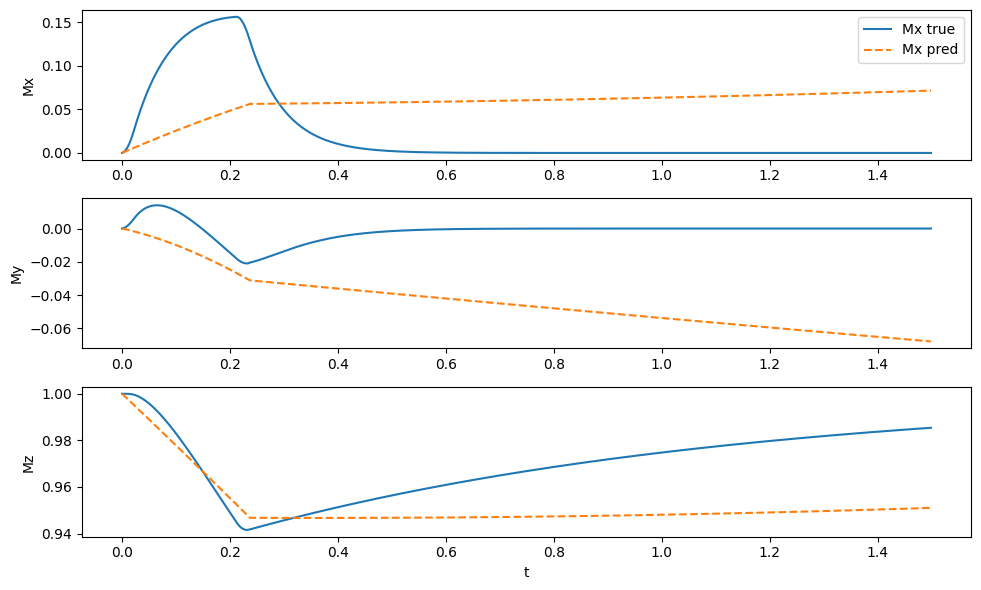

In [78]:
import torch
import matplotlib.pyplot as plt

# example code of visualizing the individual magnetization vector components. Needs a suitable instance of "model" defined
# if there isn't a model defined, run the previous cell to load a the NeuralBlochVoxelUDE

model.eval()

# get one batch from val loader
batch = next(iter(val_loader))
y, y0, u, p = [batch[k].to(DEVICE) for k in ("y", "y0", "u", "p")]
with torch.no_grad():
    print("M", M.shape, "u", u.shape, "p", p.shape, "t", t.shape)
    print("p dim:", p.dim(), "t dim:", t.dim())

    yhat = model(y0, t_shared, u, p)  # (B,T,3)

# pick one trajectory to inspect
i = 0
t_np = t_shared.cpu().numpy()
y_true = y[i].cpu().numpy()   # (T,3)
y_pred = yhat[i].cpu().numpy()

components = ["Mx", "My", "Mz"]
plt.figure(figsize=(10, 6))
for j in range(3):
    plt.subplot(3, 1, j+1)
    plt.plot(t_np, y_true[:, j], label=f"{components[j]} true")
    plt.plot(t_np, y_pred[:, j], "--", label=f"{components[j]} pred")
    plt.ylabel(components[j])
    if j == 0:
        plt.legend()
plt.xlabel("t")
plt.tight_layout()
plt.show()


In [ ]:
def plot_bloch_vector_field_xy(
    model,
    device,
    u,
    p,
    Mz: float = 0.0,
    r: float = 1.0,
    n: int = 25,
    t0: float = 0.0,
    normalize: bool = True,
):
    """
    Visualize the learned Bloch vector field dM/dt in the XY-plane
    at a fixed Mz, time t0, controls u, and parameters p.

    Args:
        model    : NeuralBlochODE instance with a .dynamics(t, M, u, p) method
        device   : torch.device
        u        : 1D tensor of shape (4,)  — same RF/control dim used in training
        p        : 1D tensor of shape (5,)  — same param dim used in training
        Mz       : fixed Mz slice to visualize (e.g., 0 for transverse plane)
        r        : radius/extent in x and y (plot from -r to r)
        n        : number of grid points per axis
        t0       : time at which to evaluate the field
        normalize: if True, normalize arrows for visibility
    """
    model.eval()

    # --- 1. Create grid in the XY-plane ---
    x = torch.linspace(-r, r, n)
    y = torch.linspace(-r, r, n)
    X, Y = torch.meshgrid(x, y, indexing="ij")  # (n, n)

    Mx_flat = X.reshape(-1)
    My_flat = Y.reshape(-1)
    Mz_flat = torch.full_like(Mx_flat, float(Mz))

    # M: (N, 3)
    M = torch.stack([Mx_flat, My_flat, Mz_flat], dim=-1).to(device)
    N = M.shape[0]

    # --- 2. Broadcast controls/params to match grid size ---
    # u: (4,) -> (N, 4), p: (5,) -> (N, 5)
    u = u.to(device).view(1, -1).expand(N, -1)
    p = p.to(device).view(1, -1).expand(N, -1)

    # t0 as scalar tensor (same style as solver)
    t_scalar = torch.tensor(t0, device=device)

    # --- 3. Evaluate dM/dt on the grid ---
    with torch.no_grad():
        dMdt = model.dynamics(t_scalar, M, u, p)  # (N, 3)

    dMx = dMdt[:, 0].reshape(n, n).cpu()
    dMy = dMdt[:, 1].reshape(n, n).cpu()

    X_np = X.cpu().numpy()
    Y_np = Y.cpu().numpy()
    dMx_np = dMx.numpy()
    dMy_np = dMy.numpy()

    if normalize:
        mag = np.sqrt(dMx_np**2 + dMy_np**2) + 1e-8
        dMx_np = dMx_np / mag
        dMy_np = dMy_np / mag

    # --- 4. Plot with quiver ---
    plt.figure(figsize=(6, 6))
    plt.quiver(X_np, Y_np, dMx_np, dMy_np, angles="xy")
    plt.xlabel("Mx")
    plt.ylabel("My")
    plt.title(f"Learned Bloch vector field in XY-plane @ Mz={Mz}, t={t0}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()


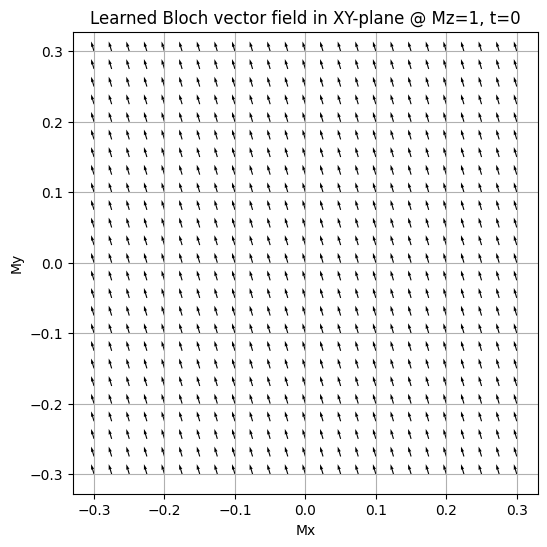

In [80]:
# Tissue parameters: white matter @ 3T (order-of-magnitude realistic)
T1 = 1.0       # seconds   (≈ 1000 ms)
T2 = 0.08         # seconds   (≈ 80 ms)

# Off-resonance: e.g. +50 Hz (B0 inhomogeneity / chemical shift)
delta_f = 50.0    # Hz
delta_omega = 2 * torch.pi * delta_f  # rad/s

# Scaling for RF and gradients (leave at 1.0 unless your dataset uses something else)
B1_scale = 1.0
G_scale  = 1.0

p_example = torch.tensor(
    [T1, T2, delta_omega, B1_scale, G_scale],
    device=device,
    dtype=torch.float32,
)

# RF and gradient controls
# Assume units are "normalized" controls that your network saw during training.
# Here: small B1 along +x, mild readout gradient along x, zero along y.
B1x = 0.01  # small transverse RF amplitude
B1y = 0.35
Gx  = 0.01    # mild gradient
Gy  = 0.0

u_example = torch.tensor(
    [B1x, B1y, Gx, Gy],
    device=device,
    dtype=torch.float32,
)

# --------------------------------------
# Plot the learned Bloch vector field
# --------------------------------------
plot_bloch_vector_field_xy(
    model=model,
    device=device,
    u=u_example,
    p=p_example,
    Mz=1,   # transverse plane
    r=0.3,
    n=25,
    t0=0,
    normalize=False,
)
#Not that useful because vector field does not learn dynamics outside of test cases 


In [ ]:
# Note: this function does not work with the NeuralBlochVoxelUDE
def plot_bloch_vector_field_xz_colored(
    model,
    device,
    u,
    p,
    My: float = 0.0,          # fixed My slice
    Mx_range=(-0.5, 0.5),     # widen ranges a bit to see more variation
    Mz_range=(0.0, 1.0),
    nx: int = 25,
    nz: int = 25,
    t0: float = 0.0,
):
    """
    Learned Bloch vector field in the Mx–Mz plane at fixed My,
    with arrow color = |dM/dt| magnitude (no normalization).
    """
    model.eval()

    # 1. Grid in Mx–Mz
    x = torch.linspace(Mx_range[0], Mx_range[1], nx)
    z = torch.linspace(Mz_range[0], Mz_range[1], nz)
    X, Z = torch.meshgrid(x, z, indexing="ij")  # (nx, nz)

    Mx_flat = X.reshape(-1)
    Mz_flat = Z.reshape(-1)
    My_flat = torch.full_like(Mx_flat, float(My))

    M = torch.stack([Mx_flat, My_flat, Mz_flat], dim=-1).to(device)  # (N,3)
    N = M.shape[0]

    # 2. Broadcast controls/params
    u = u.to(device).view(1, -1).expand(N, -1)
    p = p.to(device).view(1, -1).expand(N, -1)

    t_scalar = torch.tensor(t0, device=device)

    # 3. Evaluate dynamics
    with torch.no_grad():
        dMdt = model.dynamics(t_scalar, M, u, p)  # (N,3)

    dMx = dMdt[:, 0].reshape(nx, nz).cpu().numpy()
    dMz = dMdt[:, 2].reshape(nx, nz).cpu().numpy()
    X_np = X.cpu().numpy()
    Z_np = Z.cpu().numpy()

    # magnitude for coloring
    mag = np.sqrt(dMx**2 + dMz**2)

    # 4. Plot: quiver colored by magnitude
    plt.figure(figsize=(6, 6))
    Q = plt.quiver(
        X_np, Z_np, dMx, dMz, mag,
        angles="xy",
        cmap="viridis",
        scale=None  # let matplotlib choose scale from raw magnitudes
    )
    plt.xlabel("Mx")
    plt.ylabel("Mz")
    plt.title(f"Learned Bloch vector field in Mx–Mz plane @ My={My}, t={t0}")
    plt.axis("equal")
    plt.grid(True)
    cbar = plt.colorbar(Q)
    cbar.set_label("|dM/dt|")
    plt.show()



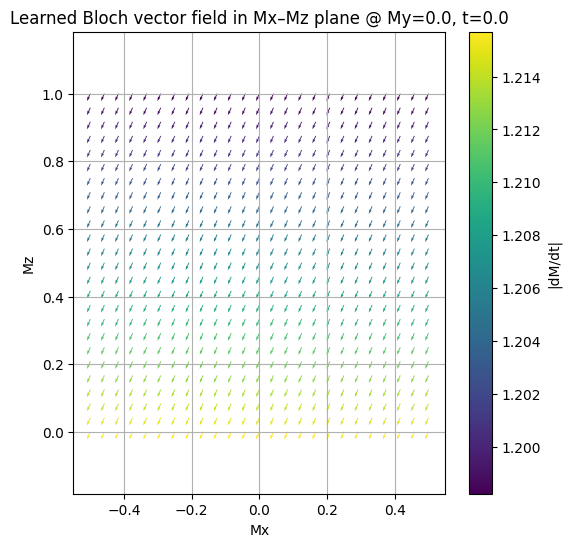

In [ ]:
# Note: this function does not work with the NeuralBlochVoxelUDE
plot_bloch_vector_field_xz_colored(
    model=model,
    device=device,
    u=u_example,
    p=p_example,
    My=0.0,
    Mx_range=(-0.5, 0.5),
    Mz_range=(0.0, 1.0),
    nx=25,
    nz=25,
    t0=0.0,
)

In [72]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

def plot_local_3d_field_around_state(
    model,
    device,
    t_shared: torch.Tensor,      # (T,)
    M_traj: torch.Tensor,        # (T,3) true M(t) for ONE trajectory
    u_traj: torch.Tensor,        # (T,4) controls for that trajectory
    p_vec: torch.Tensor,         # (5,)   params for that trajectory
    t_idx: int,                  # time index to visualize
    r: float = 0.15,             # half-width of local cube in M-space
    n: int = 5,                  # grid points per axis (n^3 total)
    normalize: bool = True,
):
    """
    Visualize the learned vector field in a small 3D neighborhood
    around the true magnetization M(t_idx).

    - model.dynamics(t, M, u, p) is used
    - u, p are taken from this trajectory at time t_idx
    """

    model.eval()
    M_traj = M_traj.to(device)
    u_traj = u_traj.to(device)
    p_vec  = p_vec.to(device)

    T = M_traj.shape[0]
    assert 0 <= t_idx < T, "t_idx out of range"

    # --- 1. Center state & time ---
    M0 = M_traj[t_idx]           # (3,)
    t0 = t_shared[t_idx].to(device)

    # --- 2. Build a small 3D cube around M0 ---
    lin = torch.linspace(-r, r, n, device=device)
    dMx, dMy, dMz = torch.meshgrid(lin, lin, lin, indexing="ij")  # (n,n,n)

    Mx = M0[0] + dMx
    My = M0[1] + dMy
    Mz = M0[2] + dMz
    M_grid = torch.stack([Mx, My, Mz], dim=-1).reshape(-1, 3)     # (N,3)
    N = M_grid.shape[0]

    # --- 3. Broadcast controls/params for this time ---
    u0 = u_traj[t_idx].view(1, -1).expand(N, -1)  # (N,4)
    p0 = p_vec.view(1, -1).expand(N, -1)          # (N,5)

    # --- 4. Evaluate learned dynamics ---
    with torch.no_grad():
        dMdt = model.dynamics(t0, M_grid, u0, p0)  # (N,3)

    dMx = dMdt[:, 0].reshape(n, n, n).cpu().numpy()
    dMy = dMdt[:, 1].reshape(n, n, n).cpu().numpy()
    dMz = dMdt[:, 2].reshape(n, n, n).cpu().numpy()

    X = Mx.cpu().numpy()
    Y = My.cpu().numpy()
    Z = Mz.cpu().numpy()

    # Optionally normalize arrow directions for clearer geometry
    if normalize:
        mag = np.sqrt(dMx**2 + dMy**2 + dMz**2) + 1e-8
        dMx /= mag
        dMy /= mag
        dMz /= mag

    # --- 5. 3D quiver plot ---
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Subsample a bit if grid is dense
    step = max(1, n // 5)
    ax.quiver(
        X[::step, ::step, ::step],
        Y[::step, ::step, ::step],
        Z[::step, ::step, ::step],
        dMx[::step, ::step, ::step],
        dMy[::step, ::step, ::step],
        dMz[::step, ::step, ::step],
        length=0.1,
        normalize=False,
    )

    # Also plot the true trajectory for context
    M_traj_np = M_traj.cpu().numpy()
    ax.plot(
        M_traj_np[:, 0],
        M_traj_np[:, 1],
        M_traj_np[:, 2],
        "k-",
        label="True M(t)"
    )
    ax.scatter(
        M0[0].item(), M0[1].item(), M0[2].item(),
        color="red", s=50, label=f"State at t_idx={t_idx}"
    )

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Local 3D vector field around M(t[{t_idx}])")
    ax.legend()
    ax.set_box_aspect((1, 1, 1))
    plt.tight_layout()
    plt.show()


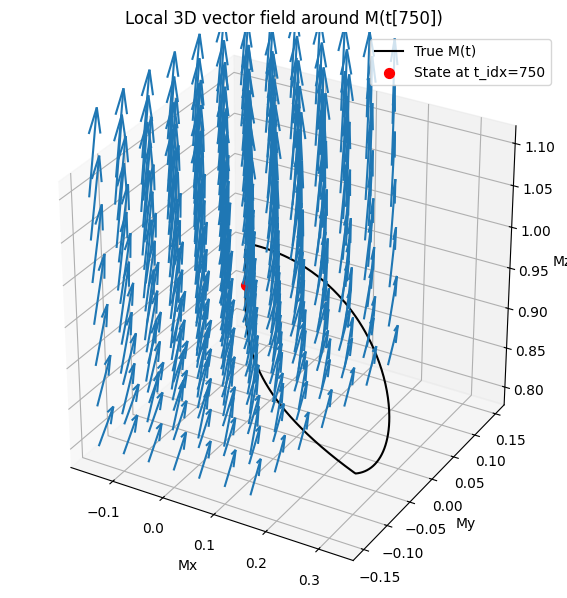

In [49]:
batch = next(iter(train_loader))
y  = batch["y"]   # (B,T,3)
u  = batch["u"]   # (B,T,4)
p  = batch["p"]   # (B,5)

# Pick one index with strong dynamics (or just 0)
b_idx  = 0
M_traj = y[b_idx]     # (T,3)
u_traj = u[b_idx]     # (T,4)
p_vec  = p[b_idx]     # (5,)

# Choose a time index where |dM/dt| is large (here: middle of the sequence)
t_idx = y.shape[1] // 2

plot_local_3d_field_around_state(
    model=model,
    device=device,
    t_shared=t_shared,
    M_traj=M_traj,
    u_traj=u_traj,
    p_vec=p_vec,
    t_idx=t_idx,
    r=0.15,
    n=7,
    normalize=True,
)


Plotting local field at t_idx=0


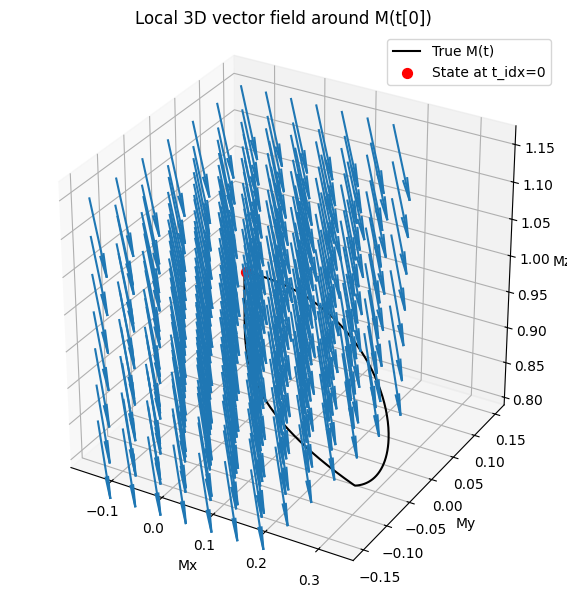

Plotting local field at t_idx=50


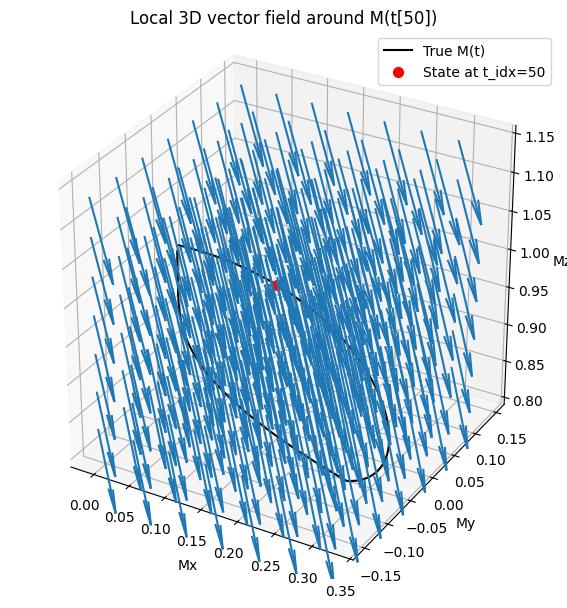

Plotting local field at t_idx=100


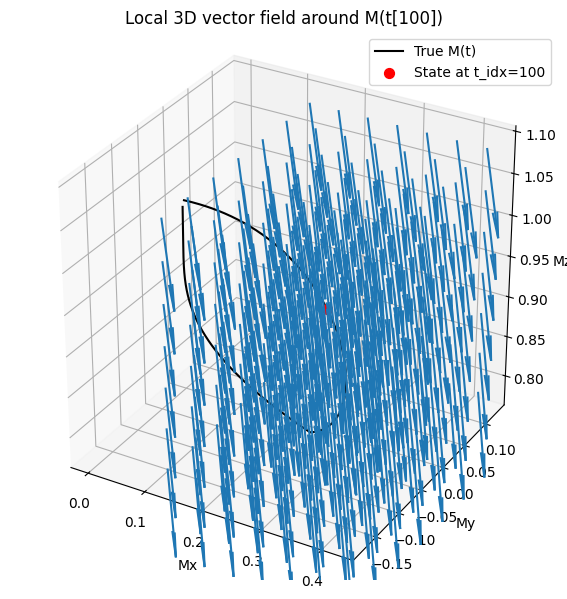

Plotting local field at t_idx=200


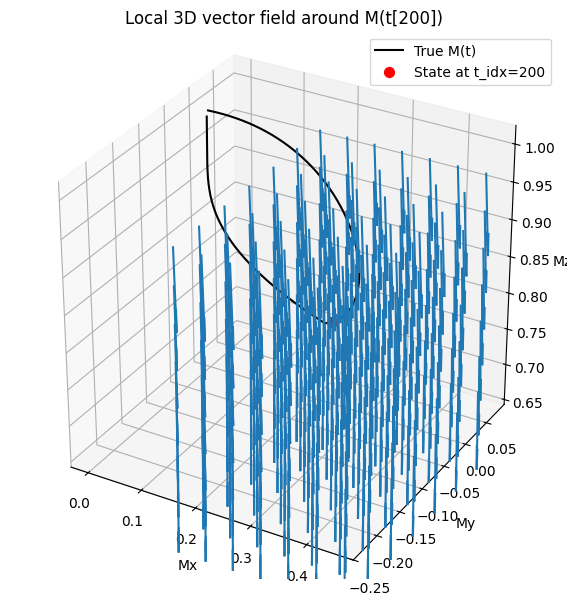

Plotting local field at t_idx=400


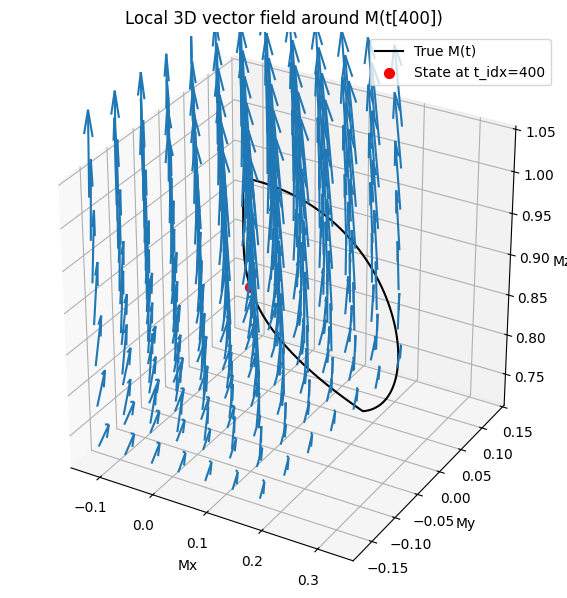

Plotting local field at t_idx=800


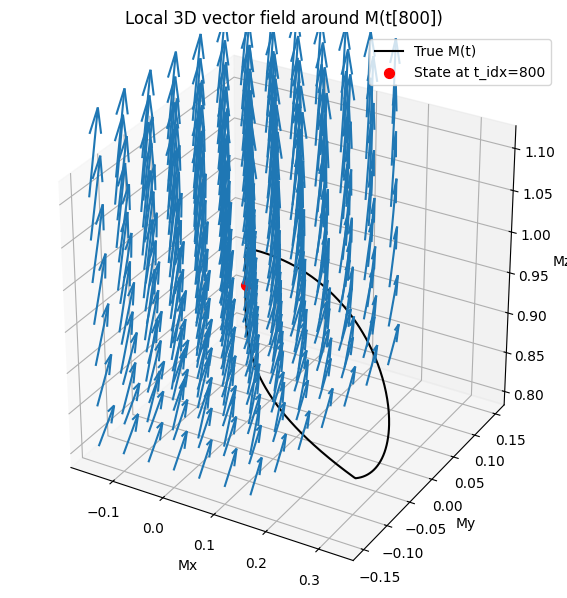

Plotting local field at t_idx=1000


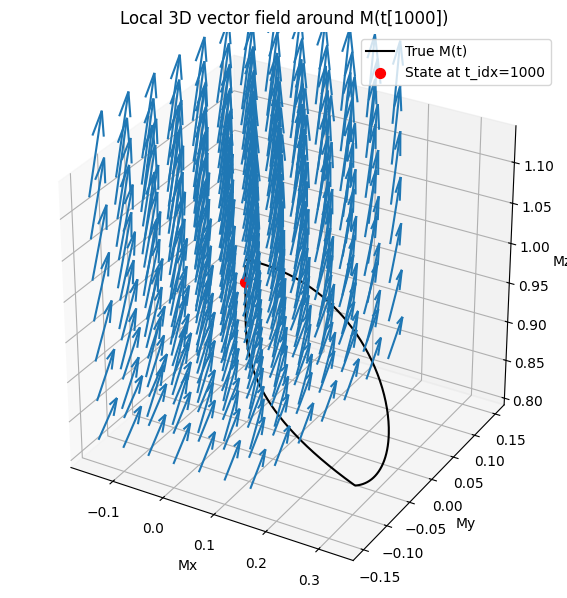

In [50]:
for t_idx in [0, 50, 100, 200, 400, 800, 1000]:
    print(f"Plotting local field at t_idx={t_idx}")
    plot_local_3d_field_around_state(
        model=model,
        device=device,
        t_shared=t_shared,
        M_traj=M_traj,
        u_traj=u_traj,
        p_vec=p_vec,
        t_idx=t_idx,
        r=0.15,
        n=7,
        normalize=True,
    )

In [51]:
from matplotlib.animation import FuncAnimation

def animate_local_3d_field_around_traj(
    model,
    device,
    t_shared: torch.Tensor,   # (T,)
    M_traj: torch.Tensor,     # (T,3)   true magnetization from dataset
    u_traj: torch.Tensor,     # (T,4)   controls for that trajectory
    p_vec: torch.Tensor,      # (5,)    params for that trajectory
    t_indices=None,           # list/array of time indices to show
    r: float = 0.15,          # half-width of local cube
    n: int = 5,               # grid points per axis (n^3 points)
    normalize: bool = True,
    interval: int = 150,      # ms between frames
):
    """
    Make an animation of the local 3D learned vector field around M(t)
    for a sequence of time indices.
    """
    model.eval()
    M_traj = M_traj.to(device)
    u_traj = u_traj.to(device)
    p_vec  = p_vec.to(device)

    T = M_traj.shape[0]
    if t_indices is None:
        # default: 40 frames spaced across the sequence
        n_frames = min(40, T)
        t_indices = np.linspace(0, T - 1, n_frames, dtype=int)
    else:
        t_indices = np.asarray(t_indices, dtype=int)

    # Precompute trajectory as numpy for plotting
    M_traj_np = M_traj.cpu().numpy()
    t_np = t_shared.cpu().numpy()

    # Prepare grid offsets (same for all frames, just centered differently)
    lin = torch.linspace(-r, r, n, device=device)
    dMx, dMy, dMz = torch.meshgrid(lin, lin, lin, indexing="ij")  # (n,n,n)

    # Figure + axes
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Plot full trajectory once
    ax.plot(
        M_traj_np[:, 0],
        M_traj_np[:, 1],
        M_traj_np[:, 2],
        "k-",
        label="True M(t)",
        linewidth=1.0,
    )

    # Scatter for current state
    state_scatter = ax.scatter(
        [], [], [],
        color="red", s=40, label="M(t_k)"
    )

    # Placeholder quiver; we’ll replace it in each frame
    quiv_container = {"obj": None}

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.legend(loc="upper left")
    ax.set_box_aspect((1, 1, 1))

    # Fix reasonable axis limits from trajectory
    margin = 0.2
    ax.set_xlim(M_traj_np[:, 0].min() - margin, M_traj_np[:, 0].max() + margin)
    ax.set_ylim(M_traj_np[:, 1].min() - margin, M_traj_np[:, 1].max() + margin)
    ax.set_zlim(M_traj_np[:, 2].min() - margin, M_traj_np[:, 2].max() + margin)

    def update(frame_idx):
        t_idx = int(t_indices[frame_idx])
        M0 = M_traj[t_idx]                 # (3,)
        t0 = t_shared[t_idx].to(device)

        # Local cube around M0
        Mx = M0[0] + dMx
        My = M0[1] + dMy
        Mz = M0[2] + dMz
        M_grid = torch.stack([Mx, My, Mz], dim=-1).reshape(-1, 3)  # (N,3)
        N = M_grid.shape[0]

        # Controls/params at this time
        u0 = u_traj[t_idx].view(1, -1).expand(N, -1)  # (N,4)
        p0 = p_vec.view(1, -1).expand(N, -1)          # (N,5)

        with torch.no_grad():
            dMdt = model.dynamics(t0, M_grid, u0, p0)  # (N,3)

        dMx_np = dMdt[:, 0].reshape(n, n, n).cpu().numpy()
        dMy_np = dMdt[:, 1].reshape(n, n, n).cpu().numpy()
        dMz_np = dMdt[:, 2].reshape(n, n, n).cpu().numpy()

        X = Mx.cpu().numpy()
        Y = My.cpu().numpy()
        Z = Mz.cpu().numpy()

        if normalize:
            mag = np.sqrt(dMx_np**2 + dMy_np**2 + dMz_np**2) + 1e-8
            dMx_np /= mag
            dMy_np /= mag
            dMz_np /= mag

        # Remove old quiver
        if quiv_container["obj"] is not None:
            quiv_container["obj"].remove()

        # Subsample for display if grid is dense
        step = max(1, n // 5)
        quiv = ax.quiver(
            X[::step, ::step, ::step],
            Y[::step, ::step, ::step],
            Z[::step, ::step, ::step],
            dMx_np[::step, ::step, ::step],
            dMy_np[::step, ::step, ::step],
            dMz_np[::step, ::step, ::step],
            length=0.1,
            normalize=False,
        )
        quiv_container["obj"] = quiv

        # Update current-state marker
        M0_np = M0.cpu().numpy()
        state_scatter._offsets3d = (
            [M0_np[0]], [M0_np[1]], [M0_np[2]]
        )

        ax.set_title(
            f"Local 3D vector field around M(t[{t_idx}]), t={t_np[t_idx]:.3f} s"
        )

        return quiv, state_scatter

    anim = FuncAnimation(
        fig,
        update,
        frames=len(t_indices),
        interval=interval,
        blit=False,
    )

    plt.close(fig)   # so Jupyter doesn’t show a static figure
    return anim


In [52]:
# Pick one trajectory from the dataset
batch = next(iter(train_loader))
y  = batch["y"]   # (B,T,3)
u  = batch["u"]   # (B,T,4)
p  = batch["p"]   # (B,5)

b_idx  = 0
M_traj = y[b_idx]
u_traj = u[b_idx]
p_vec  = p[b_idx]

# Choose time indices (e.g. 40 frames across the sequence)
T = y.shape[1]
t_indices = np.linspace(0, T-1, 40, dtype=int)

anim = animate_local_3d_field_around_traj(
    model=model,
    device=device,
    t_shared=t_shared,
    M_traj=M_traj,
    u_traj=u_traj,
    p_vec=p_vec,
    t_indices=t_indices,
    r=0.12,
    n=5,
    interval=150,
)

""" NOTE - MovieWriter (ffmpeg) is needed to run the code below."""
# In Jupyter:
# from IPython.display import HTML
# HTML(anim.to_html5_video())
# or: anim.save("local_field.mp4", fps=6, dpi=150)


' NOTE - MovieWriter (ffmpeg) is needed to run the code below.'

In [53]:
@torch.no_grad()
def plot_trajectory_comparison(
    model,
    device,
    t_shared: torch.Tensor,   # (T,)
    batch: dict,
    traj_idx: int = 0,        # which trajectory in the batch
):
    """
    Compare ground-truth vs model-predicted trajectory for a single sample.

    Shows:
      1) 3D Mx-My-Mz trajectory (true vs pred)
      2) Mx(t), My(t), Mz(t) vs time
      3) Prints RMSE per component and overall
    """
    model.eval()

    # --- pull one trajectory and move to device ---
    y_true = batch["y"][traj_idx].to(device)    # (T,3)
    y0     = batch["y0"][traj_idx].to(device)   # (3,)
    u      = batch["u"][traj_idx].to(device)    # (T,4)
    p      = batch["p"][traj_idx].to(device)    # (5,)

    # model expects batch dimension
    y_pred = model(
        y0.unsqueeze(0),        # (1,3)
        t_shared,               # (T,)
        u.unsqueeze(0),         # (1,T,4)
        p.unsqueeze(0),         # (1,5)
    )[0]                        # back to (T,3)

    t_np   = t_shared.cpu().numpy()
    y_true_np = y_true.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()

    # --------- metrics ---------
    diff = y_pred_np - y_true_np
    mse_per_comp = np.mean(diff**2, axis=0)        # (3,)
    rmse_per_comp = np.sqrt(mse_per_comp)
    rmse_overall = np.sqrt(np.mean(diff**2))

    print("RMSE per component [Mx, My, Mz]:", rmse_per_comp)
    print("Overall RMSE:", rmse_overall)

    # --------- 3D trajectory plot ---------
    fig = plt.figure(figsize=(12, 5))

    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax3d.plot(
        y_true_np[:, 0], y_true_np[:, 1], y_true_np[:, 2],
        "k-", label="True M(t)", linewidth=1.5,
    )
    ax3d.plot(
        y_pred_np[:, 0], y_pred_np[:, 1], y_pred_np[:, 2],
        "r--", label="Pred M(t)", linewidth=1.5,
    )
    ax3d.set_xlabel("Mx")
    ax3d.set_ylabel("My")
    ax3d.set_zlabel("Mz")
    ax3d.set_title(f"3D trajectory comparison (sample #{traj_idx})")
    ax3d.legend()

    # --------- components vs time ---------
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(t_np, y_true_np[:, 0], "k-",  label="Mx true")
    ax.plot(t_np, y_pred_np[:, 0], "r--", label="Mx pred")

    ax.plot(t_np, y_true_np[:, 1], "b-",  label="My true")
    ax.plot(t_np, y_pred_np[:, 1], "c--", label="My pred")

    ax.plot(t_np, y_true_np[:, 2], "g-",  label="Mz true")
    ax.plot(t_np, y_pred_np[:, 2], "y--", label="Mz pred")

    ax.set_xlabel("t (s)")
    ax.set_ylabel("Magnetization")
    ax.set_title("Components vs time")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True)

    plt.tight_layout()
    plt.show()


RMSE per component [Mx, My, Mz]: [0.02855239 0.02375562 0.00239353]
Overall RMSE: 0.021488734


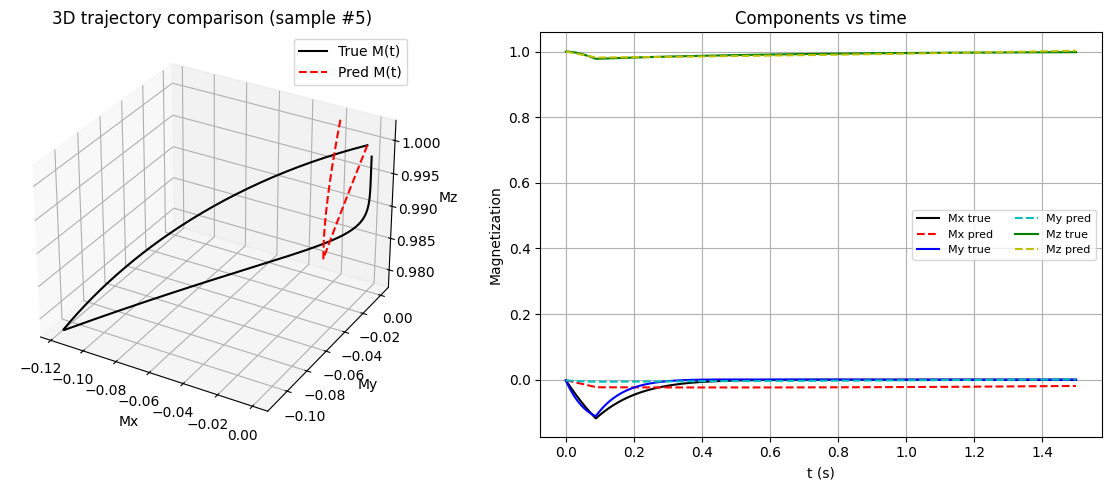

In [54]:
batch = next(iter(train_loader))  
plot_trajectory_comparison(model, device, t_shared, batch, traj_idx=5)

In [55]:
@torch.no_grad()
def plot_vector_field_along_trajectory(
    model,
    device,
    batch,
    t_shared,
    traj_idx: int = 0,
    step: int = 2,
    t_offset: float = 0.0,
):
    """
    Plot dM/dt as arrows along a *real* trajectory M(t) from the dataset.

    Args:
        model    : trained Neural ODE model with .dynamics(t, M, u, p)
        device   : torch.device
        batch    : one batch from your DataLoader (dict with 'y','u','p')
        t_shared : 1D tensor of times, shape (T,)
        traj_idx : which trajectory in the batch to plot (0 <= traj_idx < B)
        step     : subsample factor along time (plot every 'step'-th point)
        t_offset : optional time offset if your internal t is not exactly t_shared
    """
    model.eval()

    # Extract data for this trajectory
    y = batch["y"].to(device)    # (B,T,3)
    u = batch["u"].to(device)    # (B,T,4)
    p = batch["p"].to(device)    # (B,5)

    M_traj = y[traj_idx]         # (T,3)
    u_traj = u[traj_idx]         # (T,4)
    p_traj = p[traj_idx]         # (5,)
    T = M_traj.shape[0]

    # Subsample times to avoid too many arrows
    idx = torch.arange(0, T, step, device=device)
    M_sub = M_traj[idx]          # (N,3)
    u_sub = u_traj[idx]          # (N,4)
    t_sub = t_shared[idx].to(device) + t_offset  # (N,)

    # Repeat p for each time
    p_sub = p_traj.unsqueeze(0).expand(M_sub.shape[0], -1)  # (N,5)

    # Compute dM/dt at each sampled point
    dMdt_list = []
    for k in range(M_sub.shape[0]):
        t_k = t_sub[k]
        M_k = M_sub[k].unsqueeze(0)      # (1,3)
        u_k = u_sub[k].unsqueeze(0)      # (1,4)
        p_k = p_sub[k].unsqueeze(0)      # (1,5)
        dMdt_k = model.dynamics(t_k, M_k, u_k, p_k)  # (1,3)
        dMdt_list.append(dMdt_k.squeeze(0))
    dMdt = torch.stack(dMdt_list, dim=0).cpu().numpy()  # (N,3)

    M_sub_np = M_sub.cpu().numpy()
    Mx, My, Mz = M_sub_np[:,0], M_sub_np[:,1], M_sub_np[:,2]
    dMx, dMy, dMz = dMdt[:,0], dMdt[:,1], dMdt[:,2]

    # --- 3D quiver along trajectory ---
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Plot the trajectory itself
    ax.plot(Mx, My, Mz, "-o", markersize=3, label="M(t) trajectory")

    # Plot local vector field (dM/dt) at those points
    d_max = np.max(np.linalg.norm(dMdt, axis=1))
    scale = 0.1 / d_max  # shrink arrows

    ax.quiver(Mx, My, Mz, 
              dMx * scale, dMy * scale, dMz * scale,
              length=1.0, normalize=False)
    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Local vector field along trajectory #{traj_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()


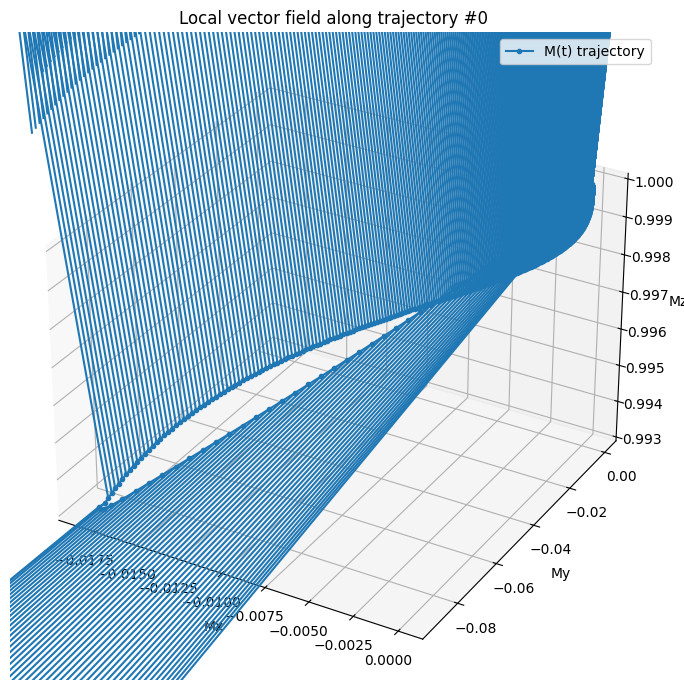

In [56]:
# Get one batch from your DataLoader
batch = next(iter(train_loader))  # or val_loader

plot_vector_field_along_trajectory(
    model=model,
    device=device,
    batch=batch,
    t_shared=t_shared,  # same as used in training
    traj_idx=0,         # pick which trajectory in the batch
    step=2,             # plot every 2nd time step
)

In [57]:
model.eval()
device = DEVICE

batch = next(iter(train_loader))
y  = batch["y"].to(device)   # (B,T,3)
u  = batch["u"].to(device)   # (B,T,4)
p  = batch["p"].to(device)   # (B,5)
t  = t_shared.to(device)     # (T,)

B, T, _ = y.shape

# ---- finite-difference dy/dt from data ----
dt = (t[1:] - t[:-1]).mean().item()
dy_dt_fd = (y[:,1:,:] - y[:,:-1,:]) / dt        # (B, T-1, 3)

# ---- model-based derivative at same states ----
with torch.no_grad():
    dM_model_list = []
    for k in range(T-1):
        t_k = t[k]
        M_k = y[:,k,:]          # (B,3)
        u_k = u[:,k,:]          # (B,4)
        p_k = p                 # (B,5) same p for all time in that traj batch

        dM_k = model.dynamics(t_k, M_k, u_k, p_k)   # (B,3)
        dM_model_list.append(dM_k)

    dM_model = torch.stack(dM_model_list, dim=1)    # (B, T-1, 3)

err = (dM_model - dy_dt_fd).cpu().numpy()
mse_deriv  = np.mean(err**2)
rmse_deriv = np.sqrt(mse_deriv)

print("Derivative MSE:", mse_deriv)
print("Derivative RMSE:", rmse_deriv)

# per-component
mse_comp  = np.mean(err**2, axis=(0,1))
rmse_comp = np.sqrt(mse_comp)
print("Per-component derivative RMSE [Mx, My, Mz]:", rmse_comp)



Derivative MSE: 1.3048756
Derivative RMSE: 1.1423116
Per-component derivative RMSE [Mx, My, Mz]: [1.3114957  1.4340584  0.37143728]


In [58]:
# assuming you still have dy_dt_fd and dM_model from before
dy = dy_dt_fd.cpu().numpy()

true_mse  = np.mean(dy**2)
true_rmse = np.sqrt(true_mse)

rel_rmse  = rmse_deriv / (true_rmse + 1e-8)

print("True derivative RMSE:", true_rmse)
print("Relative RMSE (model / true):", rel_rmse)


True derivative RMSE: 1.1558521
Relative RMSE (model / true): 0.9882852516449196


In [59]:
@torch.no_grad()
def plot_vector_field_on_shell(model, device, loader, t_shared, 
                               num_traj=10, t_idx=100, subsample=5):
    """
    Plot dM/dt on a shell of states taken from real data,
    normalized so it looks like a Bloch sphere.
    """
    model.eval()
    batch = next(iter(loader))
    y = batch["y"].to(device)   # (B,T,3)
    u = batch["u"].to(device)   # (B,T,4)
    p = batch["p"].to(device)   # (B,5)
    t = t_shared.to(device)

    B, T, _ = y.shape
    num_traj = min(num_traj, B)
    t_idx = min(t_idx, T-1)

    # Take a slice across several trajectories at fixed time
    M = y[:num_traj, t_idx, :]          # (num_traj, 3)
    u_slice = u[:num_traj, t_idx, :]    # (num_traj, 4)
    p_slice = p[:num_traj, :]           # (num_traj, 5)
    t0 = t[t_idx]

    # Optionally jitter around those points to get a "shell"
    jitter = 0.02 * M.norm(dim=-1, keepdim=True)
    M = M + torch.randn_like(M) * jitter

    # Normalize for plotting so points lie near unit sphere
    M_norm = M.norm(dim=-1, keepdim=True) + 1e-8
    M_plot = M / M_norm

    dMdt = model.dynamics(t0, M, u_slice, p_slice)   # (num_traj,3)

    # Scale arrows so they fit nicely
    d = dMdt.cpu().numpy()
    d_norm = np.linalg.norm(d, axis=1, keepdims=True) + 1e-8
    d_unit = d / d_norm
    arrow_scale = 0.2
    d_plot = d_unit * arrow_scale

    M_np = M_plot.cpu().numpy()
    Mx, My, Mz = M_np[:,0], M_np[:,1], M_np[:,2]
    dMx, dMy, dMz = d_plot[:,0], d_plot[:,1], d_plot[:,2]

    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection="3d")

    # Draw unit sphere wireframe for context
    u_s = np.linspace(0, 2*np.pi, 40)
    v_s = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u_s), np.sin(v_s))
    ys = np.outer(np.sin(u_s), np.sin(v_s))
    zs = np.outer(np.ones_like(u_s), np.cos(v_s))
    ax.plot_wireframe(xs, ys, zs, color="lightgray", linewidth=0.3, alpha=0.5)

    # Plot points and arrows
    ax.scatter(Mx, My, Mz, s=20, label="states (normalized)")
    ax.quiver(Mx, My, Mz, dMx, dMy, dMz, length=1.0, normalize=False, color="red")

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Learned vector field on normalized shell at t index {t_idx}")
    ax.set_box_aspect([1,1,1])
    plt.legend()
    plt.show()


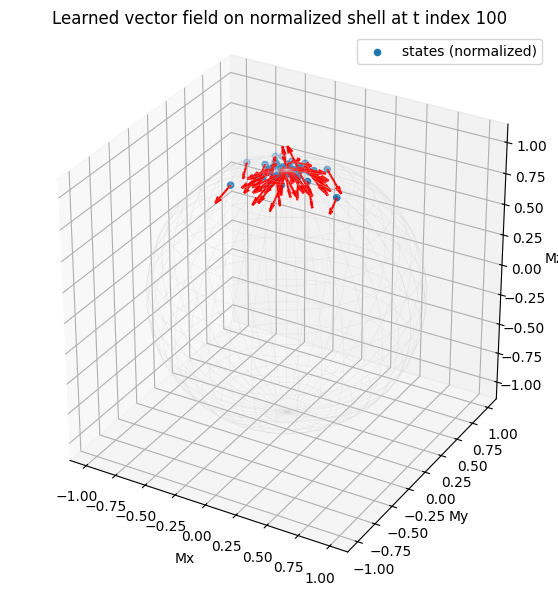

In [60]:
plot_vector_field_on_shell(
    model, DEVICE, train_loader, t_shared,
    num_traj=50, t_idx=100, subsample=1
)

In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation

def animate_bloch_trajectory(model, device, loader, t_shared, traj_idx=0, save=None):
    model.eval()

    batch = next(iter(loader))
    y  = batch["y"].to(device)   # (B,T,3)
    u  = batch["u"].to(device)   # (B,T,4)
    p  = batch["p"].to(device)
    t  = t_shared.to(device)

    M = y[traj_idx]     # (T,3)
    u_traj = u[traj_idx]
    p_traj = p[traj_idx].unsqueeze(0)

    # normalize for visualization (no physical change)
    M_plot = M / (M.norm(dim=1, keepdim=True) + 1e-8)
    M_np = M_plot.cpu().numpy()
    Mx, My, Mz = M_np[:,0], M_np[:,1], M_np[:,2]

    # --- set up 3D plot ---
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # draw sphere
    u_s = np.linspace(0, 2*np.pi, 40)
    v_s = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u_s), np.sin(v_s))
    ys = np.outer(np.sin(u_s), np.sin(v_s))
    zs = np.outer(np.ones_like(u_s), np.cos(v_s))
    ax.plot_wireframe(xs, ys, zs, color="lightgray", alpha=0.3, linewidth=0.3)

    point, = ax.plot([], [], [], 'bo', markersize=8)
    arrow = ax.quiver(0,0,0,0,0,0)

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_title("Neural ODE Bloch trajectory")

    # --- animation function ---
    def update(k):
        nonlocal arrow

        # point location
        M_k = M_plot[k].unsqueeze(0)
        u_k = u_traj[k].unsqueeze(0)
        t_k = t[k]

        # compute derivative
        dMdt = model.dynamics(t_k, M[k].unsqueeze(0), u_k, p_traj)[0]
        dMdt_np = (dMdt / (dMdt.norm() + 1e-8)).cpu().numpy() * 0.2  # scaled

        # update point
        point.set_data([Mx[k]], [My[k]])
        point.set_3d_properties([Mz[k]])

        # update arrow (remove old one)
        arrow.remove()
        arrow = ax.quiver(
            Mx[k], My[k], Mz[k],
            dMdt_np[0], dMdt_np[1], dMdt_np[2],
            color='red', length=1.0, normalize=False
        )

        return point, arrow

    anim = animation.FuncAnimation(fig, update, frames=len(M), interval=50, blit=False)

    if save:
        anim.save(save, writer='ffmpeg', fps=20)
        print("Saved animation to", save)

    plt.show()

    return anim


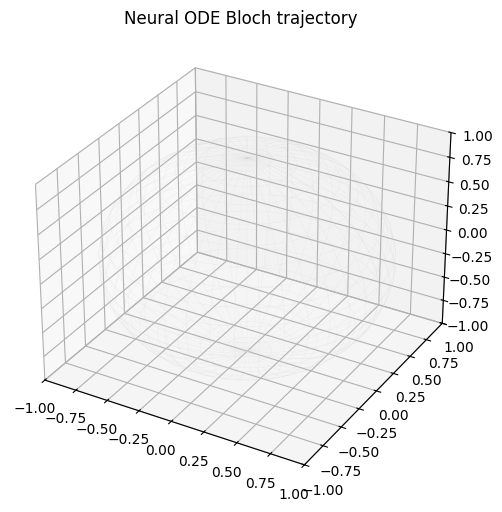

In [62]:
animate_bloch_trajectory(model, DEVICE, train_loader, t_shared, traj_idx=0)

In [63]:
def animate_raw_trajectory(model, device, loader, t_shared, traj_idx=0, save=None):
    model.eval()

    batch = next(iter(loader))
    y  = batch["y"].to(device)   # (B,T,3)
    u  = batch["u"].to(device)   # (B,T,4)
    p  = batch["p"].to(device)
    t  = t_shared.to(device)

    M = y[traj_idx]              # (T,3)
    M_np = M.cpu().numpy()
    Mx, My, Mz = M_np[:,0], M_np[:,1], M_np[:,2]

    # --- set up 3D plot ---
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # full trajectory line
    ax.plot(Mx, My, Mz, "-k", linewidth=1, alpha=0.6)

    # point that will move
    point, = ax.plot([], [], [], 'bo', markersize=6)

    # axis limits with a small margin
    margin = 0.05
    ax.set_xlim(Mx.min()-margin, Mx.max()+margin)
    ax.set_ylim(My.min()-margin, My.max()+margin)
    ax.set_zlim(Mz.min()-margin, Mz.max()+margin)

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"Raw magnetization trajectory #{traj_idx}")

    def update(k):
        point.set_data([Mx[k]], [My[k]])
        point.set_3d_properties([Mz[k]])
        return point,

    anim = animation.FuncAnimation(fig, update, frames=len(M), interval=50, blit=True)

    if save is not None:
        anim.save(save, writer="ffmpeg", fps=20)
        print("Saved animation to", save)

    plt.show()
    return anim


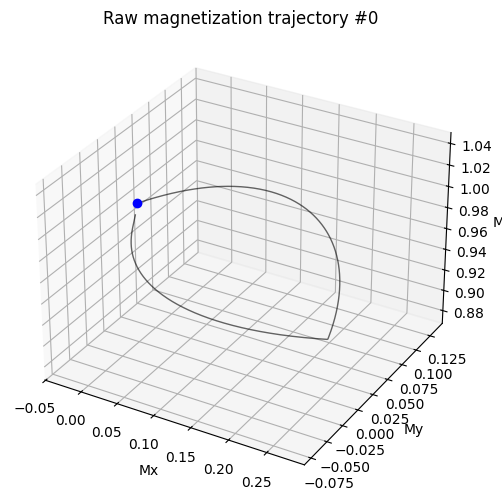

In [64]:
animate_raw_trajectory(model, DEVICE, train_loader, t_shared, traj_idx=0)


In [65]:
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # noqa

def animate_npz_trajectory(y_all, t_np, traj_idx, save=None):
    """
    Animate a single trajectory from the NPZ file.
    Shows the true magnetization path in 3D with a moving point.
    """
    M = y_all[traj_idx]      # (T,3)
    Mx, My, Mz = M[:,0], M[:,1], M[:,2]
    T_len = M.shape[0]

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # Plot full path
    ax.plot(Mx, My, Mz, "-k", linewidth=1, alpha=0.6)

    # Moving point
    point, = ax.plot([], [], [], "bo", markersize=6)

    # Set axis limits with a bit of margin
    margin = 0.05 * max(
        max(Mx.max()-Mx.min(), 1e-3),
        max(My.max()-My.min(), 1e-3),
        max(Mz.max()-Mz.min(), 1e-3),
    )
    ax.set_xlim(Mx.min()-margin, Mx.max()+margin)
    ax.set_ylim(My.min()-margin, My.max()+margin)
    ax.set_zlim(Mz.min()-margin, Mz.max()+margin)

    ax.set_xlabel("Mx")
    ax.set_ylabel("My")
    ax.set_zlabel("Mz")
    ax.set_title(f"True magnetization trajectory #{traj_idx}")

    def update(frame):
        point.set_data([Mx[frame]], [My[frame]])
        point.set_3d_properties([Mz[frame]])
        return point,

    anim = animation.FuncAnimation(
        fig, update, frames=T_len,
        interval=50, blit=True
    )

    if save is not None:
        anim.save(save, writer="ffmpeg", fps=20)
        print("Saved animation to", save)

    plt.show()
    return anim


Animating trajectory 1804 (rank 1)


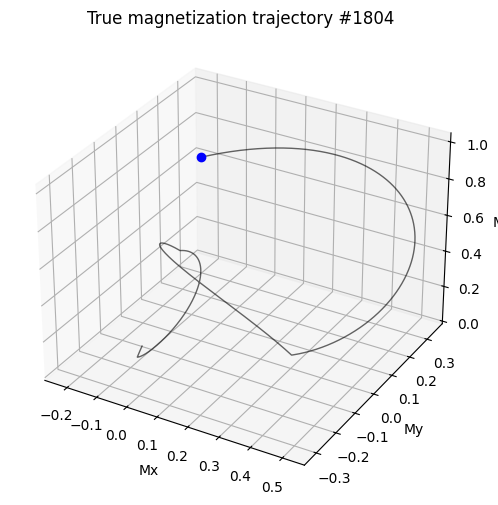

Animating trajectory 1890 (rank 2)


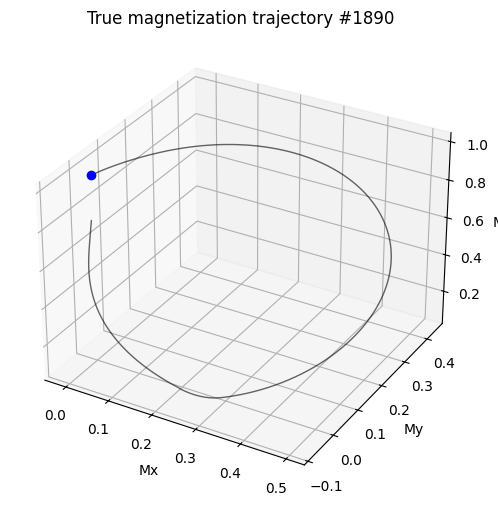

Animating trajectory 2920 (rank 3)


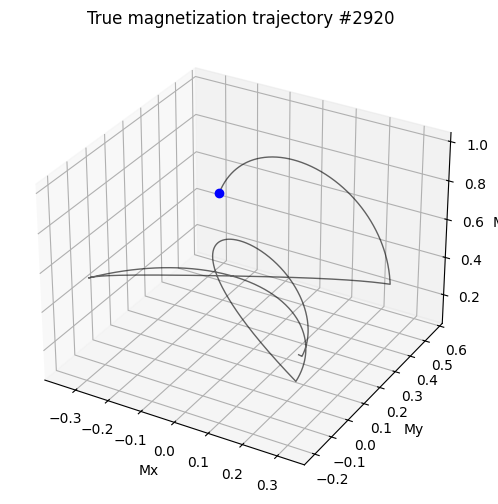

Animating trajectory 1710 (rank 4)


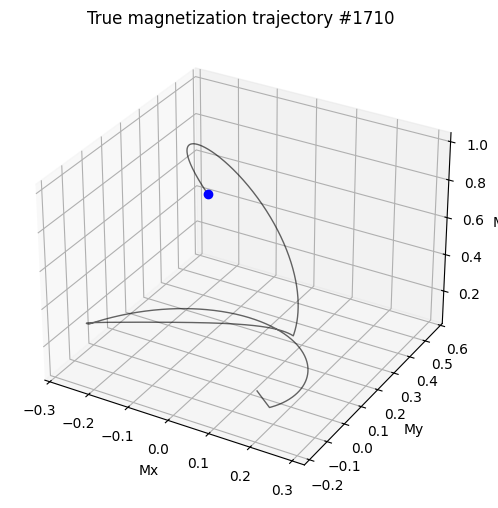

Animating trajectory 763 (rank 5)


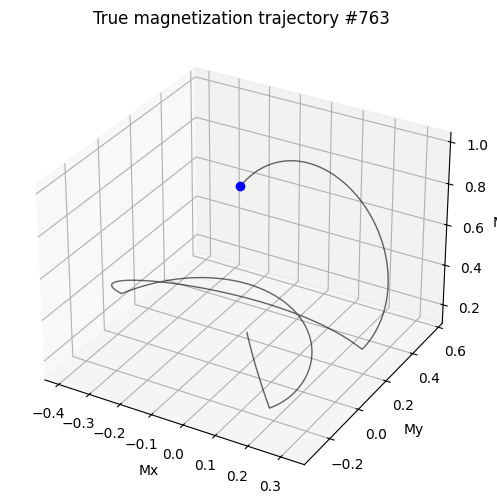

Animating trajectory 1629 (rank 6)


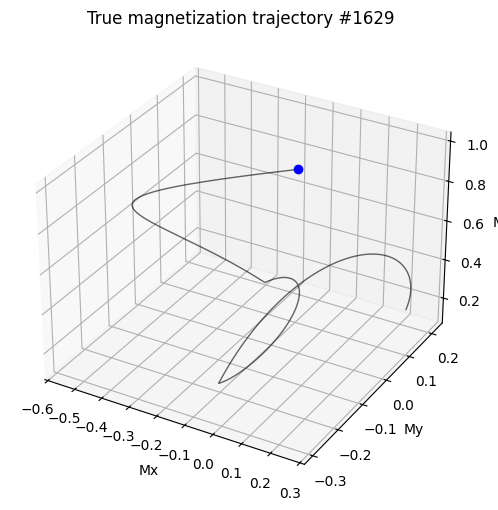

Animating trajectory 3379 (rank 7)


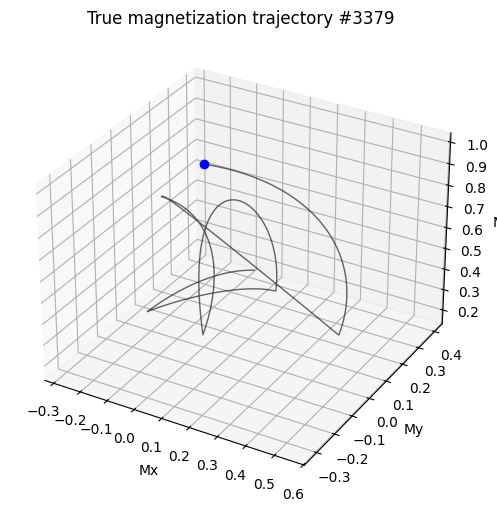

Animating trajectory 1905 (rank 8)


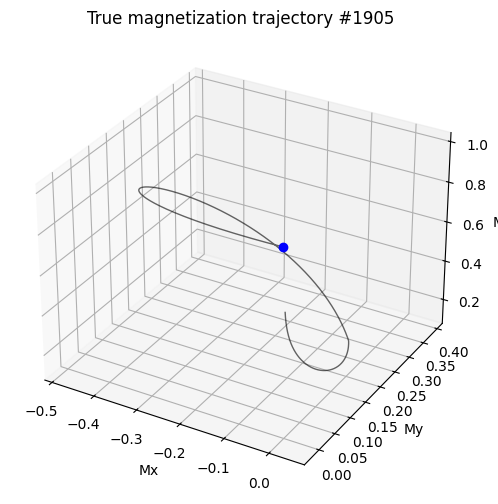

Animating trajectory 1310 (rank 9)


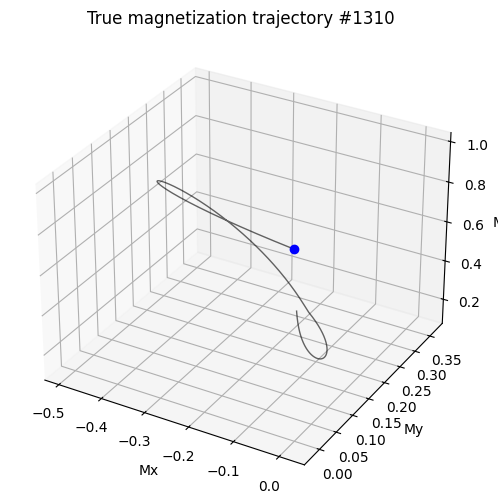

Animating trajectory 812 (rank 10)


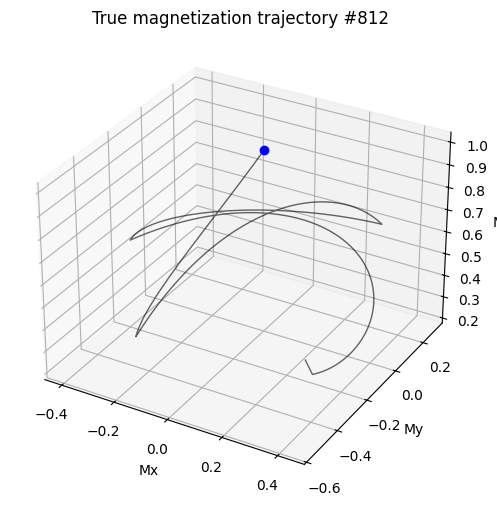

In [66]:
# Example: animate all top 10 one by one
for i, idx in enumerate(top10_idx):
    print(f"Animating trajectory {idx} (rank {i+1})")
    animate_npz_trajectory(y_all, t_np, traj_idx=idx)
    # or save to file:
    # animate_npz_trajectory(y_all, t_np, traj_idx=idx, save=f"traj_{idx}.mp4")


## Numerical Methods
Below is a comparison of the numerical methods with the analytical solutions. The solvers tested include Euler's (EM), Fourth-order Runge-Kutta (RK4), and Runge-Kutta-Fehlberg solvers (RKF).

In [ ]:
import numpy as np

def bloch_ode(t, M, gamma, T1, T2, M0, B):
    # M.shape = (N, 3) = (# spins, directions)
    
    # magnetizations in each direction
    Mx = M[:, 0]
    My = M[:, 1]
    Mz = M[:, 2]

    # precession term: ~y * (M x B)
    precession_term = gamma * np.cross(M, B) # thank you numpy

    # relaxation term: - [Mx / T2, My, / T2, (Mz - M0) / T1]
    relaxation_term = np.empty_like(M)
    relaxation_term[:, 0] = - Mx / T2
    relaxation_term[:, 1] = - My / T2
    relaxation_term[:, 2] = - (Mz - M0) / T1

    # return result
    return precession_term + relaxation_term

def euler_step(f, t, M, dt, *args):
    # 1 euler step
    # dt is time step
    return M + dt * f(t, M, *args)

def rk4_step(f, t, M, dt, *args):
    # 1 rk4 step
    # dt is time step
    k1 = f(t, M, *args)
    k2 = f(t + dt/2, M + dt*k1/2, *args)
    k3 = f(t + dt/2, M + dt*k2/2, *args)
    k4 = f(t + dt, M + dt*k3, *args)
    return M + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

def rkf_step(f, t, M, dt, *args):
    k1 = f(t, M, *args)
    k2 = f(t + dt/4, M + dt*k1/4, *args)
    k3 = f(t + 3*dt/8, (M + 3*dt*k1/32 + 9*dt*k2/32), *args)
    k4 = f(t + 12*dt/13, (M + 1932*dt*k1/2197 - 7200*dt*k2/2197 + 7296*dt*k3/2197), *args)
    k5 = f(t + dt, (M + 439*dt*k1/216 - 8*dt*k2 + 3680*dt*k3/513 - 845*dt*k4/4104), *args)
    k6 = f(t + dt/2, (M - 8*dt*k1/27 + 2*dt*k2 - 3544*dt*k3/2565 + 1859*dt*k4/4104 -11*dt*k5/40), *args)

    order_5 = M + dt*(16*k1/135 + 6656*k3/12825 + 28561*k4/56430 - 9*k5/50 + 2*k6/55)
    order_4 = M + dt*(25*k1/216 + 1408*k3/2565 + 2197*k4/4104 - 1*k5/5)
    err = np.abs(order_5-order_4) #error to calculate new time step

    return order_5, err

def simulate_bloch(method, M0_vec, t_max, dt, gamma, T1, T2, M0, B):
    t_points = np.arange(0, t_max + dt, dt)

    N = M0_vec.shape[0] # number of spins

    M = np.zeros((len(t_points), N, 3)) # solution magnetizations
    M[0] = M0_vec # set initial value 

    for i in range(len(t_points) - 1):
        t = t_points[i]
        M[i+1] = method(bloch_ode, t, M[i], dt, gamma, T1, T2, M0, B)
    return t_points, M

def bloch_rkf(method, M0_vec, t_max, dt, gamma, T1, T2, M0, B, err_tol= 1e-12):
    #Simulate Bloch equations using RKF
    t_cur = 0
    M_cur = M0_vec

    t_points = [t_cur]
    M_points = [M0_vec]

    while t_cur < t_max: 
        M_try, err = method(bloch_ode, t_cur, M_cur, dt, gamma, T1, T2, M0, B)
        err_cur = np.max(err)
        if err_cur <= err_tol:
            t_cur += dt
            M_cur = M_try
            t_points.append(t_cur)
            M_points.append(M_cur)
        else:
            dt = min(0.9*dt*(err_tol/err_cur + 1e-20)**0.2, t_max-t_cur) #calculate new step size 
    return np.array(t_points), np.array(M_points)

The below code compares the numerical methods to the analytical solution. The dt parameter can be set in gen_test_cases() to change the step size for Euler's and RK4, and the N parameter can be set in gen_test_cases() to change the number of spins considered. Note: the next cell can take a while to run. It works I promise.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import pandas as pd

def analytical_soln_simple(M_init, t, gamma, T1, T2, M0, B0, dB0):
    '''
    Analytic Bloch solution for simple case:
      - no RF or gradients (u = 0)
      - constant B0 along z
      - relaxation with T1, T2
      - precession around z: omega = gamma * (B0 + dB0)
    '''
    Mx0 = M_init[:, 0][None, : ] # (1, N)
    My0 = M_init[:, 1][None, : ]
    Mz0 = M_init[:, 2][None, : ]

    Mxy0 = np.sqrt(Mx0**2 + My0**2 + 1e-12)
    phi0 = np.arctan2(My0, Mx0)

    E1 = np.exp(-t[:, None] / (T1 + 1e-12)) # (N_time, 1)
    E2 = np.exp(-t[:, None] / (T2 + 1e-12))

    omega = -gamma * (B0 + dB0)
    phase = omega * t[:, None] + phi0

    # component solutions
    Mx = Mxy0 * E2 * np.cos(phase)
    My = Mxy0 * E2 * np.sin(phase)
    Mz = M0 + (Mz0 - M0) * E1

    M = np.stack([Mx, My, Mz], axis=-1) # (N_time, N, 3)
    return M

def gen_test_case(test_id = 0, include_rf=True, rf_type='sinc'):
    '''
    Generates test cases for analytical and numerical solution

    Parameters
    ----------
        test_id -> int: ID of test randomly generated test case

    '''

    np.random.seed(123 + test_id)
    N = 1

    # setting physical parameters
    M_init = np.random.randn(N, 3) # initial magnetization, shape (3,)
    M_init = M_init / (np.linalg.norm(M_init, axis=1, keepdims=True) + 1e-12) # normalize initial magnetization

    t_max = 10 # simulation time (seconds)
    dt = 0.01 # time step (seconds)
    gamma = 2 * np.pi * 42.58e6 # proton gyromagnetic ratio (rad/s/T)

    T1 = np.random.uniform(2, 5.0, size=N) # set T1 relaxation (seconds)
    T2 = np.random.uniform(0.6, 2.0, size=N) # set T2 relaxation (seconds)

    M0 = 1.0 # equilibrium magnetization

    B0  = np.random.uniform(1.5, 3.0) # B0 static magnetic field (T)
    dB0 = np.random.uniform(-0.1, 0.1, size=N) # B0 inhomogeneity for each spin (T)

    return (M_init, t_max, dt, gamma, T1, T2, M0, B0, dB0, N)

def compare(test_id=0):

    M_init, t_max, dt, gamma, T1, T2, M0, B0, dB0, N = gen_test_case(test_id)
    print(f'================TEST CASE {test_id}================')
    print(f'Parameters')
    print(f'Initial Magnetization: {M_init}')
    print(f'Simulation Time: {t_max} s')
    print(f'Time step: {dt} s')
    print(f'Gyromagnetic Ratio: {gamma} rad/s/T')
    print(f'T1 Relaxation: {T1} s')
    print(f'T2 Relaxation: {T2} s')
    print(f'Equilibrium Magnetization: {M0}')
    print(f'Static Field: {B0} T')
    print(f'B0 Inhomogeneity: {dB0} T')
    print(f'Number of Spins: {N}')
    print('____________________________________________________')

    B_field = np.zeros((N, 3))
    B_field[:, 2] = B0 + dB0

    print('Computing numerical solutions...')
    start = time.time()
    t_eu, M_eu = simulate_bloch(euler_step, M_init, t_max, dt, gamma, T1, T2, M0, B_field)
    end = time.time()
    runtime_eu = end-start

    start = time.time()
    t_rk, M_rk = simulate_bloch(rk4_step, M_init, t_max, dt, gamma, T1, T2, M0, B_field)
    end = time.time()
    runtime_rk4 = end-start

    start = time.time()
    t_rkf, M_rkf = bloch_rkf(rkf_step, M_init, t_max, dt, gamma, T1, T2, M0, B_field)
    end = time.time()
    runtime_rkf = end-start

    M_eu_net = np.sum(M_eu, axis=1) / N
    M_rk_net = np.sum(M_rk, axis=1) / N
    M_rkf_net = np.sum(M_rkf, axis=1) / N

    # print(M_eu.shape) #(10001, 3)
    # print(M_rk.shape) #(10001, 3)

    print(f"Euler: {len(t_eu)} points")
    print(f"RK4:   {len(t_rk)} points")
    print(f"RKF:   {len(t_rkf)} points (adaptive)")
   
    print('Computing analytical solutions...')
    
    start = time.time()
    M_analytical_eu = analytical_soln_simple(M_init, t_eu, gamma, T1, T2, M0, B0, dB0)
    end = time.time()
    runtime_eu_analytic = end-start
    
    start = time.time()
    M_analytical_rk4 = analytical_soln_simple(M_init, t_rk, gamma, T1, T2, M0, B0, dB0)
    M_analytical_rkf = analytical_soln_simple(M_init, t_rkf, gamma, T1, T2, M0, B0, dB0)
    end = time.time()
    runtime_rk4_analytic = end-start

    start = time.time()
    M_analytical_eu_net = np.sum(M_analytical_eu, axis=1) / N
    M_analytical_rk4_net = np.sum(M_analytical_rk4, axis=1) / N
    M_analytical_rkf_net = np.sum(M_analytical_rkf, axis=1) / N
    end = time.time()
    runtime_rkf_analytic = end-start

    res = {
        't_eu': t_eu, 'M_eu': M_eu_net,
        't_rk': t_rk, 'M_rk': M_rk_net,
        't_rkf': t_rkf, 'M_rkf': M_rkf_net,
        'M_analytic_eu': M_analytical_eu_net,
        'M_analytic_rk': M_analytical_rk4_net,
        'M_analytic_rkf': M_analytical_rkf_net,
        'runtime_eu': runtime_eu,
        'runtime_rk4': runtime_rk4,
        'runtime_rkf': runtime_rkf,
        'runtime_eu_analytic': runtime_eu_analytic,
        'runtime_rk4_analytic': runtime_rk4_analytic,
        'runtime_rkf_analytic': runtime_rkf_analytic
    }

    visual_solution(res)
    visual_error(res)

    return res

def visual_solution(res):
    # unpacking results
    t_eu = res['t_eu']
    M_eu = res['M_eu']
    t_rk = res['t_rk']
    M_rk = res['M_rk']
    t_rkf = res['t_rkf']
    M_rkf = res['M_rkf']
    M_analytical_eu = res['M_analytic_eu']
    M_analytical_rk4 = res['M_analytic_rk']
    M_analytical_rkf = res['M_analytic_rkf']

    # convert to milliseconds
    t_eu_ms = t_eu * 1e3
    t_rk_ms = t_rk * 1e3
    t_rkf_ms = t_rkf * 1e3

    methods = [
    ('Euler', t_eu_ms, M_eu, M_analytical_eu),
    ('RK4', t_rk_ms, M_rk,M_analytical_rk4), 
    ('RKF', t_rkf_ms, M_rkf,M_analytical_rkf)
    ]
    
    # figure 1: separate graphs with 3d trajectories 
    fig1, axes1 = plt.subplots(2, 3, figsize = (15,8))
    components = [('Mx', 'r-'), ('My', 'b-'), ('Mz', 'g-')]
    for col, (method_name, t_ms, M, M_analytical) in enumerate(methods):

        ax = axes1[0, col]

        # time graph
        for row, (comp_name, linestyle) in enumerate (components):  # Mx, My, Mz
    
            ax.plot(t_ms, M[:, row], linestyle, label=comp_name, alpha=0.8)
            ax.plot(t_ms, M_analytical[:, row], color='k', linestyle='--')
       
        ax.set_ylabel('Magnetization')
        ax.set_title(f'{method_name}')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        
        # 3d trajectory
        ax3d = axes1[1, col]
        ax3d.remove()
        ax3d = fig1.add_subplot(2, 3, col + 4, projection='3d')
        ax3d.plot(M[:, 0], M[:, 1], M[:, 2], color=linestyle[0], alpha=0.8)
        ax3d.plot(M_analytical[:, 0], M_analytical[:, 1], M_analytical[:, 2], color='k', alpha=0.8)

        ax3d.scatter(M[0, 0], M[0, 1], M[0, 2], 
                    color='k', s=50, label='Start')
        ax3d.scatter(M[-1, 0], M[-1, 1], M[-1, 2],
                    color='k', s=50, label='End')
        ax3d.set_xlabel('Mx')
        ax3d.set_ylabel('My')
        ax3d.set_zlabel('Mz')
        ax3d.set_title(f'{method_name} Trajectory')
        ax3d.legend()

    # figure 2: overlayed time graphs
    # plotting x, y, z vs time
    fig2, axes2 = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    labels = ['Mx', 'My', 'Mz']

    for i, ax in enumerate(axes2):
        ax.plot(t_eu * 1e3, M_eu[:, i], 'r', label=f'{labels[i]} (Euler)')
        ax.plot(t_rk * 1e3, M_rk[:, i], 'b', label=f'{labels[i]} (RK4)')
        ax.plot(t_rkf * 1e3, M_rkf[:, i], 'g', label=f'{labels[i]} (RKF)')
        ax.set_ylabel(f'{labels[i]}')
        ax.legend()
        ax.grid(True)
    axes2[-1].set_xlabel('Time (ms)')
    fig2.suptitle('Bloch Equation Components vs Time', fontsize=12)
    plt.tight_layout()
    plt.show()

def visual_error(res):
    # unpacking results
    t_eu = res['t_eu'] * 1e3
    t_rk = res['t_rk'] * 1e3
    t_rkf = res['t_rkf'] * 1e3
    M_eu = res['M_eu']
    M_rk = res['M_rk']
    M_rkf = res['M_rkf']
    M_analytical_eu = res['M_analytic_eu']
    M_analytical_rk4 = res['M_analytic_rk']
    M_analytical_rkf = res['M_analytic_rkf']
    runtime_eu = res['runtime_eu']
    runtime_rk4 = res['runtime_rk4']
    runtime_rkf = res['runtime_rkf']
    runtime_eu_analytic = res['runtime_eu_analytic']
    runtime_rk4_analytic = res['runtime_rk4_analytic']
    runtime_rkf_analytic = res['runtime_rkf_analytic']

    # error array
    err_eu = M_eu - M_analytical_eu
    err_rk = M_rk - M_analytical_rk4
    err_rkf = M_rkf - M_analytical_rkf

    # global errors
    mse_global_eu = np.mean((err_eu)**2)
    mse_global_rk = np.mean((err_rk)**2)
    mse_global_rkf = np.mean((err_rkf)**2)
    
    # component errors
    mse_comp_eu = np.mean((err_eu)**2, axis=0)
    mse_comp_rk = np.mean((err_rk)**2, axis=0)
    mse_comp_rkf = np.mean((err_rkf)**2, axis=0)

    methods = [
        ('Euler', mse_global_eu, mse_comp_eu),
        ('RK4', mse_global_rk, mse_comp_rk),
        ('RKF', mse_global_rkf, mse_comp_rkf)
    ]

    components = ['Mx', 'My', 'Mz']

    # for method_name, global_mse, comp_mse in methods:
    #     print(f"==={method_name} VS Analytic Bloch (simple case)===")
    #     print(f"Global MSE: {global_mse:.6e}")
    #     for i, comp in enumerate(components):
    #         print(f"{comp} MSE: {comp_mse[i]:.6e}")

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
  
    for component, ax in enumerate (axes):  # Mx, My, Mz
    
        ax.plot(t_eu, err_eu[:, component], 'r-', label='Euler', alpha=0.8)
        ax.plot(t_rk, err_rk[:, component], 'b-', label='RK4', alpha=0.8)
        ax.plot(t_rkf, err_rkf[:, component], 'g-', label='RKF', alpha=0.8)   

        ax.set_ylabel('Error')
        ax.set_title(f'Error over time for {components[component]}')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.show()

    rows = [
        {
            'Method': 'Euler',
            'Avg_MSE': mse_global_eu,
            'Mx_MSE': mse_comp_eu[0],
            'My_MSE': mse_comp_eu[1],
            'Mz_MSE': mse_comp_eu[2],
            'Runtime_s': runtime_eu,
            'Time_Points': len(t_eu)
        },
        {
            'Method': 'RK4',
            'Avg_MSE': mse_global_rk,
            'Mx_MSE': mse_comp_rk[0],
            'My_MSE': mse_comp_rk[1],
            'Mz_MSE': mse_comp_rk[2],
            'Runtime_s': runtime_rk4,
            'Time_Points': len(t_rk)
        },
        {
            'Method': 'RKF',
            'Avg_MSE': mse_global_rkf,
            'Mx_MSE': mse_comp_rkf[0],
            'My_MSE': mse_comp_rkf[1],
            'Mz_MSE': mse_comp_rkf[2],
            'Runtime_s': runtime_rkf,
            'Time_Points': len(t_rkf)
        }
    ]
    
    df = pd.DataFrame(rows)
    display(df)


compare0 = compare()

## Final Evaluation Code

In [44]:
# ============================================================
# Evaluation Cell: Compare Neural ODE models vs Numerical Solvers
# - Evaluates on BOTH datasets: full voxel + single spin
# - Metrics: MSE (loss), RMSE, MAE, final-time error, norm error
# - Runtime: ms/trajectory and trajectories/sec (with CUDA sync)
# ============================================================

import time
import math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ----------------------------
# Helpers: timing + metrics
# ----------------------------
def _sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize()

def _metrics(yhat: torch.Tensor, y: torch.Tensor):
    """
    yhat, y: (B,T,3)
    returns dict of scalar metrics (float)
    """
    err = yhat - y
    mse = torch.mean(err**2)
    rmse = torch.sqrt(mse)
    mae = torch.mean(torch.abs(err))

    # component-wise MSE (Mx, My, Mz)
    comp_mse = torch.mean(err**2, dim=(0,1))  # (3,)

    # final-time errors (t = last)
    err_T = yhat[:, -1, :] - y[:, -1, :]
    final_rmse = torch.sqrt(torch.mean(err_T**2))
    final_mae  = torch.mean(torch.abs(err_T))

    # magnetization norm error
    yhat_norm = torch.linalg.norm(yhat, dim=-1)   # (B,T)
    y_norm    = torch.linalg.norm(y, dim=-1)      # (B,T)
    norm_rmse = torch.sqrt(torch.mean((yhat_norm - y_norm)**2))

    return {
        "mse": float(mse.detach().cpu()),
        "rmse": float(rmse.detach().cpu()),
        "mae": float(mae.detach().cpu()),
        "mse_Mx": float(comp_mse[0].detach().cpu()),
        "mse_My": float(comp_mse[1].detach().cpu()),
        "mse_Mz": float(comp_mse[2].detach().cpu()),
        "final_rmse": float(final_rmse.detach().cpu()),
        "final_mae": float(final_mae.detach().cpu()),
        "norm_rmse": float(norm_rmse.detach().cpu()),
    }

# -------------------------------------------------------
# Torch batched numerical solvers for Bloch RHS (time-varying)
# Requires your existing bloch_rhs_analytic(M, u, p) from notebook.
# -------------------------------------------------------
@torch.no_grad()
def integrate_euler_torch(y0, t, u, p):
    """
    Batched Euler integration.
    y0: (B,3)
    t:  (T,)
    u:  (B,T,4) or (B,T,2/3) depending on dataset; bloch_rhs_analytic uses u[...,0:2] for B1x,B1y
    p:  (B,5)
    returns yhat: (B,T,3)
    """
    B, _ = y0.shape
    T = t.shape[0]
    yhat = torch.zeros((B, T, 3), device=y0.device, dtype=y0.dtype)
    yhat[:, 0, :] = y0

    for k in range(T - 1):
        dt = (t[k+1] - t[k])
        rhs = bloch_rhs_analytic(yhat[:, k, :], u[:, k, :], p)  # (B,3)
        yhat[:, k+1, :] = yhat[:, k, :] + dt * rhs
    return yhat

@torch.no_grad()
def integrate_rk4_torch(y0, t, u, p):
    """
    Batched RK4 integration (fixed step on provided time grid).
    """
    B, _ = y0.shape
    T = t.shape[0]
    yhat = torch.zeros((B, T, 3), device=y0.device, dtype=y0.dtype)
    yhat[:, 0, :] = y0

    for k in range(T - 1):
        dt = (t[k+1] - t[k])

        M  = yhat[:, k, :]
        uk = u[:, k, :]
        # For intermediate stages, keep u frozen at uk (common choice on fixed grid)
        k1 = bloch_rhs_analytic(M,                 uk, p)
        k2 = bloch_rhs_analytic(M + 0.5*dt*k1,     uk, p)
        k3 = bloch_rhs_analytic(M + 0.5*dt*k2,     uk, p)
        k4 = bloch_rhs_analytic(M + dt*k3,         uk, p)

        yhat[:, k+1, :] = M + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return yhat

# ----------------------------
# Evaluation loops
# ----------------------------
@torch.no_grad()
def eval_method_on_loader(method_name, predict_fn, loader, t_shared, device, criterion=None):
    """
    predict_fn(batch)-> yhat (B,T,3)
    """
    if criterion is None:
        criterion = nn.MSELoss(reduction="mean")

    totals = {
        "n_traj": 0,
        "loss_sum": 0.0,
        "time_s": 0.0,
        # metric accumulators (weighted by trajectories)
        "mse": 0.0, "rmse": 0.0, "mae": 0.0,
        "mse_Mx": 0.0, "mse_My": 0.0, "mse_Mz": 0.0,
        "final_rmse": 0.0, "final_mae": 0.0, "norm_rmse": 0.0,
    }

    for batch in loader:
        y  = batch["y"].to(device)    # (B,T,3)
        y0 = batch["y0"].to(device)   # (B,3)
        u  = batch["u"].to(device)    # (B,T,4) (or similar)
        p  = batch["p"].to(device)    # (B,5)

        B = y.shape[0]

        _sync(device)
        t0 = time.perf_counter()

        yhat = predict_fn(y=y, y0=y0, u=u, p=p, t=t_shared)

        _sync(device)
        dt = time.perf_counter() - t0

        loss = criterion(yhat, y)

        m = _metrics(yhat, y)

        totals["n_traj"] += B
        totals["loss_sum"] += float(loss.detach().cpu()) * B
        totals["time_s"] += dt

        for k in m:
            totals[k] += m[k] * B

    n = max(1, totals["n_traj"])
    avg_loss = totals["loss_sum"] / n
    avg_time = totals["time_s"]
    ms_per_traj = 1000.0 * avg_time / n
    traj_per_s = n / max(1e-12, avg_time)

    out = {
        "method": method_name,
        "n_traj": n,
        "loss_mse": avg_loss,
        "runtime_s_total": avg_time,
        "ms_per_traj": ms_per_traj,
        "traj_per_s": traj_per_s,
    }
    for k in ["mse","rmse","mae","mse_Mx","mse_My","mse_Mz","final_rmse","final_mae","norm_rmse"]:
        out[k] = totals[k] / n
    return out

def make_loader_from_dir(data_dir: Path, split="val", batch_size=256, num_workers=0):
    """
    Uses BlochNPZ class already defined in your notebook.
    Looks for {split}.npz; if missing, falls back to val.npz.
    """
    data_dir = Path(data_dir)
    npz_path = data_dir / f"{split}.npz"
    if not npz_path.exists():
        print(f"[warn] {npz_path} not found; falling back to val.npz")
        npz_path = data_dir / "test.npz"
    ds = BlochNPZ(str(npz_path))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)
    return ds, loader

# -------------------------------------------------------
# Define datasets (as in your notebook)
# -------------------------------------------------------
ROOT = Path(".")
DATASETS = {
    "full_voxel": ROOT / "data" / "npz",
    "single_spin": ROOT / "data" / "npz_single_spin",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CRITERION = nn.MSELoss(reduction="mean")

# -------------------------------------------------------
# Define models to load (EDIT THESE to match what you trained)
# IMPORTANT: the constructors must match the saved checkpoint shapes.
# -------------------------------------------------------
def load_ckpt_into(model, ckpt_path: Path, device):
    ckpt = torch.load(str(ckpt_path), map_location=device)
    # common patterns: either ckpt is a dict with "model", or raw state_dict
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.eval()
    return model

MODEL_SPECS = {
    # Example: voxel UDE (already in your notebook)
    "NeuralBlochVoxelUDE": {
        "ctor": lambda: NeuralBlochVoxelUDE(
            hidden_dim=128,
            num_layers=3,
            use_residual=True,
            residual_scale=0.3,
            n_substeps=1,
            use_time_input=True,
        ).to(DEVICE),
        "ckpt_full_voxel": ROOT / "NEURAL_ODE_VOXELUDE" / "best_neural_ode.pt",
        "ckpt_single_spin": ROOT / "NEURAL_ODE_VOXEL_UDE_SINGLE_SPIN" / "best_neural_ode.pt",
    },
    "NeuralBlochODE": {
        "ctor": lambda: NeuralBlochODE(
            hidden_dim=256,
            n_hidden_layers=3,
        ).to(DEVICE),

        # EXACT checkpoint you trained with
        "ckpt_full_voxel": ROOT / "NEURAL_ODE_1" / "best_neural_ode.pt",
        "ckpt_single_spin": ROOT / "NEURAL_ODE_1" / "best_neural_ode.pt",
    },
}

# -------------------------------------------------------
# Build predictor fns (Neural ODE + Numerical Methods)
# -------------------------------------------------------
def make_model_predict_fn(model):
    @torch.no_grad()
    def _predict_fn(y, y0, u, p, t):
        # expected API in your notebook: model(y0, t, u, p) -> (B,T,3)
        return model(y0, t, u, p)
    return _predict_fn

NUM_METHODS = {
    "Euler(bloch_rhs_analytic)": lambda y, y0, u, p, t: integrate_euler_torch(y0, t, u, p),
    "RK4(bloch_rhs_analytic)":   lambda y, y0, u, p, t: integrate_rk4_torch(y0, t, u, p),
}


# -------------------------------------------------------
# Run evaluation on BOTH datasets
# -------------------------------------------------------
rows = []

for ds_name, ds_dir in DATASETS.items():
    ds_obj, loader = make_loader_from_dir(ds_dir, split="val", batch_size=256, num_workers=0)

    # shared time grid from dataset
    t_shared = ds_obj.t[0].to(DEVICE)  # (T,)

    # --- Numerical baselines ---
    for mname, mpredict in NUM_METHODS.items():
        res = eval_method_on_loader(
            method_name=f"{mname}",
            predict_fn=mpredict,
            loader=loader,
            t_shared=t_shared,
            device=DEVICE,
            criterion=CRITERION,
        )
        res["dataset"] = ds_name
        rows.append(res)

    # --- Neural ODE models ---
    for model_name, spec in MODEL_SPECS.items():
        ckpt_key = "ckpt_full_voxel" if ds_name == "full_voxel" else "ckpt_single_spin"
        ckpt_path = Path(spec[ckpt_key])

        if not ckpt_path.exists():
            print(f"[warn] missing checkpoint for {model_name} on {ds_name}: {ckpt_path} (skipping)")
            continue

        model = spec["ctor"]()
        model = load_ckpt_into(model, ckpt_path, DEVICE)

        res = eval_method_on_loader(
            method_name=f"{model_name}",
            predict_fn=make_model_predict_fn(model),
            loader=loader,
            t_shared=t_shared,
            device=DEVICE,
            criterion=CRITERION,
        )
        res["dataset"] = ds_name
        rows.append(res)

df = pd.DataFrame(rows)

# Sort nicely: by dataset then by loss
df = df.sort_values(["dataset", "loss_mse", "ms_per_traj"]).reset_index(drop=True)

display(df)

# Optional: print winners per dataset
for ds_name in df["dataset"].unique():
    sub = df[df["dataset"] == ds_name]
    best_loss = sub.iloc[0]
    best_speed = sub.sort_values("ms_per_traj").iloc[0]
    print(f"\n=== {ds_name} ===")
    print(f"Best accuracy (lowest loss_mse): {best_loss['method']}  loss={best_loss['loss_mse']:.3e}  ms/traj={best_loss['ms_per_traj']:.2f}")
    print(f"Fastest (lowest ms_per_traj):   {best_speed['method']}  loss={best_speed['loss_mse']:.3e}  ms/traj={best_speed['ms_per_traj']:.2f}")


d:\MAT292_ODE_Project\.venv_Bloch\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,method,n_traj,loss_mse,runtime_s_total,ms_per_traj,traj_per_s,mse,rmse,mae,mse_Mx,mse_My,mse_Mz,final_rmse,final_mae,norm_rmse,dataset
0,NeuralBlochVoxelUDE,500,0.005996,20.492823,40.985645,24.398786,0.005996,0.077425,0.036733,0.006616,0.006600,0.004770,0.049267,0.020372,0.063283,full_voxel
1,NeuralBlochODE,500,0.009477,6.299625,12.599249,79.369809,0.009477,0.097350,0.060270,0.010000,0.009310,0.009122,0.109108,0.070805,0.080515,full_voxel
2,RK4(bloch_rhs_analytic),500,0.010746,1.154335,2.308671,433.149672,0.010746,0.103663,0.034812,0.009534,0.010531,0.012174,0.072045,0.022235,0.096455,full_voxel
3,Euler(bloch_rhs_analytic),500,0.010767,0.462232,0.924465,1081.707185,0.010767,0.103762,0.034856,0.009549,0.010548,0.012203,0.072056,0.022236,0.096569,full_voxel
4,NeuralBlochVoxelUDE,500,0.005875,7.513679,15.027358,66.545298,0.005875,0.076650,0.038215,0.006265,0.006232,0.005129,0.052054,0.022947,0.065503,single_spin
5,NeuralBlochODE,500,0.009269,6.602223,13.204445,75.732074,0.009269,0.096276,0.060342,0.009439,0.009293,0.009076,0.106033,0.069918,0.081238,single_spin
6,RK4(bloch_rhs_analytic),500,0.010613,1.152477,2.304953,433.848288,0.010613,0.102982,0.036298,0.009371,0.009412,0.013057,0.070675,0.022347,0.100902,single_spin
7,Euler(bloch_rhs_analytic),500,0.010634,0.475192,0.950383,1052.206931,0.010634,0.103080,0.036342,0.009386,0.009426,0.013089,0.070690,0.022352,0.101018,single_spin



=== full_voxel ===
Best accuracy (lowest loss_mse): NeuralBlochVoxelUDE  loss=5.996e-03  ms/traj=40.99
Fastest (lowest ms_per_traj):   Euler(bloch_rhs_analytic)  loss=1.077e-02  ms/traj=0.92

=== single_spin ===
Best accuracy (lowest loss_mse): NeuralBlochVoxelUDE  loss=5.875e-03  ms/traj=15.03
Fastest (lowest ms_per_traj):   Euler(bloch_rhs_analytic)  loss=1.063e-02  ms/traj=0.95


The table above compares the loss and time metrics of the numerical methods and 2 neural ode models on the fabricated test dataset. 

In [ ]:

# ============================================================
# Synthetic analytic-case benchmark (constant control u(t))
# Ground truth = true closed-form analytic solution
# Compares: NUM_METHODS + all models in MODEL_SPECS
# ============================================================

import time
import pandas as pd
import torch
import torch.nn as nn

# --------- use your existing helpers: _sync, _metrics, load_ckpt_into, make_model_predict_fn ----------
# (assumes they are already defined in your notebook)

# ----------------------------
# Analytic ground truth for constant u(t): M(t) = exp(A t) M0 + (exp(A t)-I) A^{-1} b
# We compute it robustly using augmented expm to avoid A^{-1}.
# ----------------------------
def _bloch_A_b_simple(u_bt: torch.Tensor, p_b5: torch.Tensor, M_eq: float = 1.0):
    """
    Simple constant-field Bloch linear system: dM/dt = A M + b
    u_bt: (B,4) [B1x,B1y,Gx,Gy] (we use B1x,B1y; Gx,Gy ignored here)
    p_b5: (B,5) [T1,T2,dB0,B0,gamma]
    """
    T1    = p_b5[:, 0]
    T2    = p_b5[:, 1]
    dB0   = p_b5[:, 2]
    B0    = p_b5[:, 3]
    gamma = p_b5[:, 4]

    B1x = u_bt[:, 0]
    B1y = u_bt[:, 1]

    Bx = B1x
    By = B1y
    Bz = B0 + dB0

    wx = gamma * Bx
    wy = gamma * By
    wz = gamma * Bz

    B = u_bt.shape[0]
    device, dtype = u_bt.device, u_bt.dtype

    invT2 = 1.0 / T2
    invT1 = 1.0 / T1

    A = torch.zeros((B, 3, 3), device=device, dtype=dtype)
    A[:, 0, 0] = -invT2
    A[:, 0, 1] =  wz
    A[:, 0, 2] = -wy
    A[:, 1, 0] = -wz
    A[:, 1, 1] = -invT2
    A[:, 1, 2] =  wx
    A[:, 2, 0] =  wy
    A[:, 2, 1] = -wx
    A[:, 2, 2] = -invT1

    b = torch.zeros((B, 3, 1), device=device, dtype=dtype)
    b[:, 2, 0] = M_eq * invT1
    return A, b


def _phi_aug(A: torch.Tensor, b: torch.Tensor, h: torch.Tensor):
    """
    Augmented matrix exp to get:
      exp(Ah) and integral_0^h exp(As) b ds
    without A^{-1}.
    """
    if not torch.is_tensor(h):
        h = torch.tensor(h, device=A.device, dtype=A.dtype)
    h = h.to(dtype=A.dtype, device=A.device)

    B = A.shape[0]
    device, dtype = A.device, A.dtype
    Z = torch.zeros((B, 4, 4), device=device, dtype=dtype)
    Z[:, :3, :3] = A
    Z[:, :3, 3:4] = b

    expZ = torch.matrix_exp(Z * h)
    E = expZ[:, :3, :3]      # exp(Ah)
    g = expZ[:, :3, 3:4]     # integral term
    return E, g


@torch.no_grad()
def analytic_ground_truth_constant_u(y0, t, u_const, p, M_eq: float = 1.0):
    """
    True closed-form for constant u (global analytic solution).
    y0: (B,3), t:(T,), u_const:(B,4), p:(B,5)
    returns y:(B,T,3)
    """
    B = y0.shape[0]
    T = t.shape[0]
    device, dtype = y0.device, y0.dtype

    A, b = _bloch_A_b_simple(u_const, p, M_eq=M_eq)

    y = torch.zeros((B, T, 3), device=device, dtype=dtype)
    y[:, 0, :] = y0

    for k in range(1, T):
        tk = t[k]
        E, g = _phi_aug(A, b, tk)
        Mk = (E @ y0.unsqueeze(-1) + g).squeeze(-1)
        y[:, k, :] = Mk
    return y


# ----------------------------
# Random analytic-case generator
# ----------------------------
@torch.no_grad()
def sample_random_analytic_cases(
    n_traj: int,
    t: torch.Tensor,
    device,
    dtype=torch.float32,
    ranges=None,
):
    """
    Generates constant-control cases (u is constant over time), with random params p and y0.
    Returns batch dict with keys: y, y0, u, p
    """
    if ranges is None:
        ranges = {
            "T1":  (0.3, 1.0),
            "T2":  (0.02, 0.2),
            "dB0": (-0.25, 0.25),
            "B0":  (1.5, 3.0),
            "gamma": (1.0, 1.0),  
            "B1x": (-6.0, 6.0),
            "B1y": (-6.0, 6.0),
        }

    def rand_uniform(lo, hi, shape):
        return (lo + (hi - lo) * torch.rand(shape, device=device, dtype=dtype))

    B = n_traj
    T = t.shape[0]

    # parameters
    T1 = rand_uniform(*ranges["T1"], (B,))
    T2 = rand_uniform(*ranges["T2"], (B,))
    dB0 = rand_uniform(*ranges["dB0"], (B,))
    B0 = rand_uniform(*ranges["B0"], (B,))
    gamma = rand_uniform(*ranges["gamma"], (B,))
    p = torch.stack([T1, T2, dB0, B0, gamma], dim=-1)  # (B,5)

    # constant controls (Gx,Gy set to 0 for analytic single-spin)
    B1x = rand_uniform(*ranges["B1x"], (B,))
    B1y = rand_uniform(*ranges["B1y"], (B,))
    Gx = torch.zeros((B,), device=device, dtype=dtype)
    Gy = torch.zeros((B,), device=device, dtype=dtype)
    u_const = torch.stack([B1x, B1y, Gx, Gy], dim=-1)  # (B,4)

    # expand over time
    u = u_const[:, None, :].expand(B, T, 4).contiguous()  # (B,T,4)

    # random initial magnetization, keep norm <= 1
    y0 = rand_uniform(-1.0, 1.0, (B, 3))
    y0 = y0 / torch.clamp(torch.linalg.norm(y0, dim=-1, keepdim=True), min=1e-8)
    y0 = 0.9 * y0  # keep inside unit ball

    # ground truth analytic
    y = analytic_ground_truth_constant_u(y0, t, u_const, p, M_eq=1.0)

    return {"y": y, "y0": y0, "u": u, "p": p}


# ----------------------------
# Evaluate a method on synthetic batch (chunked)
# ----------------------------
@torch.no_grad()
def eval_method_on_analytic_cases(method_name, predict_fn, t_shared, device, n_traj=2000, batch_size=256):
    criterion = nn.MSELoss(reduction="mean")
    totals = {"n": 0, "loss_sum": 0.0, "time_s": 0.0,
              "mse": 0.0, "rmse": 0.0, "mae": 0.0,
              "mse_Mx": 0.0, "mse_My": 0.0, "mse_Mz": 0.0,
              "final_rmse": 0.0, "final_mae": 0.0, "norm_rmse": 0.0}

    for i in range(0, n_traj, batch_size):
        B = min(batch_size, n_traj - i)
        batch = sample_random_analytic_cases(B, t_shared, device=device, dtype=t_shared.dtype)

        y  = batch["y"]
        y0 = batch["y0"]
        u  = batch["u"]
        p  = batch["p"]

        _sync(device)
        t0 = time.perf_counter()
        yhat = predict_fn(y=y, y0=y0, u=u, p=p, t=t_shared)
        _sync(device)
        dt = time.perf_counter() - t0

        loss = criterion(yhat, y)
        m = _metrics(yhat, y)

        totals["n"] += B
        totals["loss_sum"] += float(loss.detach().cpu()) * B
        totals["time_s"] += dt
        for k in m:
            totals[k] += m[k] * B

    n = totals["n"]
    out = {
        "method": method_name,
        "n_traj": n,
        "loss_mse": totals["loss_sum"] / n,
        "runtime_s_total": totals["time_s"],
        "ms_per_traj": 1000.0 * totals["time_s"] / n,
        "traj_per_s": n / max(1e-12, totals["time_s"]),
    }
    for k in ["mse","rmse","mae","mse_Mx","mse_My","mse_Mz","final_rmse","final_mae","norm_rmse"]:
        out[k] = totals[k] / n
    return out


# ============================================================
# RUN: compare everything to analytic ground truth
# ============================================================
rows = []
t_shared = torch.linspace(0.0, 1.0, 1001, device=DEVICE)  # choose horizon/resolution you want

# --- numerical methods already defined ---
for mname, mpredict in NUM_METHODS.items():
    rows.append(eval_method_on_analytic_cases(
        method_name=f"{mname}",
        predict_fn=mpredict,
        t_shared=t_shared,
        device=DEVICE,
        n_traj=2000,
        batch_size=256,
    ))

# --- neural models (load them and evaluate) ---
for model_name, spec in MODEL_SPECS.items():
    ckpt_path = Path(spec.get("ckpt_single_spin", ""))  # use single-spin ckpt for analytic cases
    if not ckpt_path.exists():
        print(f"[warn] missing checkpoint for {model_name}: {ckpt_path} (skipping)")
        continue
    model = spec["ctor"]()
    model = load_ckpt_into(model, ckpt_path, DEVICE)
    rows.append(eval_method_on_analytic_cases(
        method_name=f"{model_name}",
        predict_fn=make_model_predict_fn(model),
        t_shared=t_shared,
        device=DEVICE,
        n_traj=2000,
        batch_size=256,
    ))

df_analytic = pd.DataFrame(rows).sort_values(["loss_mse", "ms_per_traj"]).reset_index(drop=True)
display(df_analytic)



,method,n_traj,loss_mse,runtime_s_total,ms_per_traj,traj_per_s,mse,rmse,mae,mse_Mx,mse_My,mse_Mz,final_rmse,final_mae,norm_rmse
0,RK4(bloch_rhs_analytic),2000,1.648209e-14,17.599121,8.799560,113.642040,1.648209e-14,1.283225e-07,7.714601e-08,4.766020e-15,4.609168e-15,4.007109e-14,1.543723e-07,8.667081e-08,2.047533e-07
1,Euler(bloch_rhs_analytic),2000,3.586702e-07,5.142969,2.571484,388.880461,3.586702e-07,5.988097e-04,3.766223e-04,3.722874e-07,3.818424e-07,3.218806e-07,1.475516e-04,9.549702e-05,6.615920e-04
2,NeuralBlochVoxelUDE,2000,1.857225e-02,43.724580,21.862290,45.740863,1.857225e-02,1.362050e-01,1.020325e-01,1.030715e-02,1.048916e-02,3.492045e-02,1.476147e-01,1.138166e-01,1.538377e-01
3,NeuralBlochODE,2000,3.433524e-01,21.368240,10.684120,93.596854,3.433524e-01,5.859150e-01,4.789630e-01,2.530433e-01,2.537116e-01,5.233022e-01,7.159895e-01,5.956368e-01,5.264433e-01


The table above demonstrates the loss and runtime metrics of 2 Neural ODEs and the RK4 and Euler numerical methods with respect to the analytic bloch equation

In [ ]:
# ============================================================
# BlochSimulator benchmark WITH per-rf_type breakdown
# ============================================================

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CRITERION = nn.MSELoss(reduction="mean")

# ----------------------------
# 1) Online dataset (now returns rf_type)
# ----------------------------
class OnlineSimDataset(Dataset):
    def __init__(self, n_samples, T_coarse, dt_coarse, refine, seed=2025):
        self.n = int(n_samples)
        self.T = int(T_coarse)
        self.dt = float(dt_coarse)
        self.refine = int(refine)
        self.seed = int(seed)

    def __len__(self): return self.n

    def __getitem__(self, i):
        rng = np.random.default_rng(self.seed + int(i))
        s = simulate_one_truth_and_coarse(self.T, self.dt, self.refine, rng)
        return {
            "t":  torch.from_numpy(s["t"]),      # (T,)
            "y":  torch.from_numpy(s["y"]),      # (T,3)
            "y0": torch.from_numpy(s["y0"]),     # (3,)
            "u":  torch.from_numpy(s["u"]),      # (T,4)
            "p":  torch.from_numpy(s["p"]),      # (5,)
            "rf_type": s["rf_type"],             # str
        }

def collate_online(batch):
    t = batch[0]["t"]  # shared by construction
    y  = torch.stack([b["y"] for b in batch], 0)   # (B,T,3)
    y0 = torch.stack([b["y0"] for b in batch], 0)  # (B,3)
    u  = torch.stack([b["u"] for b in batch], 0)   # (B,T,4)
    p  = torch.stack([b["p"] for b in batch], 0)   # (B,5)
    rf = [b["rf_type"] for b in batch]             # list[str], len=B
    return {"t": t, "y": y, "y0": y0, "u": u, "p": p, "rf_type": rf}

# ----------------------------
# 2) Eval loop with per-group aggregation
# ----------------------------
@torch.no_grad()
def eval_on_loader_grouped(method_name, predict_fn, loader, t_shared, device, criterion=None):
    if criterion is None:
        criterion = nn.MSELoss()

    # overall accumulators
    overall = {"n": 0, "loss_sum": 0.0, "time_s": 0.0, "metrics": None}

    # group accumulators: rf_type -> dict
    groups = {}  # rf -> {"n":..., "loss_sum":..., "time_s":..., "metrics":...}

    for batch in loader:
        y  = batch["y"].to(device)
        y0 = batch["y0"].to(device)
        u  = batch["u"].to(device)
        p  = batch["p"].to(device)
        rf_list = batch["rf_type"]  # list[str]
        B = y.shape[0]

        _sync(device)
        t0 = time.perf_counter()
        yhat = predict_fn(y=y, y0=y0, u=u, p=p, t=t_shared)
        _sync(device)
        elapsed = time.perf_counter() - t0

        loss = criterion(yhat, y)
        m = _metrics(yhat, y)

        # --- overall ---
        overall["n"] += B
        overall["loss_sum"] += float(loss.detach().cpu()) * B
        overall["time_s"] += elapsed
        if overall["metrics"] is None:
            overall["metrics"] = {k: 0.0 for k in m}
        for k in m:
            overall["metrics"][k] += m[k] * B

        # --- per rf_type ---
        # collect indices per rf type within this batch
        rf_to_idx = {}
        for i, rf in enumerate(rf_list):
            rf_to_idx.setdefault(rf, []).append(i)

        for rf, idxs in rf_to_idx.items():
            idxs = torch.tensor(idxs, device=device)
            y_rf = y.index_select(0, idxs)
            yhat_rf = yhat.index_select(0, idxs)
            B_rf = y_rf.shape[0]

            loss_rf = criterion(yhat_rf, y_rf)
            m_rf = _metrics(yhat_rf, y_rf)

            if rf not in groups:
                groups[rf] = {"n": 0, "loss_sum": 0.0, "time_s": 0.0, "metrics": {k: 0.0 for k in m_rf}}
            groups[rf]["n"] += B_rf
            groups[rf]["loss_sum"] += float(loss_rf.detach().cpu()) * B_rf

            # time attribution: proportional share of batch time
            groups[rf]["time_s"] += elapsed * (B_rf / max(1, B))

            for k in m_rf:
                groups[rf]["metrics"][k] += m_rf[k] * B_rf

    # build rows
    rows = []

    def finalize(name, rf, pack):
        n = max(1, pack["n"])
        out = {
            "method": name,
            "rf_type": rf,
            "n_traj": pack["n"],
            "loss_mse": pack["loss_sum"] / n,
            "runtime_s_total": pack["time_s"],
            "ms_per_traj": 1000.0 * pack["time_s"] / n,
            "traj_per_s": pack["n"] / max(1e-12, pack["time_s"]),
        }
        for k, v in pack["metrics"].items():
            out[k] = v / n
        return out

    # overall row
    rows.append(finalize(method_name, "ALL", overall))

    # per rf rows
    for rf, pack in sorted(groups.items(), key=lambda kv: kv[0]):
        rows.append(finalize(method_name, rf, pack))

    return rows

# ----------------------------
# 3) Run benchmark and return one big dataframe
# ----------------------------
def run_blochsim_benchmark_by_rf(
    n_samples=300,
    batch_size=64,
    T_coarse=600,
    dt_coarse=2e-3,
    refine=20,
    euler_substeps=20,
    rk4_substeps=10,
):
    ds = OnlineSimDataset(n_samples, T_coarse, dt_coarse, refine, seed=2025)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_online)

    t_shared = next(iter(loader))["t"].to(DEVICE)

    all_rows = []

    # numerics
    all_rows += eval_on_loader_grouped(
        f"Euler-sub{euler_substeps}",
        lambda y, y0, u, p, t: integrate_euler_substeps(y0, t, u, p, n_substeps=euler_substeps),
        loader, t_shared, DEVICE, CRITERION
    )
    all_rows += eval_on_loader_grouped(
        f"RK4-sub{rk4_substeps}",
        lambda y, y0, u, p, t: integrate_rk4_substeps(y0, t, u, p, n_substeps=rk4_substeps),
        loader, t_shared, DEVICE, CRITERION
    )

    # models
    for model_name, spec in MODEL_SPECS.items():
        ckpt_path = spec.get("ckpt_single_spin", None) or spec.get("ckpt_full_voxel", None)
        ckpt_path = None if ckpt_path is None else Path(ckpt_path)
        if ckpt_path is None or (not ckpt_path.exists()):
            print(f"[warn] missing ckpt for {model_name}: {ckpt_path} (skipping)")
            continue

        model = spec["ctor"]()
        model = load_ckpt_into(model, ckpt_path, DEVICE)

        all_rows += eval_on_loader_grouped(
            model_name,
            make_model_predict_fn(model),
            loader, t_shared, DEVICE, CRITERION
        )

    df = pd.DataFrame(all_rows)

    # nice sort: overall first for each method, then by rf_type
    df["rf_type_sort"] = df["rf_type"].apply(lambda s: (0 if s == "ALL" else 1, s))
    df = df.sort_values(["method", "rf_type_sort"]).drop(columns=["rf_type_sort"]).reset_index(drop=True)
    return df

df_by_rf = run_blochsim_benchmark_by_rf(
    n_samples=300, batch_size=64, T_coarse=600, dt_coarse=2e-3,
    refine=20, euler_substeps=20, rk4_substeps=10
)
display(df_by_rf)


C:\Users\shore\AppData\Local\Temp\ipykernel_37744\2030859609.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_env = np.trapz(env_vals, tau)  # integral over [0,1]
C:\Users\shore\AppData\Local\Temp\ipykernel_37744\2030859609.py:378: RuntimeWarning: divide by zero encountered in scalar divide
  B1_vec *= self.RF_area_left / dArea
C:\Users\shore\AppData\Local\Temp\ipykernel_37744\2030859609.py:378: RuntimeWarning: invalid value encountered in multiply
  B1_vec *= self.RF_area_left / dArea


,method,rf_type,n_traj,loss_mse,runtime_s_total,ms_per_traj,traj_per_s,mse,rmse,mae,mse_Mx,mse_My,mse_Mz,final_rmse,final_mae,norm_rmse
0,Euler-sub20,ALL,300,8.788902e-03,35.190331,117.301104,8.525069,8.788902e-03,0.092752,0.027189,7.254026e-03,8.940066e-03,1.017262e-02,0.057148,0.017008,0.085438
1,Euler-sub20,gaussian,22,1.920476e-03,2.646257,120.284387,8.313631,1.920476e-03,0.043168,0.027972,6.776516e-04,6.412514e-04,4.442524e-03,0.025904,0.015899,0.055800
2,Euler-sub20,rect,112,4.051283e-08,13.182586,117.701665,8.496057,4.051283e-08,0.000198,0.000082,3.544671e-08,3.583047e-08,5.026130e-08,0.000081,0.000027,0.000178
3,Euler-sub20,sinc,21,5.936959e-02,2.455051,116.907206,8.553793,5.936959e-02,0.239924,0.171110,3.912868e-02,3.018518e-02,1.087949e-01,0.166258,0.120005,0.277279
4,Euler-sub20,trapezoid,124,1.170960e-04,14.456277,116.582876,8.577589,1.170960e-04,0.010645,0.005076,8.987709e-05,7.957143e-05,1.818396e-04,0.006388,0.002240,0.011481
5,Euler-sub20,windowed_sinc,21,6.348259e-02,2.450160,116.674296,8.570868,6.348259e-02,0.246309,0.157587,6.325944e-02,9.638822e-02,3.080011e-02,0.129516,0.092946,0.132525
6,NeuralBlochODE,ALL,300,7.885779e-03,8.679194,28.930646,34.565422,7.885779e-03,0.088688,0.052323,7.800809e-03,8.173537e-03,7.682992e-03,0.082087,0.053805,0.071855
7,NeuralBlochODE,gaussian,22,1.061363e-02,0.657724,29.896526,33.448703,1.061363e-02,0.102351,0.073732,1.206157e-02,1.111451e-02,8.664813e-03,0.090718,0.073973,0.068672
8,NeuralBlochODE,rect,112,4.489476e-03,3.250046,29.018265,34.461054,4.489476e-03,0.066876,0.038269,3.937216e-03,5.295345e-03,4.235867e-03,0.049433,0.034808,0.049595
9,NeuralBlochODE,sinc,21,1.620812e-02,0.603363,28.731565,34.804926,1.620812e-02,0.126913,0.099974,1.344697e-02,1.164910e-02,2.352828e-02,0.169385,0.142565,0.151842


This table includes the performance of each model on the 5 forcing functions used in this project. It simulates the time series magnetization of a single spin and compares performance metrics between all models

In [153]:
# ============================================================
# Run BlochSim benchmark BY RF, but sweep multiple substeps
# - Evaluates Euler-sub{k} for k in euler_substeps_list
# - Evaluates RK4-sub{k}   for k in rk4_substeps_list
# - Keeps neural models the same
# ============================================================

def run_blochsim_benchmark_by_rf(
    n_samples=300,
    batch_size=64,
    T_coarse=600,
    dt_coarse=2e-3,
    refine=20,
    euler_substeps_list=(2, 5, 10, 20, 50),
    rk4_substeps_list=(1, 2, 5, 10, 20),
    seed=2025,
):
    ds = OnlineSimDataset(n_samples, T_coarse, dt_coarse, refine, seed=seed)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_online)

    t_shared = next(iter(loader))["t"].to(DEVICE)

    all_rows = []

    # ----------------------------
    # Numerics: sweep substeps
    # ----------------------------
    for k in euler_substeps_list:
        all_rows += eval_on_loader_grouped(
            f"Euler-sub{k}",
            lambda y, y0, u, p, t, kk=k: integrate_euler_substeps(y0, t, u, p, n_substeps=kk),
            loader, t_shared, DEVICE, CRITERION
        )

    for k in rk4_substeps_list:
        all_rows += eval_on_loader_grouped(
            f"RK4-sub{k}",
            lambda y, y0, u, p, t, kk=k: integrate_rk4_substeps(y0, t, u, p, n_substeps=kk),
            loader, t_shared, DEVICE, CRITERION
        )

    # ----------------------------
    # Neural models (unchanged)
    # ----------------------------
    for model_name, spec in MODEL_SPECS.items():
        ckpt_path = spec.get("ckpt_single_spin", None) or spec.get("ckpt_full_voxel", None)
        ckpt_path = None if ckpt_path is None else Path(ckpt_path)
        if ckpt_path is None or (not ckpt_path.exists()):
            print(f"[warn] missing ckpt for {model_name}: {ckpt_path} (skipping)")
            continue

        model = spec["ctor"]()
        model = load_ckpt_into(model, ckpt_path, DEVICE)

        all_rows += eval_on_loader_grouped(
            model_name,
            make_model_predict_fn(model),
            loader, t_shared, DEVICE, CRITERION
        )

    df = pd.DataFrame(all_rows)

    # nice sort: method -> ALL first -> then rf_type
    df["rf_type_sort"] = df["rf_type"].apply(lambda s: (0 if s == "ALL" else 1, s))
    df = df.sort_values(["method", "rf_type_sort"]).drop(columns=["rf_type_sort"]).reset_index(drop=True)
    return df


# Example run
df_by_rf = run_blochsim_benchmark_by_rf(
    n_samples=300,
    batch_size=64,
    T_coarse=600,
    dt_coarse=2e-3,
    refine=20,
    euler_substeps_list=(10, 20, 50),
    rk4_substeps_list=(5, 10, 20),
    seed=2025,
)
display(df_by_rf)


NameError: name 'OnlineSimDataset' is not defined

C:\Users\shore\AppData\Local\Temp\ipykernel_37744\2030859609.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_env = np.trapz(env_vals, tau)  # integral over [0,1]
C:\Users\shore\AppData\Local\Temp\ipykernel_37744\2030859609.py:378: RuntimeWarning: divide by zero encountered in scalar divide
  B1_vec *= self.RF_area_left / dArea
C:\Users\shore\AppData\Local\Temp\ipykernel_37744\2030859609.py:378: RuntimeWarning: invalid value encountered in multiply
  B1_vec *= self.RF_area_left / dArea


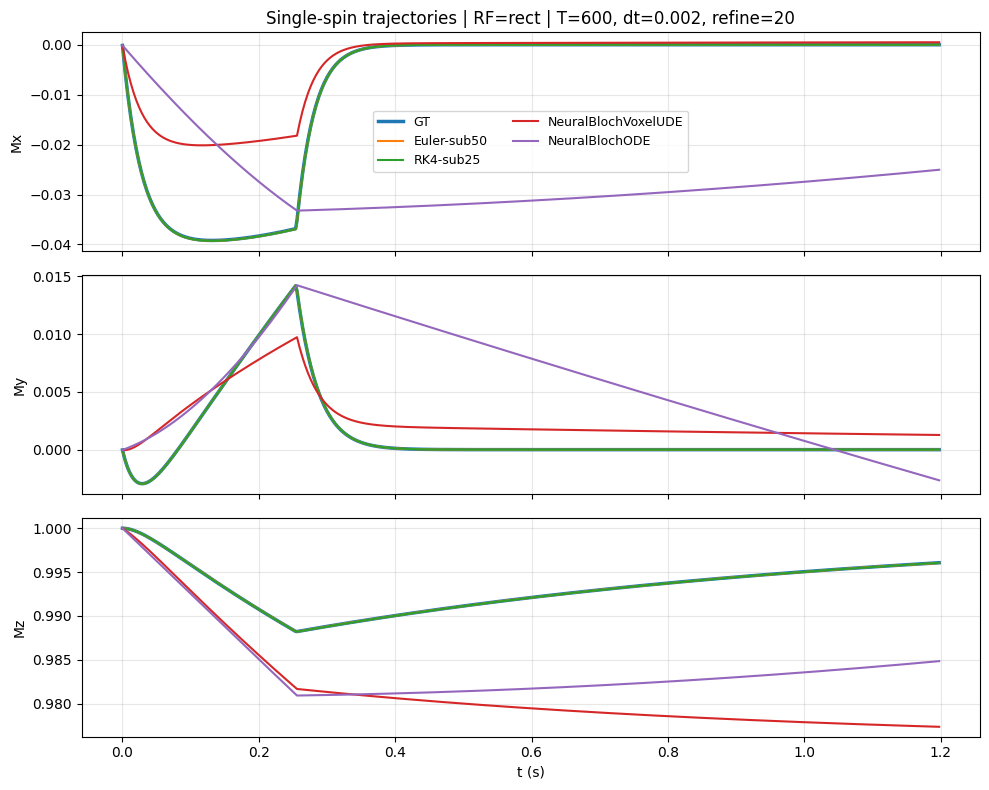

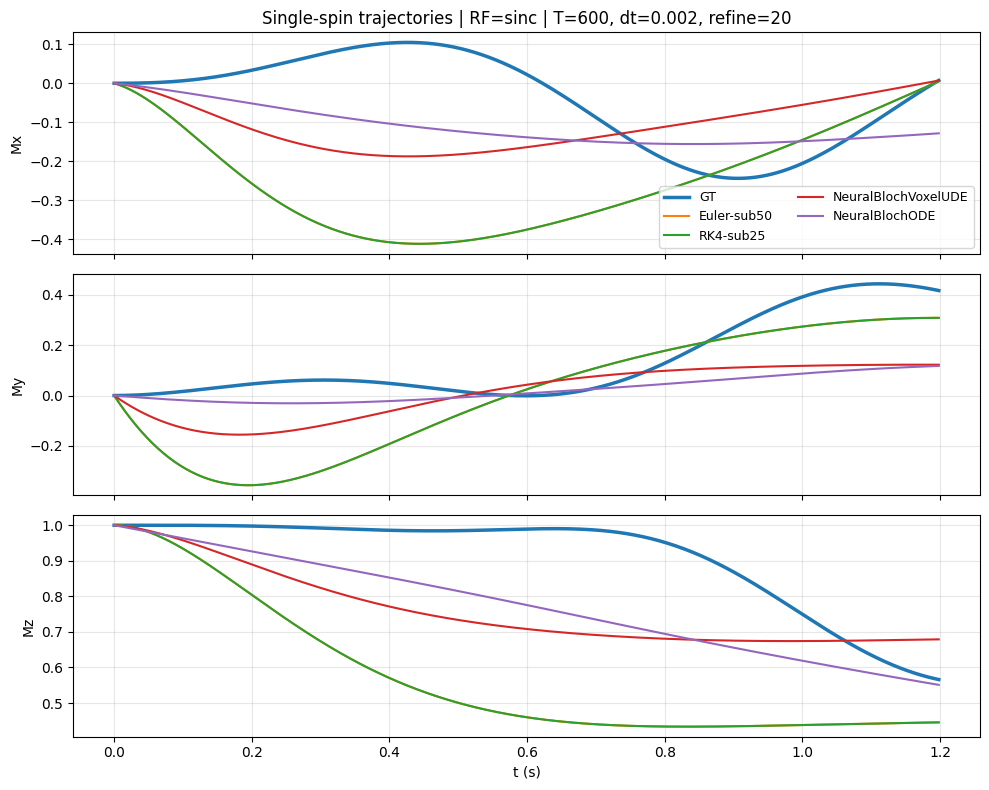

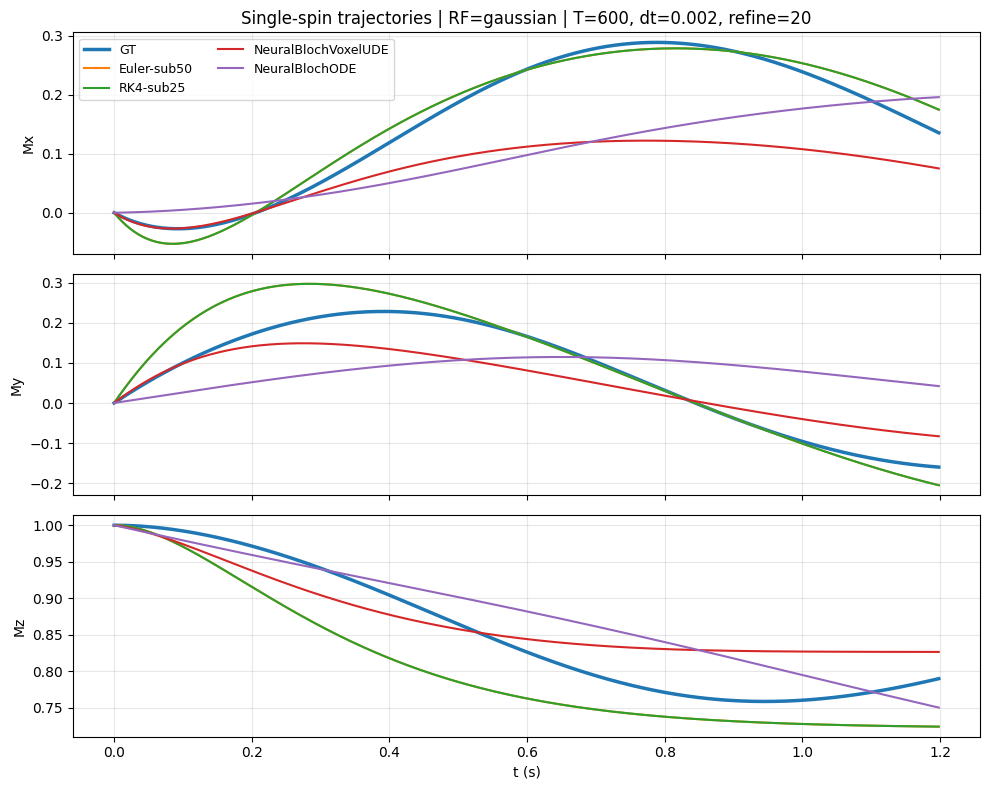

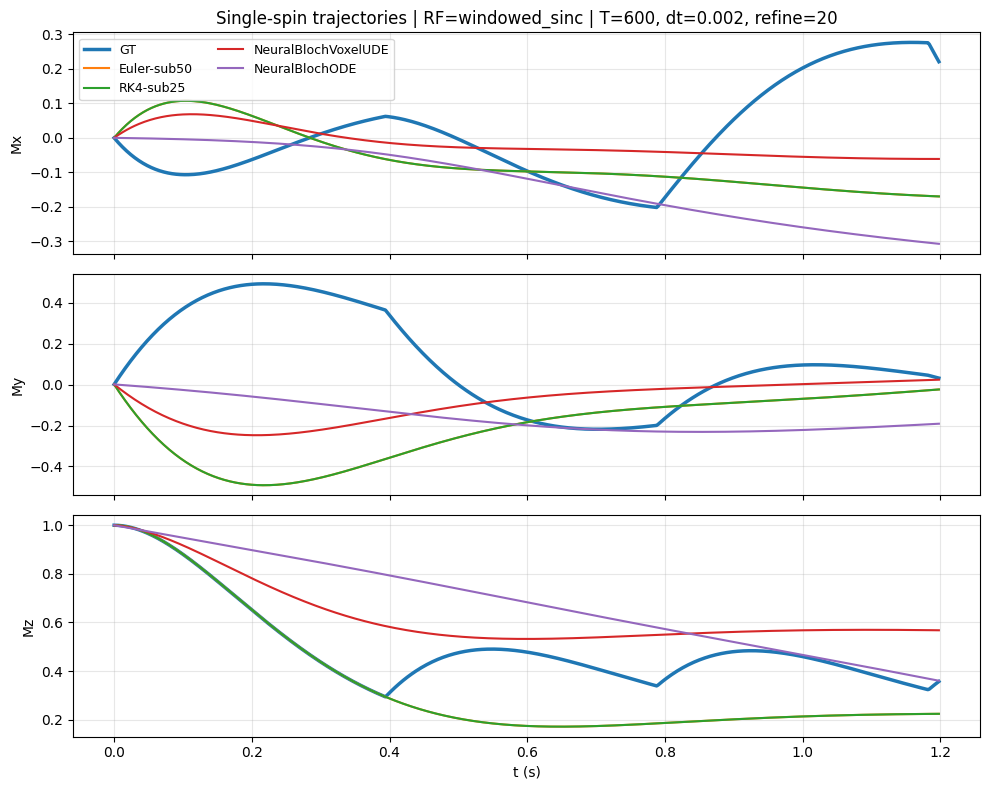

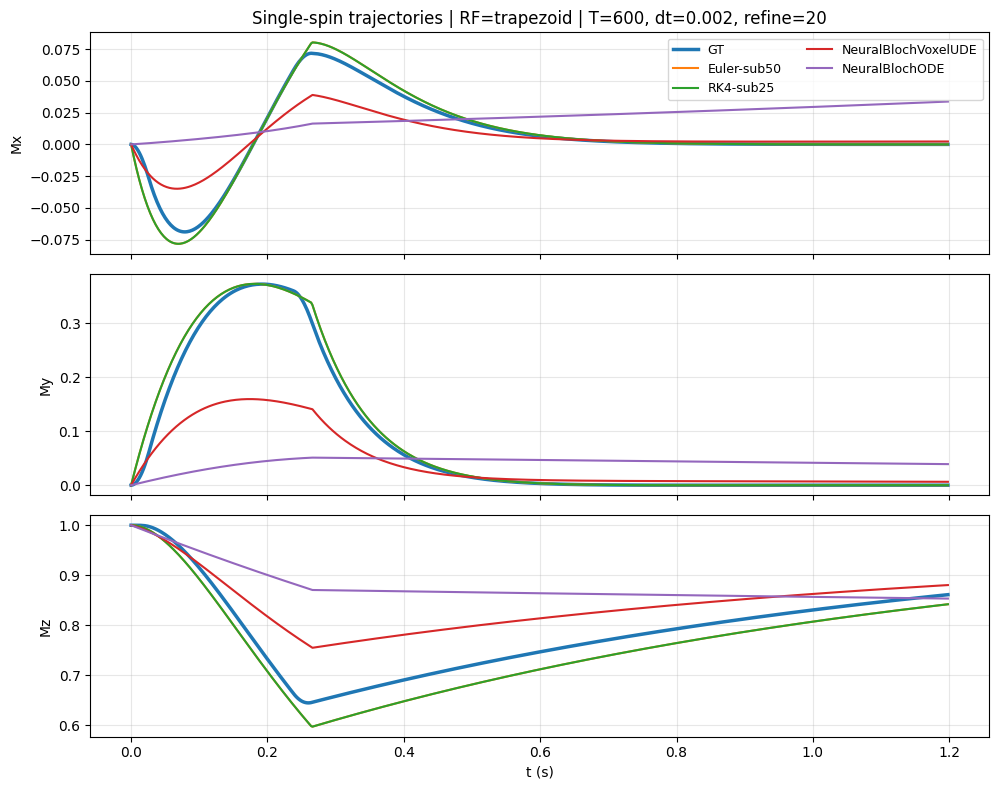

In [31]:
# ============================================================
# Visualize single-spin trajectories by RF type
# - Generates BlochSimulator "ground truth" (fine dt) + coarse view
# - Runs each METHOD (numerical + neural models) on the coarse grid
# - Plots: (1) overlay per RF type, (2) separate figure per RF type
#
# Assumes already defined in your notebook:
#   - BlochSimulator
#   - simulate_one_truth_and_coarse(...)  (single-spin + rf_type returned)
#   - integrate_euler_substeps, integrate_rk4_substeps
#   - bloch_rhs_analytic
#   - load_ckpt_into, make_model_predict_fn, MODEL_SPECS
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Helpers
# ----------------------------
def _to_np(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

@torch.no_grad()
def _predict_one(method_fn, sample, device=DEVICE):
    """
    sample: dict with numpy arrays t,y,y0,u,p
    method_fn signature: (y0, t, u, p) -> yhat (T,3) as torch
    """
    t  = torch.from_numpy(sample["t"]).to(device)
    y0 = torch.from_numpy(sample["y0"]).to(device).unsqueeze(0)   # (1,3)
    u  = torch.from_numpy(sample["u"]).to(device).unsqueeze(0)    # (1,T,4)
    p  = torch.from_numpy(sample["p"]).to(device).unsqueeze(0)    # (1,5)

    yhat = method_fn(y0, t, u, p)   # (1,T,3) or (T,3)
    if yhat.ndim == 2:
        yhat = yhat.unsqueeze(0)
    return _to_np(yhat[0]), _to_np(t)

def _make_methods_for_viz(euler_substeps=20, rk4_substeps=10):
    """
    Returns dict[name] = callable(y0,t,u,p)->(1,T,3)
    """
    methods = {}

    methods[f"Euler-sub{euler_substeps}"] = lambda y0,t,u,p: integrate_euler_substeps(
        y0=y0, t=t, u=u, p=p, n_substeps=euler_substeps
    )
    methods[f"RK4-sub{rk4_substeps}"] = lambda y0,t,u,p: integrate_rk4_substeps(
        y0=y0, t=t, u=u, p=p, n_substeps=rk4_substeps
    )

    # neural models (single-spin checkpoints)
    for model_name, spec in MODEL_SPECS.items():
        ckpt_path = spec.get("ckpt_single_spin", None) or spec.get("ckpt_full_voxel", None)
        ckpt_path = None if ckpt_path is None else Path(ckpt_path)
        if ckpt_path is None or (not ckpt_path.exists()):
            print(f"[warn] missing ckpt for {model_name}: {ckpt_path} (skipping in viz)")
            continue

        model = spec["ctor"]()
        model = load_ckpt_into(model, ckpt_path, DEVICE)

        # wrap to match (y0,t,u,p)->(1,T,3)
        @torch.no_grad()
        def _m(y0, t, u, p, _model=model):
            # model API: model(y0, t, u, p) -> (B,T,3)
            return _model(y0, t, u, p)

        methods[model_name] = _m

    return methods

def _plot_traj_overlay(t, y_true, preds_dict, title):
    """
    Overlay plot: ground truth vs all methods for Mx, My, Mz.
    """
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    comps = ["Mx", "My", "Mz"]
    for ci, ax in enumerate(axes):
        ax.plot(t, y_true[:, ci], linewidth=2.5, label="GT")
        for name, yhat in preds_dict.items():
            ax.plot(t, yhat[:, ci], linewidth=1.5, label=name)
        ax.set_ylabel(comps[ci])
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("t (s)")
    axes[0].set_title(title)
    axes[0].legend(ncol=2, fontsize=9)
    plt.tight_layout()
    return fig

def _plot_traj_separate(t, y_true, preds_dict, title_prefix):
    """
    Separate figures: one per method (GT vs method).
    """
    figs = []
    comps = ["Mx", "My", "Mz"]
    for name, yhat in preds_dict.items():
        fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
        for ci, ax in enumerate(axes):
            ax.plot(t, y_true[:, ci], linewidth=2.5, label="GT")
            ax.plot(t, yhat[:, ci], linewidth=1.8, label=name)
            ax.set_ylabel(comps[ci])
            ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel("t (s)")
        axes[0].set_title(f"{title_prefix} | {name}")
        axes[0].legend()
        plt.tight_layout()
        figs.append(fig)
    return figs

# ----------------------------
# Main: generate one example per RF type and plot
# ----------------------------
def visualize_single_spin_by_rf(
    rf_types=("rect","sinc","gaussian","windowed_sinc","trapezoid"),
    seed_base=2025,
    # trajectory settings
    T_coarse=600,
    dt_coarse=2e-3,
    refine=20,
    # numeric solver settings
    euler_substeps=20,
    rk4_substeps=10,
    # plotting
    separate=True,
    overlay=True,
):
    """
    Produces:
      - Overlay plot per RF type (all methods together)
      - Optionally: separate plots per method per RF type

    Notes:
      This uses simulate_one_truth_and_coarse(...) which *randomly* chooses rf_type.
      We rejection-sample until we get one sample of each requested rf_type.
    """
    methods = _make_methods_for_viz(euler_substeps=euler_substeps, rk4_substeps=rk4_substeps)

    # collect one sample per rf_type
    got = {}
    attempts = 0
    max_attempts = 5000

    while len(got) < len(rf_types) and attempts < max_attempts:
        rng = np.random.default_rng(seed_base + attempts)
        s = simulate_one_truth_and_coarse(T_coarse, dt_coarse, refine, rng)
        rft = s["rf_type"]
        if rft in rf_types and rft not in got:
            got[rft] = s
        attempts += 1

    missing = [r for r in rf_types if r not in got]
    if missing:
        print(f"[warn] Could not sample these rf_types within {max_attempts} attempts: {missing}")
        print("       You can increase max_attempts or change seed_base.")
        rf_types = tuple(r for r in rf_types if r in got)

    # run predictions + plot
    for rft in rf_types:
        s = got[rft]
        y_true = s["y"]
        preds = {}

        for name, fn in methods.items():
            yhat, t = _predict_one(fn, s, device=DEVICE)
            preds[name] = yhat

        title = f"Single-spin trajectories | RF={rft} | T={T_coarse}, dt={dt_coarse}, refine={refine}"
        if overlay:
            _plot_traj_overlay(t, y_true, preds, title)

        if separate:
            _plot_traj_separate(t, y_true, preds, title_prefix=f"Single-spin | RF={rft}")

    plt.show()

# ----------------------------
# Run it
# ----------------------------
visualize_single_spin_by_rf(
    rf_types=("rect","sinc","gaussian","windowed_sinc","trapezoid"),
    seed_base=2025,
    T_coarse=600, dt_coarse=2e-3, refine=20,
    euler_substeps=50, rk4_substeps=25,
    separate=False,
    overlay=True,
)
